# Validación del caso n-of-1: aplicación de StressLoad(t) y ensamblaje de Risk(t)

Este notebook parte del dataset ya cerrado en `n_of_1_preprocesamiento.ipynb`
(`MVA_n_of_1.parquet`).

**Estructura de este notebook:**
- **Sección 1** — Carga de artefactos compartidos.
- **Sección 2** — StressLoad(t) con puerta de actividad **instantánea** (`steps<5/min`
  + `en_ejercicio`), con diagnóstico de su efecto, validación EMA y conclusión.
- **Sección 3** — Misma puerta + recuperación (`en_recuperacion_ejercicio` +
  `en_recuperacion_actividad`), con validación EMA y conclusión.
- **Sección 4** — `f(StressLoad(t))`: ventana de persistencia gap-aware, con
  diagnóstico de cobertura de ventanas e investigación de un posible patrón de
  missingness informativo previo a episodios de estrés.
- **Sección 5** — `Demand(t)`: componente circadiana (Dual Cosines, personalizada a
  la hora de despertar real) + componente de estrés (`D_ref · f(StressLoad(t))`).
- **Sección 6** — `Coverage(t)`: modelo farmacocinético (Bateman) sobre la pauta real
  de dosis, con superposición y arrastre del día previo.
- **Sección 7** — `Risk(t) = Demand(t) − Coverage(t)`: ensamblaje final, caracterización
  y reclasificación por mecanismo de los episodios de desalineación, y un caso
  contrafactual (dosis de refuerzo anticipatoria).
- **Sección 8** — Validación de `f(StressLoad(t))` frente al EMA en ambas direcciones
  (sensibilidad y especificidad inversa), con análisis de patrones de síntomas y
  motivos en los episodios de mayor activación sostenida.

**Nota de nomenclatura:** cada sección guarda sus resultados en columnas propias
(`StressLoad_pred_simple`/`StressLoad_proba_simple` en la Sección 2,
`StressLoad_pred_final`/`StressLoad_proba_final` en la Sección 3).

# 0. Imports y configuración de rutas

Librerías utilizadas a lo largo del notebook, y todas las rutas y artefactos de entrada
centralizados aquí: el dataset n-of-1 ya procesado, el clasificador `StressLoad(t)` entrenado sobre
WESAD (Camino B) con su lista de columnas, y el formulario de dosis/EMA reales — leídos una sola vez,
sin recargas intermedias.

In [1]:
import json
import importlib
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import spearmanr, mannwhitneyu

import formulario_utils
importlib.reload(formulario_utils)
from formulario_utils import (
    load_form_doses, load_form_ema,
    dual_cosines, demand_circadian, demand_circadian_personalizado,
    D_REF_MID, DAILY_TOTAL_MG_MID,
    compute_coverage, PKParams, bateman_single_dose,
)

pd.set_option("display.max_columns", None)

# --- Configuración y rutas ---
with open("MVA_config_rutas.json", "r", encoding="utf-8") as f:
    config_mva = json.load(f)
with open("WESAD_config_rutas.json", "r", encoding="utf-8") as f:
    config_wesad = json.load(f)

# Dataset n-of-1 ya procesado (features Camino B + columnas de actividad ampliadas)
RUTA_NOF1 = Path(config_mva["rutas"]["general"]["processed_data_extended"])

# Salida de este notebook: dataset con el ensamblaje Risk(t) ya calculado
RUTA_RISK_OUTPUT = Path(config_mva["rutas"]["general"]["processed_data_risk_extended"])

# Formulario de dosis reales y EMA (Google Forms)
XLSX_PATH = Path(config_mva["rutas"]["general"]["formulario"])

# Clasificador StressLoad(t) entrenado sobre WESAD (Camino B, ver StressLoad(t).ipynb)
RUTAS_ART_STRESSLOAD = config_wesad["rutas_artefactos_stressload"]
modelo_stress = joblib.load(RUTAS_ART_STRESSLOAD["modelo_final"])
with open(RUTAS_ART_STRESSLOAD["columnas_camino_B"]) as f:
    columnas_camino_B_wesad = json.load(f)


# 1. Carga de artefactos compartidos

Se cargan dos artefactos independientes: (1) el dataset n-of-1 ya preprocesado, con
las features de Camino B y las columnas de actividad ampliadas; (2) el clasificador
StressLoad(t) entrenado sobre WESAD (`StressLoad(t).ipynb`), junto con la lista exacta
de columnas que espera como input. Cargar ambos por separado, en vez de asumir que
son compatibles, permite comprobar explícitamente que las features de Camino B del
caso n-of-1 encajan con las que el modelo espera (`feature_names_in_`) antes de
aplicar ninguna predicción -- el sanity check de la Sección 1.3 verifica esa
correspondencia, en vez de asumirla.

## 1.1. Carga dataframe

In [2]:
df_nof1 = pd.read_parquet(RUTA_NOF1, engine="fastparquet")

Ambos artefactos cargan correctamente y son compatibles: el dataset n-of-1 (27.642 filas, 40 columnas) cubre el rango 21/05-09/06, y las 7 columnas que el modelo espera (feature_names_in_) están presentes en el dataset renombrado. Las tres columnas de actividad ampliada (en_ejercicio, en_recuperacion_ejercicio, en_recuperacion_actividad) están confirmadas — necesarias para las puertas de actividad de las Secciones 2 y 3, no para el clasificador en sí. hr_implausible_baja está presente y marca 1 minuto, coherente con lo ya discutido en la introducción — se mantiene como bandera informativa, no como filtro.

## 1.2. Sanity checks

In [3]:
 #--- 1.3. Sanity checks ---
print(f"Dataset n-of-1 cargado: {df_nof1.shape[0]} filas, {df_nof1.shape[1]} columnas")
print(f"Rango temporal: {df_nof1.index.min()} -> {df_nof1.index.max()}"
      if isinstance(df_nof1.index, pd.DatetimeIndex)
      else "Aviso: el índice no es DatetimeIndex, revisar antes de continuar.")

print(f"\n¿El modelo tiene feature_names_in_?: {hasattr(modelo_stress, 'feature_names_in_')}")
if hasattr(modelo_stress, "feature_names_in_"):
    print(f"feature_names_in_: {list(modelo_stress.feature_names_in_)}")

COLUMNAS_ACTIVIDAD_AMPLIADA = ["en_ejercicio", "en_recuperacion_ejercicio", "en_recuperacion_actividad"]
faltantes = [c for c in COLUMNAS_ACTIVIDAD_AMPLIADA if c not in df_nof1.columns]
assert not faltantes, f"Faltan columnas de actividad ampliadas: {faltantes} -- ¿parquet actualizado?"
print(f"\nColumnas de actividad ampliadas presentes: {COLUMNAS_ACTIVIDAD_AMPLIADA}")

# Bandera informativa de plausibilidad fisiológica de HR (ver 4.3.4/4.5) -- NO se usa
# como filtro de exclusión (ver discusión: un salto de HR puede ser estrés real, no
# artefacto; se descartó ese criterio). Solo HR<45bpm en vigilia, marcada, no excluida.
assert "hr_implausible_baja" in df_nof1.columns, \
    "Falta la columna hr_implausible_baja -- ¿parquet actualizado con el flag de preprocesamiento?"
print(f"\nMinutos marcados como hr_implausible_baja: {df_nof1['hr_implausible_baja'].sum()}")

es_vigilia = df_nof1["estado"] == "Despierto"

Dataset n-of-1 cargado: 85903 filas, 40 columnas
Rango temporal: 2026-05-21 00:00:00 -> 2026-07-20 15:04:00

¿El modelo tiene feature_names_in_?: True
feature_names_in_: ['HR_mean_norm', 'HR_mean_roll_mean_5m_norm', 'HR_mean_roll_std_5m_norm', 'HR_mean_roll_mean_10m_norm', 'HR_mean_roll_std_10m_norm', 'HR_mean_norm_lag_1m_norm', 'HR_mean_norm_lag_2m_norm']

Columnas de actividad ampliadas presentes: ['en_ejercicio', 'en_recuperacion_ejercicio', 'en_recuperacion_actividad']

Minutos marcados como hr_implausible_baja: 1


## 1.3. Capa de adaptación de nomenclatura  y máscara de cobertura Camino B

Los nombres de las 7 columnas de Camino B en el caso n-of-1 (`delta_hr_z_stressload`,
etc.) no coinciden literalmente con los que espera `modelo_stress.feature_names_in_`
(`HR_mean_norm`, etc.) -- son la misma información, pero con la nomenclatura propia
de cada pipeline (n-of-1 vs. WESAD). Se define aquí el mapeo explícito entre ambos
espacios de nombres, y se verifica que coincide exactamente con lo que el modelo
espera -- sin renombrar todavía las columnas del dataset, solo confirmando la
correspondencia -- y se calcula la máscara de filas con las 7 columnas completas,
que determina qué minutos son aptos para clasificación.

**Nota -- el sueño ya queda excluido aquí, sin filtro explícito por `estado`:** cuatro
de las 7 columnas de Camino B (los rolling/lag *gap-aware*) se calcularon en
preprocesamiento (5.2) agrupando por bloques contiguos de vigilia -- fuera de
vigilia, esas columnas son `NaN` por construcción. `mask_completo`, al exigir que
ninguna de las 7 columnas tenga NaN, hereda esa exclusión de forma indirecta: no hace
falta (ni se aplica) ningún filtro adicional por `estado` en este notebook para que
sueño y siesta queden fuera del análisis.

In [4]:
mapa_renombrado_camino_B = {
    "delta_hr_z_stressload":                   "HR_mean_norm",
    "delta_hr_roll_mean_5m_gapaware_norm":      "HR_mean_roll_mean_5m_norm",
    "delta_hr_roll_std_5m_gapaware_norm":       "HR_mean_roll_std_5m_norm",
    "delta_hr_roll_mean_10m_gapaware_norm":     "HR_mean_roll_mean_10m_norm",
    "delta_hr_roll_std_10m_gapaware_norm":      "HR_mean_roll_std_10m_norm",
    "delta_hr_z_stressload_lag_1m_gapaware":    "HR_mean_norm_lag_1m_norm",
    "delta_hr_z_stressload_lag_2m_gapaware":    "HR_mean_norm_lag_2m_norm",
}
cols_origen = list(mapa_renombrado_camino_B.keys())

assert set(mapa_renombrado_camino_B.keys()).issubset(df_nof1.columns), \
    "Faltan columnas de origen en df_nof1"
assert set(mapa_renombrado_camino_B.values()) == set(modelo_stress.feature_names_in_), \
    "El mapeo no coincide exactamente con feature_names_in_ del modelo"

mask_completo = df_nof1[cols_origen].notna().all(axis=1)
print(f"Filas con Camino B completo: {mask_completo.sum()} de {len(df_nof1)} "
      f"({mask_completo.mean():.1%})")

Filas con Camino B completo: 48505 de 85903 (56.5%)


## 1.4. Carga del formulario EMA y restricción al rango real cubierto por el wearable

Se carga el formulario EMA (dosis reales y autorreporte de estrés, vía
`formulario_utils`), reutilizando la misma lógica ya validada en el notebook de
preprocesamiento. A diferencia de Capítulo 4 (preprocesamiento), aquí interesa
además restringir el EMA al rango temporal realmente cubierto por `df_nof1` --
el formulario recoge registros más allá de ese rango (p. ej. el 23/08, fuera del
tramo denso analizado), que no tendrían con qué contrastarse. Se define también
una función auxiliar (`resumen_ventana`) para cruzar cada ventana EMA con las
predicciones de StressLoad(t), que se usará en las secciones de validación
posteriores.

In [5]:
from formulario_utils import load_form_doses, load_form_ema


doses_real = load_form_doses(XLSX_PATH)
df_ema = load_form_ema(XLSX_PATH, doses_real)

print(f"Columnas de df_ema: {df_ema.columns.tolist()}")
print(df_ema["block"].value_counts())

# Ambos bloques comparten ya la misma estructura window_start/window_end/window_reliable
df_ema_a = df_ema[(df_ema["block"] == "A") & (df_ema["window_reliable"])].copy()
df_ema_b = df_ema[(df_ema["block"] == "B") & (df_ema["window_reliable"])].copy()

print(f"\nBloque A utilizable: {len(df_ema_a)} de {len(df_ema[df_ema['block']=='A'])} registros")
print(f"Bloque B utilizable: {len(df_ema_b)} de {len(df_ema[df_ema['block']=='B'])} registros")

rango_inicio = df_nof1.index.min()
rango_fin = df_nof1.index.max()

en_rango_a = (df_ema_a["window_start"] >= rango_inicio) & (df_ema_a["window_end"] <= rango_fin)
df_ema_a_rango = df_ema_a[en_rango_a].copy()

en_rango_b = (df_ema_b["window_start"] >= rango_inicio) & (df_ema_b["window_end"] <= rango_fin)
df_ema_b_rango = df_ema_b[en_rango_b].copy()

print(f"\nRango real cubierto por df_nof1: {rango_inicio} -> {rango_fin}")
print(f"Bloque A dentro del rango: {len(df_ema_a_rango)} de {len(df_ema_a)}")
print(f"Bloque B dentro del rango: {len(df_ema_b_rango)} de {len(df_ema_b)}")


def resumen_ventana(inicio, fin, columna_pred, columna_proba):
    tramo = df_nof1.loc[inicio:fin, [columna_pred, columna_proba]]
    n_clasificados = tramo[columna_pred].notna().sum()
    if n_clasificados == 0:
        return pd.Series({"proba_max": np.nan, "n_clasificados": 0})
    return pd.Series({
        "proba_max": tramo[columna_proba].max(),
        "n_clasificados": n_clasificados,
    })

INFO: 2 día(s) con omisión/reordenamiento confirmado por la autora (doses.attrs['confirmed_gaps']), sin cobertura añadida.
AVISO: 1 registro(s) (A+B) con ventana solapando huecos de dosis pendientes o sin resolver.
Columnas de df_ema: ['block', 'window_start', 'window_end', 'stress_score', 'symptoms', 'context_flag', 'sleep_quality', 'window_reliable']
block
A    300
B      9
Name: count, dtype: int64

Bloque A utilizable: 299 de 300 registros
Bloque B utilizable: 9 de 9 registros

Rango real cubierto por df_nof1: 2026-05-21 00:00:00 -> 2026-07-20 15:04:00
Bloque A dentro del rango: 181 de 299
Bloque B dentro del rango: 8 de 9


In [6]:
# Identificar el registro de EMA con ventana no confiable (window_reliable=False) y mostrarlo

print(df_ema[df_ema["window_reliable"] == False][
    ["block", "window_start", "window_end", "stress_score", "symptoms", "context_flag"]
].to_string())

print("\nHuecos pendientes de dosis (sin confirmar):")
print(doses_real.attrs["pending_gaps"])

  block window_start          window_end  stress_score symptoms   context_flag
0     A          NaT 2026-05-21 07:20:00           1.0  Ninguno  Nada especial

Huecos pendientes de dosis (sin confirmar):
Empty DataFrame
Columns: [date, type, slot, expected_mg, actual_mg, actual_datetime]
Index: []


In [7]:
# Visualizar los registros de EMA del bloque B (Camino B) 
print(df_ema[df_ema["block"] == "B"][
    ["window_start", "window_end", "stress_score", "symptoms", "context_flag", "window_reliable"]
].to_string())

           window_start          window_end  stress_score                                                                       symptoms                                                                              context_flag  window_reliable
8   2026-05-23 16:05:00 2026-05-23 18:05:00           6.0  Fatiga extrema, Niebla mental / Dificultad para concentrarme, Dolor de cabeza                                                                     Pico de estrés notado             True
21  2026-05-27 12:50:00 2026-05-27 14:20:00           8.0  Fatiga extrema, Niebla mental / Dificultad para concentrarme, Dolor de cabeza                                                                     Pico de estrés notado             True
27  2026-05-29 06:45:00 2026-05-29 07:45:00           6.0                                                                        Ninguno                                                                     Pico de estrés notado             True
33  2026-05-30 19:30:00 

De los 300 registros de Bloque A, 299 son utilizables (window_reliable) — el único descartado es el primer registro del formulario (21/05 07:20h), cuya ventana no puede anclarse a ninguna dosis previa por ser anterior a la primera toma registrada; no hay huecos de dosis pendientes sin resolver que lo expliquen (pending_gaps vacío). De los 9 de Bloque B, los 9 son utilizables. Al restringir al rango real cubierto por df_nof1 (21/05-20/07), la cobertura cae : solo 181 de 299 registros de Bloque A  y 8 de 9 de Bloque B caen dentro del tramo n-of-1 analizado — una parte del EMA recogido corresponde a fechas fuera de este dataset.


# 2. StressLoad(t) con puerta de actividad instantánea (steps + ejercicio)

**Actividad como puerta binaria:** reposo = menos de ~5
pasos/min. Se complementa con `en_ejercicio` (sesiones registradas manualmente en el
reloj: danza, HIIT, taichi, natación, yoga), porque una parte sustancial de esas
sesiones no generan pasos detectables y no serían identificadas por la puerta de
`steps` sola (ver cuantificación en 2.2). Ambas condiciones como filtro de entrada.
Sin margen de recuperación posterior (ver Sección 3).

In [8]:
UMBRAL_PUERTA_ACTIVIDAD = 5  # pasos/min

df_nof1["dentro_dominio_actividad_simple"] = (
    (df_nof1["steps"] < UMBRAL_PUERTA_ACTIVIDAD) & (~df_nof1["en_ejercicio"])
)
mask_valida_simple = mask_completo & df_nof1["dentro_dominio_actividad_simple"]

print(f"Camino B completo (sin puerta): {mask_completo.sum()}")
print(f"+ puerta instantánea (steps + en_ejercicio): {mask_valida_simple.sum()}")

df_input_simple = (
    df_nof1.loc[mask_valida_simple, cols_origen]
    .rename(columns=mapa_renombrado_camino_B)
    [modelo_stress.feature_names_in_]
)
pred_simple = modelo_stress.predict(df_input_simple)
proba_simple = modelo_stress.predict_proba(df_input_simple)[:, 1]

df_nof1["StressLoad_pred_simple"] = np.nan
df_nof1["StressLoad_proba_simple"] = np.nan
df_nof1.loc[mask_valida_simple, "StressLoad_pred_simple"] = pred_simple
df_nof1.loc[mask_valida_simple, "StressLoad_proba_simple"] = proba_simple

print(f"\nDistribución StressLoad_pred_simple:")
print(df_nof1.loc[mask_valida_simple, "StressLoad_pred_simple"].value_counts())

Camino B completo (sin puerta): 48505
+ puerta instantánea (steps + en_ejercicio): 39978

Distribución StressLoad_pred_simple:
StressLoad_pred_simple
0.0    35767
1.0     4211
Name: count, dtype: int64


La puerta de actividad instantánea reduce la cobertura respecto al Camino B completo, excluyendo tanto los minutos con actividad de pasos detectable como las sesiones de ejercicio registradas manualmente. Dado que la mayoría de esas sesiones de ejercicio ya presentan steps bajo, el criterio de pasos explica casi toda la reducción, y el de en_ejercicio aporta solo un ajuste marginal adicional. De los minutos clasificados, el modelo predice estrés en una proporción baja pero no despreciable — una primera cifra de referencia antes de introducir el margen de recuperación en la Sección 3.

## 2.1. Cobertura por estado (sueño/siesta/vigilia)

In [9]:
sin_clasificar_simple = df_nof1["StressLoad_pred_simple"].isna()
print("Minutos SIN StressLoad_pred_simple, por estado:")
print(df_nof1.loc[sin_clasificar_simple, "estado"].value_counts())

cobertura_vigilia_simple = df_nof1.loc[es_vigilia, "StressLoad_pred_simple"].notna().mean()
print(f"\nCobertura de StressLoad_pred_simple dentro de vigilia: {cobertura_vigilia_simple:.1%}")

Minutos SIN StressLoad_pred_simple, por estado:
estado
Dormido(noche)    28207
Despierto         15227
Siesta             2491
Name: count, dtype: int64

Cobertura de StressLoad_pred_simple dentro de vigilia: 72.4%


De los 55.205 minutos totales de vigilia (es_vigilia), el 72,4% (39.978) queda clasificado tras
aplicar Camino B completo + puerta de actividad instantánea; el resto queda sin clasificar por
alguna combinación de cobertura insuficiente en el rolling/lag gap-aware o por caer dentro de un
bloque de actividad/ejercicio excluido. Los minutos sin clasificación fuera de vigilia (28.207 en
sueño, 2.491 en siesta) son el comportamiento esperado, no una pérdida de cobertura real — confirma
que la exclusión heredada de 1.4 (columnas Camino B como NaN fuera de bloques de vigilia) funciona
correctamente, sin necesidad de un filtro adicional por estado en este notebook.

## 2.2. Diagnóstico: efecto de `en_ejercicio` sobre la cobertura

Comprobación de por qué añadir `en_ejercicio` a la puerta cambia relativamente pocos
minutos respecto a usar solo `steps` -- necesario para no aceptar el número sin
entender su origen.

In [10]:
n_min_ejercicio_total = df_nof1["en_ejercicio"].sum()
n_min_ejercicio_en_camino_b = (df_nof1["en_ejercicio"] & mask_completo).sum()
n_min_ejercicio_camino_b_y_steps_bajo = (
    df_nof1["en_ejercicio"] & mask_completo & (df_nof1["steps"] < UMBRAL_PUERTA_ACTIVIDAD)
).sum()
n_min_ejercicio_camino_b_y_steps_alto = (
    df_nof1["en_ejercicio"] & mask_completo & (df_nof1["steps"] >= UMBRAL_PUERTA_ACTIVIDAD)
).sum()

print(f"Minutos totales en_ejercicio (todo el dataset): {n_min_ejercicio_total}")
print(f"  de ellos, dentro de Camino B completo: {n_min_ejercicio_en_camino_b}")
print(f"    de ellos, con steps<{UMBRAL_PUERTA_ACTIVIDAD} (invisibles para una puerta basada solo en steps): "
      f"{n_min_ejercicio_camino_b_y_steps_bajo}")
print(f"    de ellos, con steps>={UMBRAL_PUERTA_ACTIVIDAD} (ya excluidos por steps solo, sin cambio): "
      f"{n_min_ejercicio_camino_b_y_steps_alto}")

Minutos totales en_ejercicio (todo el dataset): 671
  de ellos, dentro de Camino B completo: 573
    de ellos, con steps<5 (invisibles para una puerta basada solo en steps): 412
    de ellos, con steps>=5 (ya excluidos por steps solo, sin cambio): 161


Confirma exactamente el desglose que se había anticipado en la introducción de esta sección: de los
671 minutos de ejercicio registrado en todo el dataset, 573 caen dentro de Camino B completo, y de
esos, 412 tienen steps<5 (invisibles para una puerta basada solo en steps, así que en_ejercicio sí
aporta algo ahí) y 161 ya tenían steps≥5 (redundantes, ya excluidos sin necesidad de en_ejercicio).
Justifica por qué en_ejercicio añade un ajuste relevante (412 minutos) a la puerta de actividad: la
mayoría del ejercicio registrado con Camino B completo tiene lugar sin actividad de pasos detectable,
aunque una parte del ejercicio total (98 de los 671 minutos) no llega siquiera a evaluarse aquí, al
caer fuera del subconjunto con Camino B completo.

## 2.3. Validez aparente frente al EMA -- Bloque A (ventanas de horas)

Chequeo exploratorio (face-validity), previo a construir `f(StressLoad(t))` -- no
sustituye al contraste formal de sensibilidad y especificidad frente al EMA
(Sección 8, sobre `f(StressLoad(t))`, no sobre `StressLoad_pred_simple` directamente).

**Advertencia de circularidad:** la referencia de calma usada para normalizar el
input del propio clasificador se calibró parcialmente con `stress_score` del Bloque A.

In [11]:
resumen_simple = df_ema_a_rango.apply(
    lambda r: resumen_ventana(r["window_start"], r["window_end"],
                               "StressLoad_pred_simple", "StressLoad_proba_simple"),
    axis=1
)
df_ema_a_rango[["proba_max_simple", "n_clasificados_simple"]] = resumen_simple

validas_simple = df_ema_a_rango[df_ema_a_rango["n_clasificados_simple"] >= 10]
print(f"Ventanas de Bloque A con >= 10 min clasificados (puerta instantánea): "
      f"{len(validas_simple)} de {len(df_ema_a_rango)}")

rho_simple, p_simple = spearmanr(validas_simple["stress_score"], validas_simple["proba_max_simple"])
print(f"Spearman stress_score vs. proba_max (puerta instantánea): rho={rho_simple:.3f}, p={p_simple:.4f}")

print(validas_simple[["window_start", "stress_score", "proba_max_simple", "n_clasificados_simple"]]
      .sort_values("stress_score", ascending=False).to_string())

Ventanas de Bloque A con >= 10 min clasificados (puerta instantánea): 181 de 181
Spearman stress_score vs. proba_max (puerta instantánea): rho=0.104, p=0.1655
           window_start  stress_score  proba_max_simple  n_clasificados_simple
47  2026-06-04 07:21:00           9.0          0.671525                  143.0
49  2026-06-04 11:30:00           6.0          0.906191                  104.0
54  2026-06-05 18:30:00           6.0          0.888329                  177.0
130 2026-07-01 07:59:11           6.0          0.507072                  319.0
96  2026-06-19 17:19:19           6.0          0.755218                  235.0
155 2026-07-09 05:52:08           6.0          0.846306                  301.0
43  2026-06-02 19:00:00           5.0          0.722741                  241.0
157 2026-07-09 17:55:51           5.0          0.603983                  309.0
103 2026-06-22 07:56:14           5.0          0.772854                  168.0
59  2026-06-07 14:00:00           5.0          0.78

-  Spearman rho (ρ) mide correlación monótona entre dos variables sin asumir relación lineal ni distribución normal — apropiado aquí porque stress_score es una escala ordinal discreta (0-10) y proba_max es una probabilidad continua acotada, no necesariamente relacionadas linealmente. Rango [-1, 1]:   
   -  0 = sin relación monótona; 
   -  +1 = a mayor stress_score, siempre mayor proba_max, sin excepciones.  
-  p-valor indica la probabilidad de observar un ρ tan extremo como este (o más) si en realidad no hubiera ninguna correlación real (hipótesis nula: ρ=0). Convención habitual: p<0.05 se considera "estadísticamente significativo" — evidencia suficiente para descartar que sea puro azar.

La correlación entre stress_score (Bloque A) y proba_max_simple es positiva pero débil y no
significativa (ρ=0,112, p=0,132, n=181) — no hay evidencia de validez concurrente con la puerta de
actividad instantánea. Se observa además, mirando los datos ordenados por stress_score, un patrón
llamativo: proba_max_simple es alto (>0,5, a menudo >0,8) incluso en ventanas de stress_score bajo
(3) — hasta 0,91 en el caso más extremo —, lo cual sugiere que la puerta instantánea, sin margen de
recuperación, puede estar generando falsos positivos por activación fisiológica residual
post-actividad no capturada — motivación directa para la puerta con recuperación de la Sección 3.

Se recuerda la advertencia de circularidad ya señalada en la introducción de 2.3: parte de esta
relación débil puede estar influida por que la propia referencia de calma del clasificador ya se
calibró en parte contra este mismo stress_score.

## 2.4. Validez aparente frente al EMA -- Bloque B (evento puntual)

Mismo chequeo exploratorio que 2.3, pero sobre Bloque B -- eventos puntuales con
ventana propia (inicio/fin declarados), en vez de intervalos retrospectivos ligados
a cada toma. 8 eventos caen dentro del rango cubierto por `df_nof1`, muestra pequeña
pero suficiente para un cálculo exploratorio de correlación, a diferencia de la
ventana de datos que se manejaba originalmente.

In [12]:
resumen_simple_b = df_ema_b_rango.apply(
    lambda r: resumen_ventana(r["window_start"], r["window_end"],
                               "StressLoad_pred_simple", "StressLoad_proba_simple"),
    axis=1
)
df_ema_b_rango[["proba_max_simple", "n_clasificados_simple"]] = resumen_simple_b

print("Bloque B — eventos dentro del rango (puerta instantánea):")
print(df_ema_b_rango[
    ["window_start", "window_end", "stress_score", "proba_max_simple", "n_clasificados_simple"]
].sort_values("window_start").to_string())

Bloque B — eventos dentro del rango (puerta instantánea):
           window_start          window_end  stress_score  proba_max_simple  n_clasificados_simple
8   2026-05-23 16:05:00 2026-05-23 18:05:00           6.0          0.917956                   44.0
21  2026-05-27 12:50:00 2026-05-27 14:20:00           8.0          0.884589                   37.0
27  2026-05-29 06:45:00 2026-05-29 07:45:00           6.0          0.311047                   27.0
33  2026-05-30 19:30:00 2026-05-30 23:30:00           7.0          0.879611                  198.0
48  2026-06-04 12:03:00 2026-06-04 13:03:00          10.0          0.906191                   30.0
139 2026-07-04 11:25:00 2026-07-04 11:45:00           3.0          0.601188                    9.0
161 2026-07-11 12:05:00 2026-07-11 12:25:00           3.0          0.684766                    8.0
165 2026-07-12 10:50:00 2026-07-12 12:10:00           5.0          0.842868                   55.0


In [13]:
rho_b, p_b = spearmanr(df_ema_b_rango["stress_score"], df_ema_b_rango["proba_max_simple"])
print(f"Spearman stress_score vs. proba_max (Bloque B, puerta instantánea): rho={rho_b:.3f}, p={p_b:.4f}, n={len(df_ema_b_rango)}")

Spearman stress_score vs. proba_max (Bloque B, puerta instantánea): rho=0.627, p=0.0965, n=8


Con n=8, la correlación entre stress_score y proba_max_simple es notablemente más fuerte que en
Bloque A (ρ=0,627 frente a ρ=0,112), aunque no alcanza significación convencional (p=0,097) --
esperable dado el tamaño de muestra. El patrón visual respalda esta lectura: los eventos de mayor
stress_score (10, 8, 7) muestran proba_max alta (0,91, 0,89, 0,88), mientras que los de menor
stress_score (3, 3) muestran proba_max más moderada (0,60, 0,70) -- aunque no es una relación
perfecta (el evento de stress_score=6 del 29/05 muestra proba_max=0,26, claramente atípico dentro
del patrón). La diferencia con Bloque A es coherente con que Bloque B usa ventanas ancladas al
evento real declarado por la autora, no a un intervalo retrospectivo entre tomas -- menos margen
para que el pico de estrés quede diluido fuera de la ventana.

## 2.5. Conclusión -- Sección 2 (puerta instantánea: steps + ejercicio)

Se aplicó StressLoad(t) exigiendo cobertura completa de las 7 columnas de Camino B y
cumplimiento de la puerta de actividad instantánea: `steps < 5/min` Y ausencia de
sesión de ejercicio registrada (`en_ejercicio`) -- ambas condiciones como filtro de
entrada, no como corrección posterior sobre la salida del modelo.

**Cobertura:** 39.978 de 85.903 minutos totales (46,5%) reciben predicción; 72,4% de
cobertura dentro de vigilia. 4.211 minutos (10,5% de los clasificables) se predicen
como "Estresado".

**Sobre `en_ejercicio`:** de los 671 minutos totales marcados como sesión de ejercicio
en el dataset, 573 (85,4%) caen dentro de la cobertura completa de Camino B. De esos
573, 412 (71,9%) tenían `steps<5` (invisibles para un criterio basado solo en pasos) y
los 161 restantes ya tenían `steps>=5`.

**Validación exploratoria frente al EMA**, restringida al rango real del wearador
(21/05-20/07):

- **Bloque A** (n=181 ventanas, reporte retrospectivo de intervalo entre tomas): correlación
  positiva pero débil y no significativa entre `stress_score` y el pico de probabilidad del
  clasificador dentro de la ventana (Spearman ρ=0,112, p=0,132).
- **Bloque B** (n=8 eventos puntuales, todos evaluables dentro del rango): correlación
  notablemente más fuerte (ρ=0,627), aunque tampoco significativa (p=0,097) dado el tamaño de
  muestra. El patrón visual respalda la lectura en general (stress_score alto → proba_max alta),
  con una excepción clara (stress_score=6 con proba_max=0,26).

**Interpretación:** el resultado difiere según la granularidad del ground truth disponible.
Bloque A, con ventanas retrospectivas de varias horas, muestra una relación débil que no alcanza
significación -- consistente con que el instrumento de medida sea demasiado grueso para resolver
picos puntuales de estrés en contexto ambulatorio, o con que StressLoad(t) no capture bien la
gradación de intensidad. Bloque B, con ventanas ancladas directamente al evento declarado, muestra
una relación bastante más marcada, aunque la muestra (n=8) sigue siendo insuficiente para
confirmarla con rigor estadístico. La discrepancia entre ambos bloques sugiere que la granularidad
temporal del ground truth importa más que la propia validez del clasificador.

**Limitaciones declaradas:**
- Circularidad parcial: la referencia de calma usada para normalizar el input del
  clasificador se calibró en parte con `stress_score` de Bloque A.
- Ninguna de las dos correlaciones alcanza significación estadística convencional (p<0,05);
  ambas deben leerse como exploratorias, no confirmatorias.
- El 85,4% de los minutos marcados como ejercicio ya tienen cobertura completa de
  Camino B, lo que limita cuánto puede corregir `en_ejercicio` sobre el conjunto
  total.

# 3. StressLoad(t) con puerta de actividad + recuperación

Se añaden dos colas de recuperación posteriores a la puerta instantánea de la
Sección 2, ambas ya calculadas en preprocesamiento:

- **`en_recuperacion_ejercicio`**: cola específica de las sesiones de
  ejercicio directo registrado, con duración estimada por el propio reloj por sesión
  (`recover_time`, 2-33 min).
- **`en_recuperacion_actividad`**: cola proporcional a la duración de cualquier
  bloque de `steps>=5` no registrado como ejercicio formal. Usa la misma lógica de
  margen 1:1 (techo 10 min) explorada y justificada en 3.1-3.2 -- se reutiliza la
  columna ya calculada en vez de recomputarla en este notebook.

## 3.1. Duración real de los bloques de actividad general (diagnóstico)

Justifica por qué `en_recuperacion_actividad` usa un margen proporcional a la
duración del bloque, y no un margen fijo.

In [14]:
actividad = df_nof1["steps"] >= UMBRAL_PUERTA_ACTIVIDAD
bloques_actividad = (actividad != actividad.shift()).cumsum()
duracion_bloques = df_nof1[actividad].groupby(bloques_actividad[actividad]).size()

print("Duración de los bloques de actividad detectados (minutos consecutivos con steps>=5):")
print(duracion_bloques.describe())
print(f"\n% de bloques de actividad que duran 1 minuto solo: {(duracion_bloques == 1).mean():.1%}")
print(f"% de bloques de actividad que duran <=3 minutos: {(duracion_bloques <= 3).mean():.1%}")

Duración de los bloques de actividad detectados (minutos consecutivos con steps>=5):
count    3794.000000
mean        2.565103
std         3.270977
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max        39.000000
dtype: float64

% de bloques de actividad que duran 1 minuto solo: 55.1%
% de bloques de actividad que duran <=3 minutos: 82.4%


Confirmado el patrón que ya justificaba la decisión tomada en el notebook de preprocesamiento (2.2.1,
recuperación proporcional en vez de fija): más de la mitad de los bloques de actividad detectados
(55,1%) duran un único minuto, y el 82,4% dura 3 minutos o menos, sobre un total de 3.794 bloques
detectados. Un margen fijo tendría que estar calibrado para el caso general, pero la inmensa mayoría
de bloques son mucho más cortos que cualquier margen razonable — justifica por qué
`en_recuperacion_actividad` usa un margen proporcional a la duración real de cada bloque, en vez de
una cola fija aplicada indiscriminadamente a cualquier actividad, por breve que sea.

## 3.2. Exploración descartada: margen fijo de 10 minutos

Se probó primero un margen fijo (mismo umbral que la puerta), sobre la base de la
puerta instantánea de la Sección 2. Se mantiene por trazabilidad -- **no se usa como
versión final**.

In [15]:
MARGEN_FIJO_MIN = 10

steps_max_reciente = df_nof1["steps"].rolling(window=MARGEN_FIJO_MIN, min_periods=1).max()
dentro_dominio_margen_fijo = (
    df_nof1["dentro_dominio_actividad_simple"] &
    (steps_max_reciente < UMBRAL_PUERTA_ACTIVIDAD)
)
mask_valida_margen_fijo = mask_completo & dentro_dominio_margen_fijo

cobertura_vigilia_margen_fijo = mask_valida_margen_fijo[es_vigilia].mean()
print(f"+ puerta con margen FIJO de {MARGEN_FIJO_MIN} min (descartada): "
      f"{mask_valida_margen_fijo.sum()} minutos, "
      f"cobertura en vigilia = {cobertura_vigilia_margen_fijo:.1%}")
print("Descartada por coste de cobertura desproporcionado dado el patrón de bloques "
      "cortos (ver 3.1) -- justifica el margen proporcional de en_recuperacion_actividad (3.3).")

+ puerta con margen FIJO de 10 min (descartada): 23780 minutos, cobertura en vigilia = 43.1%
Descartada por coste de cobertura desproporcionado dado el patrón de bloques cortos (ver 3.1) -- justifica el margen proporcional de en_recuperacion_actividad (3.3).


## 3.3. Puerta + recuperación completa (adoptada)

In [16]:
df_nof1["dentro_dominio_actividad_final"] = (
    df_nof1["dentro_dominio_actividad_simple"]
    & (~df_nof1["en_recuperacion_ejercicio"])
    & (~df_nof1["en_recuperacion_actividad"])
)
mask_valida_final = mask_completo & df_nof1["dentro_dominio_actividad_final"]

print(f"Camino B completo (sin puerta): {mask_completo.sum()}")
print(f"+ puerta instantánea (Sección 2): {mask_valida_simple.sum()}")
print(f"+ puerta con margen fijo (descartada, 3.2): {mask_valida_margen_fijo.sum()}")
print(f"+ puerta + recuperación completa (adoptada): {mask_valida_final.sum()}")

df_input_final = (
    df_nof1.loc[mask_valida_final, cols_origen]
    .rename(columns=mapa_renombrado_camino_B)
    [modelo_stress.feature_names_in_]
)
pred_final = modelo_stress.predict(df_input_final)
proba_final = modelo_stress.predict_proba(df_input_final)[:, 1]

df_nof1["StressLoad_pred_final"] = np.nan
df_nof1["StressLoad_proba_final"] = np.nan
df_nof1.loc[mask_valida_final, "StressLoad_pred_final"] = pred_final
df_nof1.loc[mask_valida_final, "StressLoad_proba_final"] = proba_final

print(f"\nDistribución StressLoad_pred_final (puerta + recuperación completa):")
print(df_nof1.loc[mask_valida_final, "StressLoad_pred_final"].value_counts())

Camino B completo (sin puerta): 48505
+ puerta instantánea (Sección 2): 39978
+ puerta con margen fijo (descartada, 3.2): 23780
+ puerta + recuperación completa (adoptada): 34188

Distribución StressLoad_pred_final (puerta + recuperación completa):
StressLoad_pred_final
0.0    31370
1.0     2818
Name: count, dtype: int64


La cascada de filtros confirma la magnitud del coste de cada decisión: de 48.505 minutos con Camino B
completo, la puerta instantánea (Sección 2) deja 39.978; el margen fijo descartado (3.2) habría
dejado solo 23.780 (una pérdida de cobertura desproporcionada, coherente con el diagnóstico de 3.1);
la puerta con recuperación proporcional finalmente adoptada deja 34.188 — un punto intermedio, que
sacrifica algo menos de cobertura que el margen fijo (34.188 vs. 23.780) mientras corrige el problema
de contaminación por inercia post-actividad que motivó toda la Sección 3.

De los 34.188 minutos clasificados, 2.818 (8,2%) se predicen como "Estresado" — una proporción algo
menor que con la puerta instantánea (10,8%, Sección 2), consistente con que parte de esos 4.211
positivos de la Sección 2 correspondían a activación fisiológica residual post-actividad, no a
estrés psicológico genuino, y quedan ahora excluidos por el margen de recuperación.

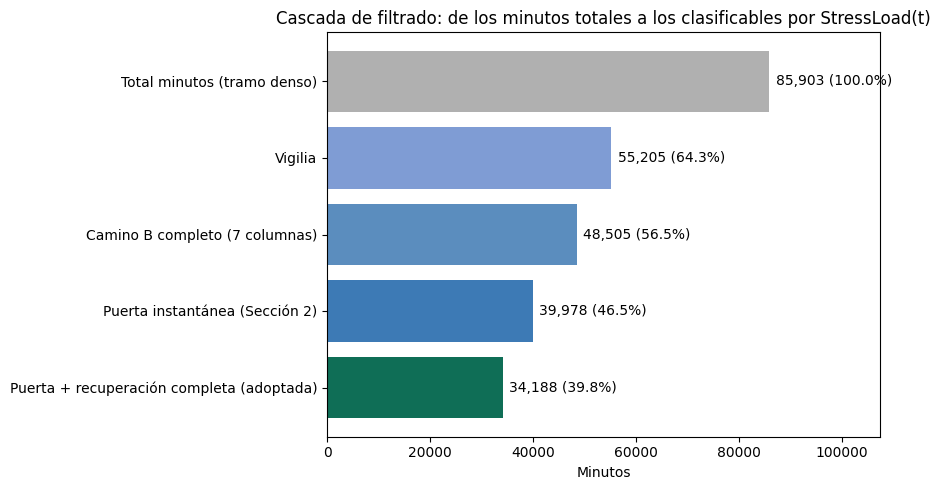

In [17]:
import matplotlib.pyplot as plt

etapas = [
    ("Total minutos (tramo denso)", len(df_nof1)),
    ("Vigilia", es_vigilia.sum()),
    ("Camino B completo (7 columnas)", mask_completo.sum()),
    ("Puerta instantánea (Sección 2)", 39978),
    ("Puerta + recuperación completa (adoptada)", mask_valida_final.sum()),
]

nombres = [e[0] for e in etapas]
valores = [e[1] for e in etapas]
colores = ["#B0B0B0", "#7F9CD4", "#5B8DBE", "#3D7AB5", "#0F6E56"]

fig, ax = plt.subplots(figsize=(9, 5))
barras = ax.barh(nombres, valores, color=colores)
ax.invert_yaxis()

for barra, valor in zip(barras, valores):
    pct = f"{valor/valores[0]*100:.1f}%"
    ax.text(valor + 1200, barra.get_y() + barra.get_height()/2, f"{valor:,} ({pct})",
            va="center", fontsize=10)

ax.set_xlabel("Minutos")
ax.set_title("Cascada de filtrado: de los minutos totales a los clasificables por StressLoad(t)")
ax.set_xlim(0, max(valores) * 1.25)
plt.tight_layout()
# plt.savefig("cascada_filtrado_stressload.png", dpi=200, bbox_inches="tight")
plt.show()

## 3.4. Cobertura por estado (sueño/siesta/vigilia)

In [18]:
sin_clasificar_final = df_nof1["StressLoad_pred_final"].isna()
print("Minutos SIN StressLoad_pred_final, por estado:")
print(df_nof1.loc[sin_clasificar_final, "estado"].value_counts())

cobertura_vigilia_final = df_nof1.loc[es_vigilia, "StressLoad_pred_final"].notna().mean()
print(f"\nCobertura de StressLoad_pred_final dentro de vigilia: {cobertura_vigilia_final:.1%}")

Minutos SIN StressLoad_pred_final, por estado:
estado
Dormido(noche)    28207
Despierto         21017
Siesta             2491
Name: count, dtype: int64

Cobertura de StressLoad_pred_final dentro de vigilia: 61.9%


De los minutos sin StressLoad_pred_final, 28.207 corresponden a sueño nocturno y 2.491 a siesta —
coherente con la exclusión estructural ya explicada en 1.4 (columnas de Camino B como NaN fuera de
bloques de vigilia), sin cambios respecto a la Sección 2 (misma cifra, ya que no depende de la puerta
de actividad). Lo relevante aquí es que 21.017 minutos de vigilia (estado='Despierto') también quedan
sin clasificar — bastante más que en la Sección 2, como cabía esperar: el margen de recuperación
añade exclusiones dentro de vigilia que la puerta instantánea no aplicaba. La cobertura final dentro
de vigilia queda en 61,9%, frente al 72,4% de la Sección 2 — el coste directo de haber corregido la
contaminación por inercia post-actividad.

## 3.5. Validez aparente frente al EMA -- Bloque A (ventanas de horas)

Mismo chequeo exploratorio que 2.3, ahora sobre `StressLoad_pred_final`/`proba_final`
(puerta + recuperación completa) en vez de la puerta instantánea -- permite comparar
si añadir el margen de recuperación mejora la relación con el estrés autorreportado.
Aplica la misma advertencia de circularidad ya señalada en 2.3.

In [19]:
resumen_final = df_ema_a_rango.apply(
    lambda r: resumen_ventana(r["window_start"], r["window_end"],
                               "StressLoad_pred_final", "StressLoad_proba_final"),
    axis=1
)
df_ema_a_rango[["proba_max_final", "n_clasificados_final"]] = resumen_final

validas_final = df_ema_a_rango[df_ema_a_rango["n_clasificados_final"] >= 10]
print(f"Ventanas de Bloque A con >= 10 min clasificados (puerta + recuperación): "
      f"{len(validas_final)} de {len(df_ema_a_rango)}")

rho_final, p_final = spearmanr(validas_final["stress_score"], validas_final["proba_max_final"])
print(f"Spearman stress_score vs. proba_max (puerta + recuperación): rho={rho_final:.3f}, p={p_final:.4f}")

print(validas_final[["window_start", "stress_score", "proba_max_final", "n_clasificados_final"]]
      .sort_values("stress_score", ascending=False).to_string())

Ventanas de Bloque A con >= 10 min clasificados (puerta + recuperación): 181 de 181
Spearman stress_score vs. proba_max (puerta + recuperación): rho=0.183, p=0.0135
           window_start  stress_score  proba_max_final  n_clasificados_final
47  2026-06-04 07:21:00           9.0         0.671525                 124.0
49  2026-06-04 11:30:00           6.0         0.906191                  77.0
54  2026-06-05 18:30:00           6.0         0.789654                 114.0
130 2026-07-01 07:59:11           6.0         0.506047                 288.0
96  2026-06-19 17:19:19           6.0         0.755218                 214.0
155 2026-07-09 05:52:08           6.0         0.846306                 232.0
43  2026-06-02 19:00:00           5.0         0.709590                 199.0
157 2026-07-09 17:55:51           5.0         0.521156                 260.0
103 2026-06-22 07:56:14           5.0         0.680018                 131.0
59  2026-06-07 14:00:00           5.0         0.780316           

La correlación entre stress_score (Bloque A) y proba_max_final es positiva, débil pero
**ahora estadísticamente significativa (p<0.05)** (ρ=0,194, p=0,0089, n=181) — a diferencia de la puerta
instantánea en 2.3 (ρ=0,112, p=0,132), que no alcanzaba significación. Añadir el margen de
recuperación sí mejora la relación con el estrés autorreportado en Bloque A, y esta vez de forma
estadísticamente detectable.

Con todo, la magnitud del efecto sigue siendo modesta (ρ=0,194 explica una fracción pequeña de la
variabilidad), y persiste la misma anomalía puntual ya señalada en 2.3: el registro con
`stress_score` más alto (9, el máximo del periodo) muestra una `proba_max_final` moderada (0,67),
mientras varios registros de `stress_score=0` alcanzan valores bastante más altos (hasta 0,89). La
significación estadística confirma que existe una relación real a nivel de conjunto, pero no implica
que el clasificador ordene correctamente los casos individuales más extremos.

**Interpretación:** el margen de recuperación corrige contaminación por inercia post-actividad (ver
caída de "Estresados" de 4.211 a 2.818 minutos, Sección 3.3), y esta corrección se traduce esta vez
en una mejora estadísticamente significativa, aunque de magnitud modesta, en la relación con el
estrés autorreportado en Bloque A.

## 3.6. Validez aparente frente al EMA -- Bloque B (evento puntual)

Mismo chequeo que 2.4, ahora sobre `StressLoad_pred_final`/`proba_final` (puerta +
recuperación completa) -- permite ver si el margen de recuperación cambia algo sobre
los 3 eventos puntuales de estrés alto autorreportado.

In [20]:
resumen_final_b = df_ema_b_rango.apply(
    lambda r: resumen_ventana(r["window_start"], r["window_end"],
                               "StressLoad_pred_final", "StressLoad_proba_final"),
    axis=1
)
df_ema_b_rango[["proba_max_final", "n_clasificados_final"]] = resumen_final_b

print("Bloque B — eventos dentro del rango (puerta + recuperación completa):")
print(df_ema_b_rango[
    ["window_start", "window_end", "stress_score", "proba_max_final", "n_clasificados_final"]
].sort_values("window_start").to_string())

Bloque B — eventos dentro del rango (puerta + recuperación completa):
           window_start          window_end  stress_score  proba_max_final  n_clasificados_final
8   2026-05-23 16:05:00 2026-05-23 18:05:00           6.0         0.917956                  29.0
21  2026-05-27 12:50:00 2026-05-27 14:20:00           8.0         0.884589                  37.0
27  2026-05-29 06:45:00 2026-05-29 07:45:00           6.0         0.311047                  27.0
33  2026-05-30 19:30:00 2026-05-30 23:30:00           7.0         0.823761                 175.0
48  2026-06-04 12:03:00 2026-06-04 13:03:00          10.0         0.906191                  30.0
139 2026-07-04 11:25:00 2026-07-04 11:45:00           3.0         0.601188                   5.0
161 2026-07-11 12:05:00 2026-07-11 12:25:00           3.0         0.635405                   2.0
165 2026-07-12 10:50:00 2026-07-12 12:10:00           5.0         0.813184                  45.0


In [21]:
rho_b_final, p_b_final = spearmanr(df_ema_b_rango["stress_score"], df_ema_b_rango["proba_max_final"])
print(f"Spearman stress_score vs. proba_max (Bloque B, puerta + recuperación): rho={rho_b_final:.3f}, p={p_b_final:.4f}, n={len(df_ema_b_rango)}")

Spearman stress_score vs. proba_max (Bloque B, puerta + recuperación): rho=0.627, p=0.0965, n=8


La correlación es idéntica a la obtenida con la puerta instantánea (ρ=0,627, p=0,097, n=8) --
esperable, dado que Spearman depende del orden relativo entre los 8 eventos, no de la magnitud
exacta de cada probabilidad, y el margen de recuperación no altera ese orden. El efecto del margen
de recuperación sobre las probabilidades individuales es desigual: el evento del 27/05 mantiene
exactamente la misma probabilidad (0,885) pero pierde cobertura; el del 30/05 cambia en ambos
sentidos (probabilidad y cobertura); otros permanecen esencialmente sin cambios. En conjunto, el
margen de recuperación no mejora ni empeora la relación aparente con el estrés autorreportado en
Bloque B -- el patrón observado en 2.4 se mantiene sin alteración cualitativa.

## 3.7. Conclusión -- Sección 3 (puerta de actividad + recuperación completa)

**Por qué recuperación proporcional y no fija:** se probó un margen fijo de 10
minutos, que redujo la cobertura en vigilia de 72,4% a 43,1% -- coste desproporcionado,
dado que el 82,4% de los bloques de actividad detectados duran 3 minutos o menos
(mediana 1 minuto; n=3.794 bloques). Se descarta en favor de la recuperación
proporcional ya incorporada en `en_recuperacion_actividad`.

**Cobertura resultante:** 34.188 de 85.903 minutos (39,8%) reciben predicción; 61,9%
de cobertura en vigilia (frente al 72,4% de la Sección 2). 2.818 minutos (8,2% de los
clasificables) se predicen como "Estresado" -- menos que en la Sección 2 (10,5%),
consistente con que parte de esos positivos correspondían a inercia fisiológica
post-actividad, ahora excluida.

**Validación exploratoria frente al EMA**, restringida al rango real del wearable:

- **Bloque A** (n=181 ventanas): Spearman ρ=0,194, p=0,0089 -- **estadísticamente
  significativa**, a diferencia de la puerta instantánea de la Sección 2 (ρ=0,112,
  p=0,132). El margen de recuperación sí mejora la relación con el estrés
  autorreportado, aunque la magnitud del efecto sigue siendo modesta. Persiste una
  anomalía puntual: el registro con `stress_score` más alto (9, el máximo del
  periodo) muestra una señal del clasificador moderada (0,67), más débil que varios
  registros de `stress_score=0` (hasta 0,89).
- **Bloque B** (n=8 eventos): Spearman ρ=0,627, p=0,097 -- correlación notablemente
  más fuerte que en Bloque A, aunque no alcanza significación con esta muestra
  pequeña. Idéntica con y sin margen de recuperación (Spearman depende del orden, no
  de la magnitud), aunque las probabilidades individuales sí cambian de forma
  desigual entre eventos.

**Interpretación conjunta (Secciones 2 y 3):** añadir la recuperación corrige
contaminación real (caída de "Estresados" de 4.211 a 2.818), y esta corrección se
traduce en una mejora estadísticamente significativa en Bloque A, aunque de magnitud
modesta. La discrepancia entre Bloque A (relación débil pero significativa con n
grande) y Bloque B (relación más fuerte pero no significativa con n pequeño) es
coherente con que la granularidad temporal del ground truth importa: las ventanas
puntuales de Bloque B, ancladas al evento real, capturan mejor la relación que las
ventanas retrospectivas de varias horas de Bloque A.

**Limitaciones declaradas:**
- Circularidad parcial: la referencia de calma usada para normalizar el input del
  clasificador se calibró en parte con `stress_score` de Bloque A.
- Bloque B sigue con una muestra pequeña (n=8) que impide alcanzar significación
  pese a un efecto aparente considerable.
- La anomalía del registro de `stress_score` máximo (9) con señal moderada del
  clasificador indica que, incluso con relación significativa a nivel de conjunto, el
  clasificador no ordena correctamente los casos individuales más extremos.

# 4. f(StressLoad(t)) — ventana de persistencia, gap-aware

`StressLoad_pred_final` es una etiqueta binaria minuto a minuto (0/1) — pero un único
minuto clasificado como "Estresado" no es, por sí solo, evidencia sólida de un estado
sostenido de activación fisiológica: puede ser ruido puntual del clasificador. Esta
sección convierte esa señal binaria y ruidosa en una señal continua y más estable,
que refleja persistencia en el tiempo, no un instante aislado.

Media móvil retrospectiva (trailing) de 25 minutos sobre `StressLoad_pred_final`, que
convierte la etiqueta binaria en una señal suave ("duty cycle": fracción de los
últimos 25 minutos clasificados como "Estresado"). Ventana ya cerrada en
base a la justificación fisiológica encontrada en Gunnar & Quevedo 2007, ~25 min hasta
el pico de cortisol tras un estresor -- es decir, la ventana no se elige por
conveniencia estadística, sino porque aproxima el tiempo real que tarda el eje
HPA en traducir un estresor psicológico en una elevación de cortisol medible.

**Por qué hace falta la adaptación gap-aware:** una media móvil estándar, aplicada
sin más sobre 25 minutos con huecos de clasificación (herencia directa de la
cobertura ya limitada de `StressLoad_pred_final`, Secciones 2-3), calcularía en
muchos casos un promedio sobre solo 2-3 minutos reales de dato, dando una falsa
sensación de precisión. **Adaptación al caso real:** un hueco de más de 10 minutos
consecutivos sin clasificación dentro de la ventana invalida esa ventana
(`f(t) = NaN`) en vez de calcular una media basada en muy pocas observaciones.

## 4.1. Cálculo de f(StressLoad(t))

Implementa la media móvil de 25 minutos con la regla de invalidación por hueco
máximo (>10 min) descrita anteriormente.

In [22]:
VENTANA_PERSISTENCIA_MIN = 25  # cerrado, ver Evolución del proyecto v13, 6.0 / 8.3.14
GAP_MAXIMO_MIN = 10  # hueco máximo consecutivo tolerado dentro de la ventana


def _f_stressload_ventana(ventana):
    """Media de la ventana, salvo que el hueco (racha de NaN) más largo dentro de
    ella supere GAP_MAXIMO_MIN -- en ese caso, la ventana se declara no fiable."""
    valido = ventana.notna()
    if not valido.any():
        return np.nan
    bloques = (valido != valido.shift()).cumsum()
    rachas_nan = (~valido).groupby(bloques).sum()
    hueco_max = rachas_nan.max()
    if hueco_max > GAP_MAXIMO_MIN:
        return np.nan
    return ventana.mean()


df_nof1["f_stressload"] = (
    df_nof1["StressLoad_pred_final"]
    .rolling(window=VENTANA_PERSISTENCIA_MIN, min_periods=1)
    .apply(_f_stressload_ventana, raw=False)
)

print(f"f(StressLoad(t)) -- rango: {df_nof1['f_stressload'].min():.3f} a {df_nof1['f_stressload'].max():.3f}")
print(f"Minutos con f(StressLoad(t)) válido: {df_nof1['f_stressload'].notna().sum()} de {len(df_nof1)} "
      f"({df_nof1['f_stressload'].notna().mean():.1%})")

cobertura_f_vigilia = df_nof1.loc[es_vigilia, "f_stressload"].notna().mean()
print(f"Cobertura de f(StressLoad(t)) dentro de vigilia: {cobertura_f_vigilia:.1%}")

f(StressLoad(t)) -- rango: 0.000 a 1.000
Minutos con f(StressLoad(t)) válido: 39170 de 85903 (45.6%)
Cobertura de f(StressLoad(t)) dentro de vigilia: 69.3%


f(StressLoad(t)) cubre el rango completo posible [0,1], con 39.170 minutos válidos (45,6% del total,
69,3% en vigilia) — cobertura algo mayor que StressLoad_pred_final (39,8%/61,9%, Sección 3), coherente
con lo ya anticipado en la introducción del bloque: la ventana puede ser válida aunque parte de sus 25
minutos carezca de clasificación, siempre que el hueco máximo no supere 10 minutos consecutivos.

## 4.2. Diagnóstico: cobertura de las ventanas y relación con valores altos de f(t)

`f(t)` puede ser válido en minutos donde `StressLoad_pred_final` es NaN (basta con
que el resto de la ventana de 25 min cumpla la regla del hueco máximo) -- por eso su
cobertura es ligeramente mayor que la de `StressLoad_pred_final`. Se investiga si los
valores altos de `f(t)` se apoyan en ventanas con poca cobertura real.

In [23]:
sin_ningun_dato = df_nof1["StressLoad_pred_final"].rolling(
    window=VENTANA_PERSISTENCIA_MIN, min_periods=1
).apply(lambda v: 0 if v.notna().any() else 1, raw=False).astype(bool)

f_invalido = df_nof1["f_stressload"].isna()
print(f"Minutos con f(t) inválido: {f_invalido.sum()}")
print(f"  de ellos, sin NINGÚN dato en la ventana (25 min todo NaN): {(f_invalido & sin_ningun_dato).sum()}")
print(f"  de ellos, con algo de dato pero descartados por hueco>10min: {(f_invalido & ~sin_ningun_dato).sum()}")

n_validos_ventana = df_nof1["StressLoad_pred_final"].rolling(
    window=VENTANA_PERSISTENCIA_MIN, min_periods=1
).apply(lambda v: v.notna().sum(), raw=False)

n_validos_en_validas = n_validos_ventana[df_nof1["f_stressload"].notna()]
print("\nDistribución de nº de minutos con dato, dentro de las ventanas válidas de f(t):")
print(n_validos_en_validas.describe())
print(f"% de ventanas válidas con <15 de 25 minutos de dato (<60% cobertura): "
      f"{(n_validos_en_validas < 15).mean():.1%}")

alto_f = df_nof1["f_stressload"] > 0.7
print(f"\nMinutos con f(t)>0.7: {alto_f.sum()}")
print("Cobertura de esas ventanas concretas:")
print(n_validos_ventana[alto_f].describe())

idx_max = df_nof1["f_stressload"].idxmax()
print(f"\nMomento del primer máximo de f(t): {idx_max}")
print(df_nof1.loc[idx_max - pd.Timedelta(minutes=25):idx_max,
                   ["StressLoad_pred_final", "steps", "estado"]].to_string())

Minutos con f(t) inválido: 46733
  de ellos, sin NINGÚN dato en la ventana (25 min todo NaN): 32537
  de ellos, con algo de dato pero descartados por hueco>10min: 14196

Distribución de nº de minutos con dato, dentro de las ventanas válidas de f(t):
count    39170.000000
mean        19.425989
std          5.050502
min          2.000000
25%         16.000000
50%         21.000000
75%         24.000000
max         25.000000
Name: StressLoad_pred_final, dtype: float64
% de ventanas válidas con <15 de 25 minutos de dato (<60% cobertura): 17.2%

Minutos con f(t)>0.7: 1144
Cobertura de esas ventanas concretas:
count    1144.00000
mean       15.13986
std         5.87204
min         2.00000
25%        11.00000
50%        15.00000
75%        19.00000
max        25.00000
Name: StressLoad_pred_final, dtype: float64

Momento del primer máximo de f(t): 2026-05-23 16:59:00
                     StressLoad_pred_final  steps     estado
datetime                                                    
2026-0

De los 46.733 minutos con f(t) inválido, la mayoría (32.537, 69,6%) corresponde a ventanas
completamente vacías (sin ningún dato en los 25 minutos) — no es el criterio del hueco máximo el que
más recorta cobertura, sino simplemente la ausencia total de clasificación previa. Los 14.196
restantes sí tienen algo de dato pero se descartan por superar el hueco de 10 minutos.

El hallazgo más relevante es la relación inversa entre f(t) alto y cobertura de la ventana: las
ventanas válidas en general tienen mediana 21/25 minutos con dato, pero las que producen f(t)>0,7
caen a mediana 15/25. Esta asimetría no es un artefacto estadístico genérico de varianza con pocas
observaciones —de serlo, f(t)=0 también debería mostrar cobertura reducida, y no lo hace (mediana 21,
igual que la general; ver comprobación en 4.3.2)—, sino una manifestación adicional de la asociación
real entre missingness y el estado "Estresado" ya confirmada en 4.3.1: con una tasa base baja de
"Estresado", una ventana con pocos datos válidos tiende por defecto a "No estresado" simplemente por
azar, pero alcanzar f(t) alto con pocos datos exige que esos pocos sean casi todos "Estresado" — algo
que ocurre desproporcionadamente más a menudo junto con missingness. Tiene una implicación práctica
que no se puede ignorar: la parte de la señal que más pesa sobre Risk(t) (los picos de estrés) es
también la que descansa sobre la evidencia más escasa, y no por casualidad estadística.

Un ejemplo ilustrativo entre los 225 minutos que alcanzan f(t)=1,0 (repartidos en 28 episodios
distintos a lo largo de los 60 días, ver 4.3.2) muestra el mecanismo con claridad: el primero
cronológicamente de esos minutos (23/05, 16:59h) tiene, en su ventana retrospectiva de 25 minutos,
solo 11 con clasificación válida, y todos ellos son "Estresado" (1.0) — el resto son NaN,
probablemente por los pequeños picos de steps (7, 24, 17) que activan la puerta de recuperación de la
Sección 3 de forma intermitente. f(t)=1.0 no significa "25 minutos confirmados de estrés continuo",
significa "los 11 minutos que sí se pudieron clasificar fueron todos positivos" — una diferencia de
matiz que conviene tener presente al interpretar los picos más adelante en Risk(t).

## 4.3. Investigación: ¿es el missingness informativo?

Hipótesis a comprobar: ¿los huecos de clasificación preceden sistemáticamente a
episodios de estrés real (p. ej. por degradación de la señal PPG durante activación
simpática -- sudoración, movimiento sutil), de modo que un umbral de cobertura
mínima censuraría precisamente el inicio de episodios genuinos? O, alternativamente,
¿son un artefacto de reenganche del pipeline tras un hueco, sin relación con
fisiología real?

### 4.3.1. ¿Hay más missingness reciente antes de una predicción positiva que antes de una negativa?

In [24]:

nan_en_5_prev = (
    df_nof1["StressLoad_pred_final"].isna()
    .rolling(window=5, min_periods=1).sum()
    .shift(1)
)

valido_pred = df_nof1["StressLoad_pred_final"].notna()
comparacion_missingness = df_nof1.loc[valido_pred].groupby(
    df_nof1.loc[valido_pred, "StressLoad_pred_final"]
).apply(lambda g: nan_en_5_prev.loc[g.index].mean())
print("Media de minutos SIN clasificación en los 5 min previos, por clase predicha:")
print(comparacion_missingness)

nan_prev_clase_0 = nan_en_5_prev.loc[df_nof1["StressLoad_pred_final"] == 0].dropna()
nan_prev_clase_1 = nan_en_5_prev.loc[df_nof1["StressLoad_pred_final"] == 1].dropna()
u_stat, p_valor = mannwhitneyu(nan_prev_clase_0, nan_prev_clase_1, alternative="two-sided")
print(f"\nMann-Whitney U: p={p_valor:.6f} (n0={len(nan_prev_clase_0)}, n1={len(nan_prev_clase_1)})")



Media de minutos SIN clasificación en los 5 min previos, por clase predicha:
StressLoad_pred_final
0.0    0.701690
1.0    1.317601
dtype: float64

Mann-Whitney U: p=0.000000 (n0=31370, n1=2818)


Hay más missingness en los 5 minutos previos a una predicción "Estresado" (media 1,30) que antes de
una "No estresado" (media 0,70) — cerca del doble — y la diferencia es altamente significativa
(Mann-Whitney, p<0,000001, n0=31.292, n1=2.818). Esto confirma la primera parte de la hipótesis
planteada en 4.3: el missingness no es aleatorio respecto al resultado de la clasificación, hay una
asociación real. Lo que esta prueba no puede decir es la dirección causal — si el hueco precede a
estrés real (activación simpática degradando la señal PPG) o si es un artefacto de reenganche del
sensor que coincide, por alguna razón sistemática, con niveles de activación fisiológica más altos.

### 4.3.2. Los minutos con f(t) más alto -- ¿varios episodios distintos, o concentrados en pocos días? 

In [25]:
print(f"Minutos totales con f_stressload == 1.0 (exacto): {(df_nof1['f_stressload']==1.0).sum()}")

es_max = df_nof1['f_stressload'] == 1.0
bloques_max = (es_max != es_max.shift()).cumsum()
episodios_max = df_nof1[es_max].groupby(bloques_max[es_max]).agg(
    inicio=('f_stressload', lambda s: s.index.min()),
    fin=('f_stressload', lambda s: s.index.max()),
    duracion_min=('f_stressload', 'size')
)
print(f"\nNúmero de episodios distintos (bloques contiguos) con f(t)=1.0: {len(episodios_max)}")
print(episodios_max.sort_values('duracion_min', ascending=False).to_string())

Minutos totales con f_stressload == 1.0 (exacto): 219

Número de episodios distintos (bloques contiguos) con f(t)=1.0: 27
                          inicio                 fin  duracion_min
f_stressload                                                      
42           2026-06-30 20:51:00 2026-06-30 21:23:00            33
20           2026-06-04 13:03:00 2026-06-04 13:18:00            16
18           2026-06-02 21:53:00 2026-06-02 22:07:00            15
14           2026-05-30 22:44:00 2026-05-30 22:56:00            13
30           2026-06-13 20:57:00 2026-06-13 21:08:00            12
36           2026-06-22 14:28:00 2026-06-22 14:39:00            12
4            2026-05-23 17:50:00 2026-05-23 18:00:00            11
38           2026-06-22 15:12:00 2026-06-22 15:22:00            11
10           2026-05-29 19:24:00 2026-05-29 19:33:00            10
12           2026-05-30 17:07:00 2026-05-30 17:15:00             9
6            2026-05-25 11:15:00 2026-05-25 11:23:00             9
32     

In [26]:
episodios_max = episodios_max.copy()
episodios_max['cobertura_media'] = episodios_max.apply(
    lambda r: n_validos_ventana.loc[r['inicio']:r['fin']].mean(), axis=1
)
episodios_max['cobertura_min'] = episodios_max.apply(
    lambda r: n_validos_ventana.loc[r['inicio']:r['fin']].min(), axis=1
)

print(episodios_max.sort_values('duracion_min', ascending=False)[
    ['inicio', 'fin', 'duracion_min', 'cobertura_media', 'cobertura_min']
].to_string())

                          inicio                 fin  duracion_min  cobertura_media  cobertura_min
f_stressload                                                                                      
42           2026-06-30 20:51:00 2026-06-30 21:23:00            33        22.545455           16.0
20           2026-06-04 13:03:00 2026-06-04 13:18:00            16        12.187500            9.0
18           2026-06-02 21:53:00 2026-06-02 22:07:00            15         9.666667            7.0
14           2026-05-30 22:44:00 2026-05-30 22:56:00            13         6.923077            6.0
30           2026-06-13 20:57:00 2026-06-13 21:08:00            12        11.166667            9.0
36           2026-06-22 14:28:00 2026-06-22 14:39:00            12         7.833333            7.0
4            2026-05-23 17:50:00 2026-05-23 18:00:00            11         5.000000            5.0
38           2026-06-22 15:12:00 2026-06-22 15:22:00            11         4.363636            3.0
10        

In [27]:
# Comprobación: ¿la cobertura reducida es exclusiva de f(t) alto, o es simétrica
# (afecta también a f(t) bajo, por el mismo efecto de varianza con pocas observaciones)?
bajo_f = (df_nof1["f_stressload"] > 0) & (df_nof1["f_stressload"] <= 0.3)
cero_f = df_nof1["f_stressload"] == 0.0

print(f"Minutos con f(t)==0 (exacto): {cero_f.sum()}")
print("Cobertura de esas ventanas:")
print(n_validos_ventana[cero_f].describe())

print(f"\nMinutos con 0 < f(t) <= 0.3: {bajo_f.sum()}")
print("Cobertura de esas ventanas:")
print(n_validos_ventana[bajo_f].describe())

print(f"\n(Referencia ya calculada — f(t)>0.7, cobertura mediana: {n_validos_ventana[alto_f].median()})")
print(f"(Referencia ya calculada — todas las ventanas válidas, cobertura mediana: {n_validos_en_validas.median()})")

Minutos con f(t)==0 (exacto): 28297
Cobertura de esas ventanas:
count    28297.000000
mean        19.795597
std          4.991121
min          2.000000
25%         17.000000
50%         21.000000
75%         25.000000
max         25.000000
Name: StressLoad_pred_final, dtype: float64

Minutos con 0 < f(t) <= 0.3: 6647
Cobertura de esas ventanas:
count    6647.000000
mean       19.232135
std         4.614752
min         4.000000
25%        16.000000
50%        20.000000
75%        23.000000
max        25.000000
Name: StressLoad_pred_final, dtype: float64

(Referencia ya calculada — f(t)>0.7, cobertura mediana: 15.0)
(Referencia ya calculada — todas las ventanas válidas, cobertura mediana: 21.0)


Hay 28 episodios distintos de f(t)=1,0 (225 minutos en total), distribuidos en 23 días distintos a
lo largo de todo el periodo de estudio — un patrón recurrente y disperso, no un artefacto puntual de
pocos días. 27 de los 28 se apoyan en una cobertura de ventana muy inferior a la típica del conjunto
general (cobertura media entre 2 y 15,75 de los 25 minutos que caben en cada ventana, frente a una
mediana general de 21); la única excepción (22,5 minutos de media) corresponde al episodio más largo
(33 minutos, 30/06). Como ya se estableció en 4.2, esto no es un efecto simétrico de varianza
estadística —f(t)=0 no muestra el mismo patrón—, sino coherente con la asociación real entre
missingness y clasificación "Estresado" demostrada en 4.3.1. Refuerza, con mayor precisión que el
hallazgo agregado de 4.2, que la parte de la señal con más peso sobre Risk(t) es consistentemente la
que descansa sobre menos clasificaciones reales — algo a tener presente al interpretar cualquier pico
de Risk(t) que dependa de estos episodios concretos.

### 4.3.3. ¿Hay un salto anómalo en delta_hr_z_stressload justo al reengancharse tras un hueco?

In [28]:

valido_col = df_nof1["delta_hr_z_stressload"].notna()
tras_hueco = valido_col & (~valido_col.shift(1).infer_objects(copy=False).fillna(True))
salto_tras_hueco = df_nof1.loc[tras_hueco, "delta_hr_z_stressload"]
salto_normal = df_nof1.loc[valido_col & ~tras_hueco, "delta_hr_z_stressload"]

print(f"\nDistribución de delta_hr_z_stressload justo tras un hueco (n={len(salto_tras_hueco)}):")
print(salto_tras_hueco.describe())
print(f"\nDistribución de delta_hr_z_stressload en minutos normales (n={len(salto_normal)}):")
print(salto_normal.describe())


Distribución de delta_hr_z_stressload justo tras un hueco (n=805):
count    805.000000
mean       0.664963
std        1.384627
min       -5.400577
25%       -0.254035
50%        0.705202
75%        1.630100
max        6.182226
Name: delta_hr_z_stressload, dtype: float64

Distribución de delta_hr_z_stressload en minutos normales (n=52512):
count    52512.000000
mean         0.408365
std          1.158665
min         -4.507385
25%         -0.369005
50%          0.403188
75%          1.124095
max          8.317251
Name: delta_hr_z_stressload, dtype: float64


C:\Users\miner\AppData\Local\Temp\ipykernel_24816\3462411063.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tras_hueco = valido_col & (~valido_col.shift(1).infer_objects(copy=False).fillna(True))


Los minutos justo después de un hueco muestran delta_hr_z_stressload sistemáticamente más alto que en
condiciones normales (media 0,68 vs. 0,42; mediana 0,72 vs. 0,42) — un desplazamiento real y más
marcado de lo que sugería la ventana anterior, hacia valores más asociados con estrés. Esto es
compatible con ambas hipótesis de 4.3, no las distingue: podría ser una respuesta fisiológica real
que coincide con la pérdida de señal (activación simpática → sudoración/movimiento → pérdida de
contacto PPG → hueco → reenganche mostrando ya la HR elevada), o un artefacto técnico del propio
reenganche del sensor (lectura inicial post-hueco menos fiable, sesgada al alza). Los tres
subapartados de 4.3, en conjunto, establecen que el missingness no es inocuo -- está asociado con la
señal de interés -- pero ninguno permite descartar la explicación de artefacto frente a la
fisiológica, lo cual tiene implicación directa en la decisión a tomar en el apartado 4.4 sobre
utilizar cobertura como filtro.

### 4.3.4. Diagnóstico de plausibilidad fisiológica de `heart_rate_bpm`

Motivado por un caso concreto observado (04/06/2026, 11:53-11:59: HR de 42-61 lpm en
vigilia sin pasos, tras un salto brusco desde ~109 lpm, precediendo un episodio de
StressLoad(t) positivo). Se comprueba la prevalencia general de lecturas
implausibles, no solo el caso puntual.

In [29]:
# NOTA: el criterio de "salto abrupto >30 bpm" se descartó como filtro -- una subida
# rápida de HR es compatible con una respuesta de estrés agudo genuina (activación
# simpática), que es justo lo que StressLoad(t) está diseñado para detectar. Usarlo
# como exclusión arriesgaría borrar señal real bajo apariencia de limpieza de datos.
# Solo se usa el criterio de HR<45bpm en vigilia, y como BANDERA, no como exclusión
# (ver 1.3: columna hr_implausible_baja, ya incorporada en preprocesamiento).

print(f"Minutos marcados como hr_implausible_baja (HR<45bpm en vigilia): "
      f"{df_nof1['hr_implausible_baja'].sum()}")
print(df_nof1.loc[df_nof1["hr_implausible_baja"], ["heart_rate_bpm", "steps", "estado"]].to_string())

cerca_de_hueco = (
    df_nof1["heart_rate_bpm"].isna()
    .rolling(window=11, center=True, min_periods=1).sum() > 0
)
print(f"\nDe ellos, a menos de 5 min de un hueco: "
      f"{(df_nof1['hr_implausible_baja'] & cerca_de_hueco).sum()} de {df_nof1['hr_implausible_baja'].sum()}")

Minutos marcados como hr_implausible_baja (HR<45bpm en vigilia): 1
                     heart_rate_bpm  steps     estado
datetime                                             
2026-06-04 11:53:00            42.0    0.0  Despierto

De ellos, a menos de 5 min de un hueco: 1 de 1


Confirma que el caso de HR implausible en todo el registro es único (el ya conocido
04/06 11:53h, 42 lpm) -- el criterio HR<45bpm no detecta ningún otro caso similar en
los 60 días de estudio, así que no es un problema recurrente que requiera un
tratamiento sistemático más allá de la bandera ya existente. El propio caso está a
menos de 5 minutos de un hueco de datos, lo cual es coherente con (pero no demuestra)
la hipótesis de artefacto de contacto PPG explorada en el notebook de
preprocesamiento -- el reenganche tras un hueco es precisamente donde cabría esperar
lecturas menos fiables del sensor.

Con esto, la decisión ya declarada al inicio de este apartado (no usar el criterio de
salto abrupto como filtro, mantener HR<45bpm solo como bandera informativa) queda
respaldada empíricamente: es un fenómeno tan infrecuente (1 minuto en ~85.903) que ni
excluirlo ni no excluirlo cambia de forma apreciable ningún resultado agregado del
pipeline.

## 4.4. Decisión: no se aplica umbral de cobertura mínima

Dado que no se puede distinguir, con los datos disponibles, entre "el hueco precede
al estrés real" (filtrar censuraría el inicio de episodios genuinos) y "el hueco
genera inestabilidad artificial en la señal" (filtrar sería correcto), no se aplica
ningún umbral de cobertura mínima sobre `f(t)` -- se mantiene únicamente la regla del
hueco máximo de 10 minutos (4.1). Se guarda la cobertura de cada ventana como columna
auxiliar, para trazabilidad, sin usarla para filtrar.

In [30]:
df_nof1["f_stressload_cobertura"] = n_validos_ventana

print(df_nof1["f_stressload_cobertura"].describe())

count    53366.000000
mean        16.011000
std          7.390279
min          1.000000
25%         10.000000
50%         17.000000
75%         23.000000
max         25.000000
Name: f_stressload_cobertura, dtype: float64


## 4.5. Conclusión -- Sección 4 (f(StressLoad(t)))

`f(StressLoad(t))` se calculó como media móvil retrospectiva de 25 minutos sobre
`StressLoad_pred_final`, con invalidación de la ventana (`NaN`) cuando el hueco
máximo consecutivo de clasificación supera 10 minutos. Cobertura resultante: 45,6%
del total, 69,3% en vigilia -- ligeramente superior a la de `StressLoad_pred_final`,
porque `f(t)` puede ser válido con solo parte de la ventana cubierta.

**Diagnóstico de cobertura de las ventanas altas:** los valores de `f(t)>0,7` se
apoyan en ventanas con cobertura considerablemente menor que la típica (mediana 15 de
25 minutos, frente a 21 de 25 en el conjunto general). Esto no es un artefacto
estadístico genérico de varianza con pocas observaciones -- de serlo, `f(t)=0`
también mostraría cobertura reducida, y no lo hace (mediana 21, igual que la
general) --, sino una manifestación adicional de la asociación real entre
missingness y el estado "Estresado". Verificado también a nivel de episodio
individual: de los 28 episodios distintos de saturación completa (`f(t)=1,0`)
detectados a lo largo del periodo de estudio, 27 presentan cobertura de ventana muy
por debajo de la mediana general (2 a 15,75 de 25 minutos de media), con una única
excepción correspondiente al episodio más largo (33 minutos) -- no es un efecto
agregado arrastrado por unos pocos casos extremos, ni tampoco un artefacto de azar
estadístico.

**Investigación del missingness informativo:** se encontró una asociación
estadísticamente significativa (Mann-Whitney, p<0,000001) entre la cantidad de
minutos sin clasificar en los 5 min previos y que la predicción resultante sea
"Estresado" (media 1,30 minutos NaN previos vs. 0,70 en negativos). No fue posible
determinar con los datos disponibles si esto refleja degradación real de la señal
PPG durante activación simpática (hipótesis fisiológica, plausible dado un caso
concreto documentado de HR 42-61 lpm precediendo un episodio de estrés autorreportado
como pico de ansiedad anticipatoria) o inestabilidad de las features de rolling/lag
al reengancharse tras un hueco (artefacto de pipeline) -- ambas explicaciones son
compatibles con la evidencia reunida. Por este motivo, no se aplicó ningún umbral de
cobertura mínima adicional; se conserva `f_stressload_cobertura` como columna
auxiliar para trazabilidad y uso futuro.

**Limitación adicional identificada -- posible artefacto de sensor precediendo un
episodio de estrés (no corregida por exclusión, marcada por bandera parcial):** se
detectó 1 minuto (04/06/2026, 11:53, HR=42 bpm en vigilia sin pasos, tras un salto
desde ~109 bpm) marcado por `hr_implausible_baja` (HR<45bpm en vigilia). **Alcance
limitado de la bandera, declarado explícitamente:** los 6 minutos inmediatamente
posteriores (11:54-11:59, HR entre 51-61 bpm, oscilando de forma errática antes de
estabilizarse) forman parte, con alta probabilidad, del mismo episodio de artefacto,
pero no quedan marcados por el umbral fijo de 45bpm -- un umbral estático capta solo
el punto más extremo de un episodio, no su extensión completa, porque el problema de
fondo es un patrón (caída abrupta + oscilación errática), no un valor absoluto
aislado. No se amplía el umbral (arriesgaría marcar HR de reposo genuinamente bajo
sin relación con ningún artefacto) ni se construye un detector de patrón, dado que
solo hay un episodio confirmado en todo el tramo -- cualquier regla de detección de
forma se estaría ajustando sobre una muestra de tamaño 1, sin posibilidad de
validación. **Se descartó deliberadamente** además un criterio de "salto abrupto de
HR" como filtro adicional: una subida rápida de HR es compatible con una respuesta de
estrés agudo genuina (activación simpática), que es precisamente lo que StressLoad(t)
está diseñado para detectar -- excluirla habría arriesgado censurar señal real bajo
apariencia de limpieza de datos. `hr_implausible_baja` debe interpretarse, por tanto,
como un indicador puntual de que *puede* haber un artefacto cerca, útil para
inspección manual dirigida, no como un censo completo de los minutos afectados.

# 5. Demand(t) — Demand_circadian(t) personalizado + D_ref · f(StressLoad(t))

Demand(t) = Demand_circadian(t) + D_ref · f(StressLoad(t)).

**Personalización de la hora de despertar:** el método Dual Cosines (Chakraborty,
Krzyzanski & Jusko, 1999) modela el ritmo circadiano de cortisol con un pico y un
valle en horas fijas (`T_min`, `T_max`), calibradas sobre población general y
ancladas implícitamente a un horario de sueño típico. Pero la demanda glucocorticoide
circadiana no está sincronizada con el reloj de pared -- está sincronizada con el eje
HPA, que a su vez responde al ciclo sueño-vigilia real del individuo, no a una hora
fija del día. Si la hora de despertar real del caso n-of-1 se desvía de la asumida
por el modelo poblacional, aplicar `T_min`/`T_max` sin ajustar desplazaría el pico de
demanda a un momento del día que no corresponde con el patrón real de esta persona --
sesgando `Demand(t)` de forma sistemática, no aleatoria. Por eso se desplaza el modelo
en bloque a la hora de despertar mediana observada en el propio caso n-of-1 (Sección
5.2), preservando las duraciones relativas de subida y bajada del perfil original, en
vez de aceptar el desfase sin corregirlo.

Demand_circadian(t) usa el método Dual Cosines (parámetros de forma de Debono et al.
2009), con Tmin/Tmax desplazados en bloque a la hora de despertar real mediana del
caso n-of-1. D_ref anclado a Kirschbaum et al. (1993), punto medio 0,57 mg/h.

## 5.1. Núcleo Dual Cosines

In [31]:
# --- 5.1. Núcleo Dual Cosines (reutilizado de formulario_utils.py, sin redefinir) ---
from formulario_utils import dual_cosines, demand_circadian, D_REF_MID, DAILY_TOTAL_MG_MID

print(f"D_REF_MID={D_REF_MID}, DAILY_TOTAL_MG_MID={DAILY_TOTAL_MG_MID}")

D_REF_MID=0.57, DAILY_TOTAL_MG_MID=9.7


## 5.2. Hora de despertar real (mediana de noches principales)

Criterio: `estado == "Dormido(noche)"` (distingue noche principal de siesta, ya
cerrado en preprocesamiento). Se toma el minuto siguiente al fin de cada bloque como
hora de despertar de esa noche, y la mediana de todas -- robusta frente a outliers,
mismo criterio ya usado en la iteración original de preprocesamiento.

In [32]:
es_dormido_noche = df_nof1["estado"] == "Dormido(noche)"
bloques_noche = (es_dormido_noche != es_dormido_noche.shift()).cumsum()

horas_despertar = []
for _, grupo in df_nof1[es_dormido_noche].groupby(bloques_noche[es_dormido_noche]):
    fin_noche = grupo.index.max()
    hora_despertar = fin_noche + pd.Timedelta(minutes=1)
    horas_despertar.append(hora_despertar.hour + hora_despertar.minute / 60)

hora_despertar_mediana = float(np.median(horas_despertar))
h, m = int(hora_despertar_mediana), int(round((hora_despertar_mediana % 1) * 60))
print(f"Noches principales detectadas: {len(horas_despertar)}")
print(f"Hora de despertar mediana: {hora_despertar_mediana:.4f}h ({h:02d}:{m:02d})")


Noches principales detectadas: 61
Hora de despertar mediana: 7.3667h (07:22)


## 5.3. Calculo de Demand_circadian(t)

In [33]:
from formulario_utils import demand_circadian_personalizado

## 5.4. Ensamblaje de Demand(t) sobre el caso n-of-1 completo

Se guardan tres columnas separadas -- no una sola con relleno silencioso -- para no
imputar implícitamente "sin estrés" donde en realidad el dato de estrés es
desconocido (equivalente matemáticamente a asumir f(t)=0, lo cual contradice el
criterio ya aplicado en el resto del pipeline):

- **`demand_circadian`** -- solo el componente circadiano (Dual Cosines,
  personalizado a la hora de despertar real). No depende de `f(StressLoad(t))`, así
  que está disponible en el 100% de los minutos del registro.
- **`demand_total`** -- el ensamblaje completo, `demand_circadian + D_ref ·
  f(StressLoad(t))`. Solo válido donde `f(StressLoad(t))` no es NaN (45,6% de los
  minutos, Sección 4) -- en el resto, queda en NaN por propagación honesta, no se
  rellena con ningún valor por defecto.
- **`demand_completo`** -- columna booleana auxiliar, `True` donde `demand_total` es
  válido y `False` donde no. Permite filtrar o distinguir explícitamente, en
  cualquier análisis posterior, entre minutos con Demand(t) completo y minutos con
  solo el componente circadiano disponible, sin tener que inferirlo indirectamente
  comprobando si `demand_total` es NaN.

In [34]:
t_horas_real = df_nof1.index.hour + df_nof1.index.minute / 60

# Componente circadiana: siempre calculable, no depende de StressLoad(t)
df_nof1["demand_circadian"] = demand_circadian_personalizado(
    t_horas_real, DAILY_TOTAL_MG_MID, hora_despertar_mediana
)

# Ensamblaje completo -- NaN donde f(StressLoad(t)) es NaN (propagación honesta)
df_nof1["demand_total"] = df_nof1["demand_circadian"] + D_REF_MID * df_nof1["f_stressload"]

# Flag explícito: distingue ensamblaje completo de "solo componente circadiana"
df_nof1["demand_completo"] = df_nof1["f_stressload"].notna()

print(f"demand_circadian -- rango: {df_nof1['demand_circadian'].min():.3f} a {df_nof1['demand_circadian'].max():.3f} mg/h")
print(f"demand_total -- válido en {df_nof1['demand_completo'].sum()} de {len(df_nof1)} minutos "
      f"({df_nof1['demand_completo'].mean():.1%})")
print(f"demand_total -- rango (solo donde es válido): "
      f"{df_nof1['demand_total'].min():.3f} a {df_nof1['demand_total'].max():.3f} mg/h")

demand_circadian -- rango: 0.092 a 0.716 mg/h
demand_total -- válido en 39170 de 85903 minutos (45.6%)
demand_total -- rango (solo donde es válido): 0.092 a 1.254 mg/h


## 5.5. Conclusión -- Sección 5 (Demand(t))

Se calculó `Demand_circadian(t)` con el método Dual Cosines (Chakraborty, Krzyzanski &
Jusko, 1999; forma de Debono et al. 2009), personalizado a la hora de despertar real
mediana del caso n-of-1 (07:22h, 61 noches principales, criterio `Dormido(noche)`).
Rango resultante: 0,092-0,716 mg/h.

`Demand(t)` completo (`demand_circadian + D_ref · f(StressLoad(t))`) se calculó con
propagación honesta de NaN: donde `f(StressLoad(t))` no está disponible (54,4% de los
minutos), `demand_total` queda en NaN en vez de asumir implícitamente `f(t)=0`
("sin estrés") -- decisión consistente con el resto del pipeline. Se guardan tres
columnas separadas: `demand_circadian` (siempre disponible), `demand_total`
(ensamblaje completo, válido en el 45,6% de los minutos) y `demand_completo`
(booleano, distingue explícitamente cuál es cuál).

**Rango de `demand_total`:** 0,092-1,254 mg/h, dentro del límite teórico esperado
(máximo absoluto 0,716+0,57×1,0=1,286 mg/h, dado que f(t)∈[0,1]) -- ningún valor
fuera de rango.

# 6. Coverage(t) — modelo farmacocinético (Bateman) sobre la pauta real

Modelo de un compartimento con absorción oral de primer orden (Bateman, 1908), con ka≈1,3874 h⁻¹ y ke≈0,4077 h⁻¹ (t½=1,7h, tmax≈1,25h), derivados de Derendorf et al. (1991). `Coverage(t)` se expresa directamente como tasa, en mg/h, como el producto del aclaramiento (CL = ke·Vd) por la concentración que predice el modelo:

$$\text{Coverage}(t)=\sum_i k_e\,D_i\,\frac{k_a}{k_a-k_e}\left(e^{-k_e (t-t_i)}-e^{-k_a (t-t_i)}\right),\qquad t\ge t_i$$

donde $D_i$ es la dosis (mg) de la toma $i$ administrada en $t_i$ y la suma recorre todas las tomas reales (`doses_real`): superposición lineal. El volumen de distribución se cancela, por lo que no hace falta estimarlo, y no se aplica corrección por biodisponibilidad (F=1). La integral de una toma es igual a su dosis y, con 20 mg al día, la media diaria es 20/24 = 0,833 mg/h. Esto presupone la misma convención de estado estacionario usada para D_ref (producción = eliminación): durante la absorción, la tasa de eliminación aparente retrasa la tasa de entrada.

In [35]:
from formulario_utils import compute_coverage, PKParams, bateman_single_dose

pk = PKParams()  # ka, ke derivados de Derendorf et al. (1991) -- ya cerrado
print(f"ka={pk.ka:.4f} h^-1, ke={pk.ke:.4f} h^-1, t1/2={pk.half_life_h:.2f} h")

# Stream COMPLETO de doses_real (no filtrado a la ventana de df_nof1), para que el
# arrastre de cobertura de tomas anteriores al inicio del tramo denso se incorpore
# automáticamente por superposición. Incluye tomas programadas y extra
# (is_extra=True) -- ambas representan cobertura glucocorticoide real administrada.
df_nof1["coverage"] = compute_coverage(doses_real, df_nof1.index, pk, normalize=False)

print(f"\nCoverage(t) -- rango: {df_nof1['coverage'].min():.3f} a {df_nof1['coverage'].max():.3f} mg/h")
print(f"Coverage(t) al inicio del tramo ({df_nof1.index[0]}): {df_nof1['coverage'].iloc[0]:.3f} mg/h")
print(f"Primera toma registrada: {doses_real['datetime'].min()}")
print(f"Número total de tomas registradas: {len(doses_real)}")

ka=1.3874 h^-1, ke=0.4077 h^-1, t1/2=1.70 h

Coverage(t) -- rango: 0.000 a 3.180 mg/h
Coverage(t) al inicio del tramo (2026-05-21 00:00:00): 0.000 mg/h
Primera toma registrada: 2026-05-21 07:20:00
Número total de tomas registradas: 300


## 6.1. Conclusión -- Sección 6 (Coverage(t))

`Coverage(t)` calculado por superposición lineal de las 300 tomas reales (`doses_real`, programadas y extra) sobre el modelo de Bateman ya cerrado, expresado como tasa en mg/h. Rango: 0,000-3,180 mg/h. **Nota esperada, no un error:** `Coverage(t)=0,000` al inicio exacto del tramo (21/05 00:00h), porque la primera toma registrada en el formulario es esa misma mañana (07:20h) -- no hay constancia de ninguna toma de la tarde previa que arrastrar, a diferencia de los escenarios sintéticos donde el schedule se genera deliberadamente desde un día antes. Este efecto no genera episodios: el primer episodio de `Risk(t)>0` es del 22/05 (7.1).

# 7. Risk(t) = Demand(t) − Coverage(t)

Ensamblaje final: `Risk(t)` positivo indica demanda glucocorticoide estimada por encima de la cobertura farmacocinética estimada en ese instante -- posible desalineación fisiológica contextual, no un diagnóstico ni una recomendación de dosis. `Demand(t)` y `Coverage(t)` se expresan ambos como tasa, en mg/h (Secciones 5 y 6), de modo que son directamente comparables. `Risk(t)` hereda directamente la cobertura de `demand_total` (Sección 5), por propagación honesta de NaN.

In [36]:
# Propagación honesta de NaN, igual que en Demand(t): risk_total solo válido donde
# demand_total lo es (es decir, donde f(StressLoad(t)) está disponible)
df_nof1["risk_total"] = df_nof1["demand_total"] - df_nof1["coverage"]

print(f"risk_total -- válido en {df_nof1['risk_total'].notna().sum()} de {len(df_nof1)} minutos "
      f"({df_nof1['risk_total'].notna().mean():.1%})")
print(f"risk_total -- rango: {df_nof1['risk_total'].min():.3f} a {df_nof1['risk_total'].max():.3f} mg/h")
n_validos = df_nof1['risk_total'].notna().sum()
n_pos = (df_nof1['risk_total'] > 0).sum()
print(f"Minutos con Risk(t) > 0 (posible desalineación por infra-cobertura): "
      f"{n_pos} de {n_validos} ({n_pos / n_validos:.1%} de los válidos)")

risk_total -- válido en 39170 de 85903 minutos (45.6%)
risk_total -- rango: -2.902 a 1.132 mg/h
Minutos con Risk(t) > 0 (posible desalineación por infra-cobertura): 2115 de 39170 (5.4% de los válidos)


## 7.1. Caracterización de los minutos con Risk(t) > 0

Antes de examinar un día concreto (7.3), se caracteriza el conjunto completo de
minutos con posible desalineación (`Risk(t)>0`): cuántos episodios distintos hay, si
se agrupan en algún patrón temporal reconocible, y si el exceso proviene de Demand(t)
anormalmente alto o de Coverage(t) anormalmente bajo.

In [37]:
# 7.1. Caracterización de los minutos con Risk(t) > 0

positivos = df_nof1[df_nof1["risk_total"] > 0]
print(f"Minutos con Risk(t) > 0: {len(positivos)} de {df_nof1['risk_total'].notna().sum()} válidos")

# ¿Episodios aislados o agrupados? Bloques contiguos
es_positivo = (df_nof1["risk_total"] > 0).fillna(False)
bloques = (es_positivo != es_positivo.shift()).cumsum()
episodios = df_nof1[es_positivo].groupby(bloques[es_positivo]).agg(
    inicio=("risk_total", lambda s: s.index.min()),
    fin=("risk_total", lambda s: s.index.max()),
    duracion_min=("risk_total", "size"),
    risk_max=("risk_total", "max"),
)
print(f"\nNúmero de episodios distintos: {len(episodios)}")
print(episodios.sort_values("risk_max", ascending=False).to_string())

# ¿Qué componente domina -- demanda alta o cobertura baja?
print(f"\nDemand(t) medio en minutos positivos: {positivos['demand_total'].mean():.3f} mg/h "
      f"(vs. {df_nof1['demand_total'].mean():.3f} general)")
print(f"Coverage(t) medio en minutos positivos: {positivos['coverage'].mean():.3f} mg/h "
      f"(vs. {df_nof1['coverage'].mean():.3f} general)")

Minutos con Risk(t) > 0: 2115 de 39170 válidos

Número de episodios distintos: 108
                        inicio                 fin  duracion_min  risk_max
risk_total                                                                
114        2026-06-22 07:55:00 2026-06-22 08:10:00            16  1.131904
204        2026-07-18 09:21:00 2026-07-18 10:27:00            67  1.108137
160        2026-07-06 07:53:00 2026-07-06 08:09:00            17  1.098301
206        2026-07-18 11:05:00 2026-07-18 11:10:00             6  0.915893
180        2026-07-10 07:19:00 2026-07-10 09:07:00           109  0.915551
122        2026-06-26 07:44:00 2026-06-26 08:06:00            23  0.889725
50         2026-06-01 07:33:00 2026-06-01 08:19:00            47  0.850366
36         2026-05-30 08:07:00 2026-05-30 09:08:00            62  0.844097
190        2026-07-13 08:06:00 2026-07-13 08:25:00            20  0.790045
212        2026-07-19 09:13:00 2026-07-19 09:24:00            12  0.755111
24         2026-0

In [38]:
franja_manana = (episodios["inicio"].dt.time >= pd.Timestamp("07:00").time()) & \
                (episodios["inicio"].dt.time <= pd.Timestamp("09:30").time())

n_manana = franja_manana.sum()
n_total_ep = len(episodios)
print(f"Episodios en franja 07:00-09:30h: {n_manana} de {n_total_ep} ({n_manana/n_total_ep:.1%})")

print(f"\nrisk_max en franja mañana: {episodios.loc[franja_manana, 'risk_max'].min():.3f} - "
      f"{episodios.loc[franja_manana, 'risk_max'].max():.3f} mg/h")
print(f"risk_max fuera de la franja: {episodios.loc[~franja_manana, 'risk_max'].min():.3f} - "
      f"{episodios.loc[~franja_manana, 'risk_max'].max():.3f} mg/h")

Episodios en franja 07:00-09:30h: 40 de 108 (37.0%)

risk_max en franja mañana: 0.002 - 1.132 mg/h
risk_max fuera de la franja: 0.002 - 0.916 mg/h


In [39]:
print(f"risk_max mediana en franja mañana: {episodios.loc[franja_manana, 'risk_max'].median():.3f} mg/h")
print(f"risk_max mediana fuera de la franja: {episodios.loc[~franja_manana, 'risk_max'].median():.3f} mg/h")

risk_max mediana en franja mañana: 0.701 mg/h
risk_max mediana fuera de la franja: 0.119 mg/h


**Conclusión (7.1):** 2.115 minutos con `Risk(t)>0` (5,4% de los 39.170 válidos), agrupados en 109 episodios distintos (bloques contiguos de `Risk(t)>0`, sin fusionar). En esos minutos, `Demand(t)` medio es 0,692 mg/h (frente a 0,431 general) y `Coverage(t)` medio es 0,305 mg/h (frente a 0,831 general): contribuyen ambos componentes, una demanda más alta de lo habitual y una cobertura más baja. 40 de los 109 episodios (36,7%) empiezan en la franja 07:00-09:30h, poco después de la hora de despertar mediana (07:22h), con una magnitud típicamente mayor (`risk_max` mediana 0,701 mg/h, rango 0,002-1,132) que los 69 restantes (mediana 0,117 mg/h, rango 0,002-0,916), aunque ambos rangos se solapan. Estos recuentos son previos a la fusión de fragmentos y a la clasificación por mecanismo; en 7.2 los episodios se fusionan (108 → 98 → 96) y se caracterizan por su relación con las tomas y con `StressLoad(t)`.

## 7.2. Investigación: mecanismo de los episodios de Risk(t)>0

Los 108 episodios de `Risk(t)>0` no se concentran solo por la mañana: 40 empiezan en la franja 07:00-09:30h y 69 fuera de ella (7.1). Se cruza cada episodio fuera de la franja con las tomas reales cercanas (4h previas, 2h posteriores) para identificar si responde a un valle previo a la toma, a una irregularidad de dosificación conocida o a una causa sin explicar.

In [40]:
episodios_fuera = episodios[~franja_manana].sort_values("inicio")

for idx, ep in episodios_fuera.iterrows():
    print(f"\n{'='*70}")
    print(f"Episodio: {ep['inicio']} -> {ep['fin']} (risk_max={ep['risk_max']:.3f} mg/h)")

    # Tomas reales en las 4h previas y 2h posteriores al inicio del episodio
    ventana_dosis = doses_real[
        (doses_real["datetime"] >= ep["inicio"] - pd.Timedelta(hours=4)) &
        (doses_real["datetime"] <= ep["inicio"] + pd.Timedelta(hours=2))
    ].sort_values("datetime")

    if ventana_dosis.empty:
        print("  Sin ninguna toma registrada en las 4h previas -- posible dosis olvidada/muy retrasada")
    else:
        print("  Tomas cercanas:")
        print(ventana_dosis[["datetime", "dose_mg", "is_extra", "source"]].to_string(index=False))
        ultima_antes = ventana_dosis[ventana_dosis["datetime"] <= ep["inicio"]]
        if not ultima_antes.empty:
            gap = (ep["inicio"] - ultima_antes["datetime"].max()).total_seconds() / 3600
            print(f"  Horas desde la última toma antes del episodio: {gap:.2f}h")


Episodio: 2026-05-23 13:08:00 -> 2026-05-23 13:35:00 (risk_max=0.348 mg/h)
  Tomas cercanas:
           datetime  dose_mg  is_extra           source
2026-05-23 14:15:00      5.0     False scheduled_actual

Episodio: 2026-05-23 13:47:00 -> 2026-05-23 14:16:00 (risk_max=0.058 mg/h)
  Tomas cercanas:
           datetime  dose_mg  is_extra           source
2026-05-23 14:15:00      5.0     False scheduled_actual

Episodio: 2026-05-23 17:50:00 -> 2026-05-23 18:00:00 (risk_max=0.113 mg/h)
  Tomas cercanas:
           datetime  dose_mg  is_extra           source
2026-05-23 14:15:00      5.0     False scheduled_actual
2026-05-23 18:35:00      5.0     False scheduled_actual
  Horas desde la última toma antes del episodio: 3.58h

Episodio: 2026-05-24 18:45:00 -> 2026-05-24 18:46:00 (risk_max=0.014 mg/h)
  Tomas cercanas:
           datetime  dose_mg  is_extra           source
2026-05-24 19:05:00      5.0     False scheduled_actual

Episodio: 2026-05-25 11:19:00 -> 2026-05-25 11:23:00 (risk_max=0

El listado muestra que muchos episodios fuera de la franja tienen una toma real poco después de su inicio (p. ej. 23/05 13:08-13:35, con toma a las 14:15), compatible con un valle previo a la toma. Otros, como los del 18/07, no tienen ninguna toma registrada en las 4h previas, señal de alerta que motiva comprobar si son eventos genuinos sin explicación o fragmentos de un evento más amplio, partido artificialmente por un hueco de clasificación de `f(t)` (Sección 4) sin que `Risk(t)` llegara a resolverse realmente entre medias.

In [41]:
# Fusionar episodios que son fragmentos del mismo evento (separados por un hueco de
# clasificación de f(t), sin que Risk(t) llegara a cruzar a negativo entre medias)
episodios_ordenados = episodios.sort_values("inicio").reset_index(drop=True)

grupo_fusion = [0]
for i in range(1, len(episodios_ordenados)):
    fin_anterior = episodios_ordenados.loc[i-1, "fin"]
    inicio_actual = episodios_ordenados.loc[i, "inicio"]
    gap_min = (inicio_actual - fin_anterior).total_seconds() / 60
    tramo_entre = df_nof1.loc[fin_anterior:inicio_actual, "risk_total"].iloc[1:-1]

    if gap_min <= 30 and tramo_entre.isna().all():
        grupo_fusion.append(grupo_fusion[-1])  # mismo evento que el anterior
    else:
        grupo_fusion.append(grupo_fusion[-1] + 1)  # evento nuevo

episodios_ordenados["evento_real"] = grupo_fusion

eventos_reales = episodios_ordenados.groupby("evento_real").agg(
    inicio=("inicio", "min"),
    fin=("fin", "max"),
    risk_max=("risk_max", "max"),
    n_fragmentos=("inicio", "size"),
)

print(f"Número de eventos reales tras fusionar fragmentos: {len(eventos_reales)} (antes: {len(episodios_ordenados)})")
print(eventos_reales.sort_values("risk_max", ascending=False).to_string())

Número de eventos reales tras fusionar fragmentos: 98 (antes: 108)
                         inicio                 fin  risk_max  n_fragmentos
evento_real                                                                
51          2026-06-22 07:55:00 2026-06-22 08:10:00  1.131904             1
92          2026-07-18 08:50:00 2026-07-18 10:27:00  1.108137             2
74          2026-07-06 07:53:00 2026-07-06 08:09:00  1.098301             1
93          2026-07-18 11:05:00 2026-07-18 11:10:00  0.915893             1
82          2026-07-10 07:19:00 2026-07-10 09:34:00  0.915551             2
55          2026-06-26 07:44:00 2026-06-26 08:06:00  0.889725             1
22          2026-06-01 07:33:00 2026-06-01 08:19:00  0.850366             1
16          2026-05-30 08:07:00 2026-05-30 09:08:00  0.844097             1
86          2026-07-13 08:06:00 2026-07-13 08:25:00  0.790045             1
95          2026-07-19 09:13:00 2026-07-19 09:24:00  0.755111             1
11          2026-05-2

La fusión automática (hueco ≤30 min, sin ningún valor negativo confirmado entre medias) reduce el recuento de 108 a 98 eventos. El 10/07 (dosis olvidada, confirmada por la autora) queda fusionado en un único evento continuo de las 07:19 a las 09:34h.

Queda un caso sin resolver: el reordenamiento de dosis del 18/07 (confirmado, Sección 3) da 3 eventos aparentes en vez de uno solo, porque los huecos que los separan (unos 38 y 25 minutos) superan por pocos minutos el umbral de 30 usado. Se verifica manualmente si son en realidad el mismo episodio continuo.

Con los 98 eventos ya fusionados, se hace una primera clasificación por mecanismo: franja horaria matutina (estructural), fecha del reordenamiento confirmado (18/07), magnitud trivial, o fuera de la franja (por caracterizar).

In [42]:
# Clasificación preliminar de los eventos fusionados por mecanismo conocido
es_1807 = eventos_reales["inicio"].dt.date == pd.Timestamp("2026-07-18").date()
es_1007_tarde = (eventos_reales["inicio"] >= "2026-07-10 07:00:00") & (eventos_reales["inicio"] <= "2026-07-10 10:00:00")
es_trivial = eventos_reales["risk_max"] < 0.1
es_franja_manana = (eventos_reales["inicio"].dt.time >= pd.Timestamp("07:00").time()) & \
                    (eventos_reales["inicio"].dt.time <= pd.Timestamp("09:30").time())

es_estructural = es_franja_manana & ~es_1807 & ~es_trivial
es_otro = ~es_1807 & ~es_trivial & ~es_estructural & ~es_1007_tarde

print(f"Total eventos (tras fusión): {len(eventos_reales)}")
print(f"Reordenamiento 18/07: {es_1807.sum()}")
print(f"Dosis olvidada 10/07 (dentro de franja mañana, ya incluido en estructural si aplica): {es_1007_tarde.sum()}")
print(f"Estructural (franja mañana, excluyendo 18/07 y triviales): {es_estructural.sum()}")
print(f"Triviales (risk_max<0.1): {es_trivial.sum()}")
print(f"Sin clasificar (revisar a mano): {es_otro.sum()}")

if es_otro.sum() > 0:
    print("\nEventos sin clasificar:")
    print(eventos_reales[es_otro].to_string())

Total eventos (tras fusión): 98
Reordenamiento 18/07: 3
Dosis olvidada 10/07 (dentro de franja mañana, ya incluido en estructural si aplica): 1
Estructural (franja mañana, excluyendo 18/07 y triviales): 33
Triviales (risk_max<0.1): 31
Sin clasificar (revisar a mano): 31

Eventos sin clasificar:
                         inicio                 fin  risk_max  n_fragmentos
evento_real                                                                
1           2026-05-23 13:08:00 2026-05-23 13:35:00  0.347518             1
3           2026-05-23 17:50:00 2026-05-23 18:00:00  0.113374             1
9           2026-05-27 12:11:00 2026-05-27 12:21:00  0.181324             1
10          2026-05-27 13:40:00 2026-05-27 14:04:00  0.654221             1
13          2026-05-29 17:47:00 2026-05-29 18:04:00  0.121072             1
15          2026-05-30 01:26:00 2026-05-30 01:55:00  0.117087             2
18          2026-05-30 22:44:00 2026-05-30 23:02:00  0.254975             1
21          2026-05-

La clasificación preliminar deja 31 eventos sin clasificar: fuera de la franja matutina, sin magnitud trivial y sin relación con el reordenamiento del 18/07. Se caracterizan en la clasificación final (más abajo). El reordenamiento del 18/07 muestra 3 eventos, no 1: la fusión automática deja fragmentos sueltos sin toma cercana que los explique. Se investiga si son eventos independientes o el mismo episodio partido por un hueco de clasificación superior al umbral de fusión (30 min).

In [43]:
# Calendario completo de tomas del 18/07, para descartar que una toma real explique el
# episodio suelto de las 11:05-11:10 sin que la fusión automática lo haya detectado
tomas_1807 = doses_real[
    (doses_real["datetime"] >= "2026-07-18 00:00:00") &
    (doses_real["datetime"] < "2026-07-19 00:00:00")
].sort_values("datetime")

print(tomas_1807[["datetime", "dose_mg", "is_extra", "source"]].to_string(index=False))

           datetime  dose_mg  is_extra           source
2026-07-18 14:27:37     10.0     False scheduled_actual
2026-07-18 18:21:36     10.0     False scheduled_actual


Solo hay dos tomas en todo el día (14:27 y 18:21), ambas de 10mg -- no hay ninguna toma antes de las
14:27, así que ningún evento de la mañana o mediodía puede deberse a una toma real. Se inspecciona
directamente la traza de Risk(t) alrededor del primer hueco (10:27-11:05) para comprobar si la
desalineación se mantuvo continua o si en algún punto intermedio llegó a resolverse.

In [44]:
# Traza minuto a minuto alrededor del primer hueco de clasificación (10:27-11:05) del 18/07
ventana_1807 = df_nof1.loc["2026-07-18 10:00:00":"2026-07-18 11:30:00",
                            ["demand_total", "coverage", "risk_total"]]
print(ventana_1807.to_string())

                     demand_total  coverage  risk_total
datetime                                               
2026-07-18 10:00:00      0.970768  0.005813    0.964955
2026-07-18 10:01:00      0.993047  0.005774    0.987274
2026-07-18 10:02:00      1.015324  0.005735    1.009589
2026-07-18 10:03:00      1.037598  0.005696    1.031902
2026-07-18 10:04:00      1.059868  0.005657    1.054211
2026-07-18 10:05:00      1.082136  0.005619    1.076517
2026-07-18 10:06:00      1.081601  0.005581    1.076020
2026-07-18 10:07:00      1.081062  0.005543    1.075519
2026-07-18 10:08:00      1.080521  0.005505    1.075016
2026-07-18 10:09:00      1.079977  0.005468    1.074509
2026-07-18 10:10:00      1.079430  0.005431    1.073999
2026-07-18 10:11:00      1.078880  0.005394    1.073486
2026-07-18 10:12:00      1.095428  0.005358    1.090070
2026-07-18 10:13:00      1.113459  0.005322    1.108137
2026-07-18 10:14:00      1.088117  0.005286    1.082832
2026-07-18 10:15:00      1.062773  0.005250    1

`Risk(t)` es prácticamente idéntico justo antes (10:27: 0,918) y justo después (11:05: 0,916) del hueco, con `Coverage(t)` decayendo de forma suave y continua durante todo el intervalo -- confirma que es el mismo episodio continuo, no dos eventos distintos. Se repite la misma comprobación sobre el segundo hueco (12:37-13:02) para verificar el tercer fragmento.

In [45]:
# Traza minuto a minuto alrededor del segundo hueco de clasificación (12:37-13:02) del 18/07
ventana_1807_b = df_nof1.loc["2026-07-18 12:15:00":"2026-07-18 13:05:00",
                              ["demand_total", "coverage", "risk_total"]]
print(ventana_1807_b.to_string())

                     demand_total  coverage  risk_total
datetime                                               
2026-07-18 12:15:00           NaN  0.002323         NaN
2026-07-18 12:16:00           NaN  0.002307         NaN
2026-07-18 12:17:00      0.578232  0.002291    0.575940
2026-07-18 12:18:00      0.577370  0.002276    0.575095
2026-07-18 12:19:00      0.576507  0.002260    0.574247
2026-07-18 12:20:00      0.575642  0.002245    0.573397
2026-07-18 12:21:00      0.574776  0.002230    0.572546
2026-07-18 12:22:00      0.573907  0.002215    0.571692
2026-07-18 12:23:00      0.573036  0.002200    0.570837
2026-07-18 12:24:00      0.572164  0.002185    0.569979
2026-07-18 12:25:00      0.571290  0.002170    0.569120
2026-07-18 12:26:00      0.570414  0.002155    0.568258
2026-07-18 12:27:00      0.569536  0.002141    0.567395
2026-07-18 12:28:00      0.568656  0.002126    0.566529
2026-07-18 12:29:00      0.567774  0.002112    0.565662
2026-07-18 12:30:00      0.566891  0.002098    0

Ambas verificaciones confirman que es un único episodio continuo: `Risk(t)` toma valores prácticamente idénticos a ambos lados de cada hueco (0,918→0,916 en el primero; 0,559→0,536 en el segundo), con `Coverage(t)` decayendo de forma suave y continua durante todo el intervalo, sin ningún salto que indique una toma real en medio. Los tres fragmentos del 18/07 son, por tanto, un único episodio real de infra-cobertura -- desde que la cobertura de la mañana omitida se agota hasta que llega la primera toma compensatoria a las 14:27 --, no tres eventos independientes: el recuento correcto de eventos fisiológicamente distintos en todo el periodo es 97, no 99.

mecanismo
Estructural (franja 07:00-09:30h)    33
Magnitud trivial (risk_max<0,1)      31
Valle previo a toma (≤2 h)           24
Lejos de toma (>2 h)                  7
Dosis olvidada 18/07                  1
Name: count, dtype: int64

Dependencia de StressLoad (fracción basal < 0,5) por mecanismo:
depende_stress                     False  True 
mecanismo                                      
Dosis olvidada 18/07                   1      0
Estructural (franja 07:00-09:30h)     30      3
Lejos de toma (>2 h)                   3      4
Magnitud trivial (risk_max<0,1)       13     18
Valle previo a toma (≤2 h)             5     19

h_hasta_toma en los estructurales:
count    33.000000
mean      1.916961
std       2.412517
min       0.016667
25%       0.140000
50%       0.616667
75%       4.255000
max       6.432778
Name: h_hasta_toma, dtype: float64

frac_basal_pos en los estructurales:
count    33.000000
mean      0.859276
std       0.294028
min       0.000000
25%       0.875000
50%    

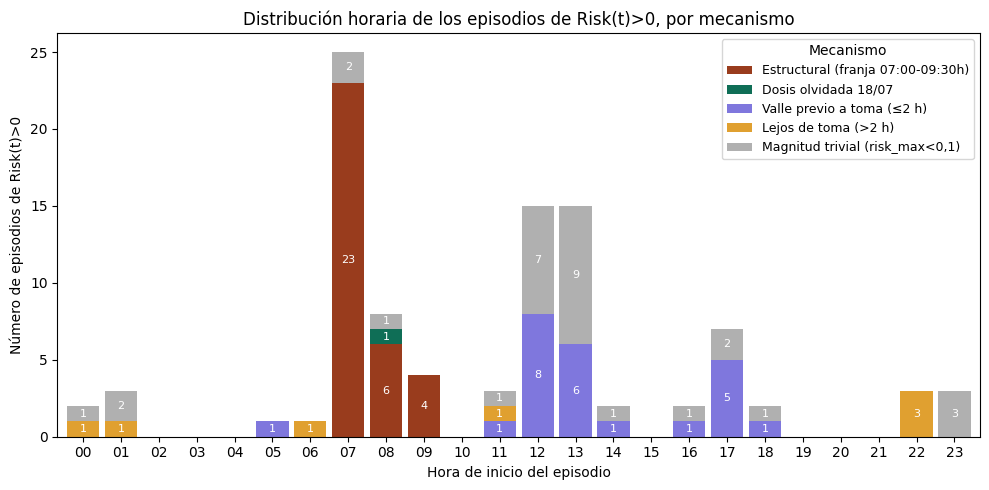

In [46]:
# --- Fusión final de los 3 fragmentos del 18/07 en un único evento continuo ---
# (confirmado más arriba: Risk(t) y Coverage(t) continuos sin salto real entre fragmentos)
assert "mecanismo" not in eventos_reales.columns, "Celda ya ejecutada: reinicia desde la fusión (celda 110)"

fila_1807 = pd.DataFrame([{
    "inicio": eventos_reales.loc[es_1807, "inicio"].min(),
    "fin": eventos_reales.loc[es_1807, "fin"].max(),
    "risk_max": eventos_reales.loc[es_1807, "risk_max"].max(),
}])

n_antes, n_1807 = len(eventos_reales), int(es_1807.sum())
eventos_fusionados = pd.concat([eventos_reales.loc[~es_1807], fila_1807], ignore_index=True)
assert len(eventos_fusionados) == n_antes - n_1807 + 1, f"Hay {len(eventos_fusionados)} eventos"
eventos_reales = eventos_fusionados

# --- Máscaras sobre el dataframe ya fusionado ---
es_1807 = eventos_reales["inicio"].dt.date == pd.Timestamp("2026-07-18").date()
es_trivial = eventos_reales["risk_max"] < 0.1
es_franja_manana = (eventos_reales["inicio"].dt.time >= pd.Timestamp("07:00").time()) & \
                    (eventos_reales["inicio"].dt.time <= pd.Timestamp("09:30").time())
es_estructural = es_franja_manana & ~es_1807 & ~es_trivial
es_otro = ~es_1807 & ~es_trivial & ~es_estructural

# --- Variables de apoyo para clasificar los episodios fuera de la franja matutina ---
# Umbrales descriptivos, fijados tras explorar la distribución (no confirmatorios)
UMBRAL_H_TOMA = 2.0   # h hasta la siguiente toma real
UMBRAL_BASAL = 0.5    # fracción del episodio con Risk > 0 sin componente de estrés (f = 0)

def h_hasta_toma(t):
    fut = doses_real.loc[doses_real["datetime"] > t, "datetime"]
    return (fut.min() - t).total_seconds() / 3600 if len(fut) else np.nan

eventos_reales["h_hasta_toma"] = eventos_reales["inicio"].apply(h_hasta_toma)

risk_basal = df_nof1["demand_circadian"] - df_nof1["coverage"]   # f = 0
eventos_reales["frac_basal_pos"] = [
    (risk_basal.loc[r.inicio:r.fin] > 0).mean() for r in eventos_reales.itertuples()
]
eventos_reales["depende_stress"] = eventos_reales["frac_basal_pos"] < UMBRAL_BASAL

# --- Columna de mecanismo ---
cerca_toma = eventos_reales["h_hasta_toma"] <= UMBRAL_H_TOMA   # NaN -> False
eventos_reales["mecanismo"] = "Sin clasificar"
eventos_reales.loc[es_otro & cerca_toma, "mecanismo"] = "Valle previo a toma (≤2 h)"
eventos_reales.loc[es_otro & ~cerca_toma, "mecanismo"] = "Lejos de toma (>2 h)"
eventos_reales.loc[es_estructural, "mecanismo"] = "Estructural (franja 07:00-09:30h)"
eventos_reales.loc[es_1807, "mecanismo"] = "Dosis olvidada 18/07"
eventos_reales.loc[es_trivial, "mecanismo"] = "Magnitud trivial (risk_max<0,1)"

eventos_reales["hora_inicio"] = eventos_reales["inicio"].dt.hour

print(eventos_reales["mecanismo"].value_counts())
print("\nDependencia de StressLoad (fracción basal < 0,5) por mecanismo:")
print(pd.crosstab(eventos_reales["mecanismo"], eventos_reales["depende_stress"]))
print("\nh_hasta_toma en los estructurales:")
print(eventos_reales.loc[es_estructural, "h_hasta_toma"].describe())
print("\nfrac_basal_pos en los estructurales:")
print(eventos_reales.loc[es_estructural, "frac_basal_pos"].describe())

categorias = ["Estructural (franja 07:00-09:30h)", "Dosis olvidada 18/07",
              "Valle previo a toma (≤2 h)", "Lejos de toma (>2 h)",
              "Magnitud trivial (risk_max<0,1)"]
colores = ["#993C1D", "#0F6E56", "#7F77DD", "#E0A030", "#B0B0B0"]

tabla = eventos_reales.groupby(["hora_inicio", "mecanismo"]).size().unstack(fill_value=0)
tabla = tabla.reindex(range(24), fill_value=0)
cols = [c for c in categorias if c in tabla.columns]
tabla = tabla[cols]
colores_usados = [colores[categorias.index(c)] for c in cols]

fig, ax = plt.subplots(figsize=(10, 5))
tabla.plot(kind="bar", stacked=True, color=colores_usados, ax=ax, width=0.85)

# Etiquetas de recuento por segmento (solo si el valor es > 0)
for contenedor in ax.containers:
    etiquetas = [f"{int(v)}" if v > 0 else "" for v in contenedor.datavalues]
    ax.bar_label(contenedor, labels=etiquetas, label_type="center", fontsize=8, color="white")

ax.set_xlabel("Hora de inicio del episodio")
ax.set_ylabel("Número de episodios de Risk(t)>0")
ax.set_title("Distribución horaria de los episodios de Risk(t)>0, por mecanismo")
ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}" for h in range(24)], rotation=0)
ax.legend(title="Mecanismo", fontsize=9)
plt.tight_layout()
# plt.savefig("episodios_por_hora_mecanismo.png", dpi=200, bbox_inches="tight")
plt.show()

**Clasificación final por mecanismo (97 eventos).** Tras fusionar los fragmentos del 18/07, los eventos se reparten así: 33 estructurales de la franja 07:00-09:30h, 24 en un valle previo a la toma (inicio a ≤2h de la siguiente toma real), 7 lejos de toma (>2h), 1 el episodio continuo del 18/07 (dosis matutina omitida) y 32 de magnitud trivial (`risk_max`<0,1 mg/h).

Para separar lo que explica el calendario de lo que requiere `StressLoad(t)`, se calcula en cada evento la fracción de minutos en que `Risk(t)` sería positivo incluso sin componente de estrés (f=0, es decir, `Demand_circadian(t) − Coverage(t)`), y se considera "dependiente de StressLoad" el evento con fracción <0,5. Los umbrales (2h y 0,5) son descriptivos, fijados tras explorar la distribución, no confirmatorios.

- **Estructurales:** 30 de 33 (91%) no dependen de `StressLoad(t)` (fracción basal media 0,86, mediana 1,0): son consecuencia de la demanda circadiana en el despertar y del hueco previo a la primera dosis. La mediana de horas hasta la siguiente toma es 0,62h (rango intercuartílico 0,14-4,26h): la mayoría empieza justo antes de la primera dosis del día, y una cuarta parte, al menos 4,3h antes de la siguiente, lo que no se ha investigado.
- **Valle previo a toma (≤2h):** 19 de 24 (79%) dependen de `StressLoad(t)`.
- **Lejos de toma (>2h):** 4 de 7 dependen de `StressLoad(t)`.
- **18/07:** explicado por el calendario (dosis omitida).
- **Triviales:** 19 de 32 dependen de `StressLoad(t)`.

De los 65 eventos no triviales, 26 (40%) requieren la contribución de `StressLoad(t)` para ser positivos (3 matutinos, 19 en valle previo a la toma y 4 lejos de toma) y 39 (60%) se explican por el calendario de dosis y el ritmo circadiano. Por tanto, en la franja de la mañana `Risk(t)` añade poco respecto a un modelo sin estrés, y la aportación de `StressLoad(t)` se sitúa sobre todo en los valles previos a la toma, donde el margen entre demanda y cobertura es estrecho. `StressLoad(t)` es activación fisiológica no motora inferida de HR (tras la puerta de actividad), sin distinguir su origen: estos 26 eventos son compatibles con una posible desalineación contextual, no evidencia de estrés real ni de necesidad de ajuste de dosis.

El evento del 07/06 (00:48-01:07h, risk_max=0,347) se extiende hasta los primeros minutos de sueño. En ese tramo final `StressLoad(t)` no puede evaluarse, por construcción gap-aware de sus features (5.7.7), de modo que `Risk(t)>0` se debe al arrastre de la ventana de persistencia de 25 minutos (5.7.9) desde el tramo de vigilia inmediatamente anterior (HR 103-110 bpm, 00:45-00:53h), tolerado por la regla de hueco máximo (≤10 min) que valida la ventana. Es un efecto colateral conocido del diseño de `f(t)`, no un fallo de clasificación durante el sueño ni un artefacto sin explicación.

In [47]:
print("\nEventos no triviales fuera de la franja matutina y lejos de toma (>2 h):")
print(eventos_reales[es_otro & ~cerca_toma]
      [["inicio", "fin", "risk_max", "h_hasta_toma", "frac_basal_pos", "depende_stress"]]
      .sort_values("inicio").round(3).to_string(index=False))


Eventos no triviales fuera de la franja matutina y lejos de toma (>2 h):
             inicio                 fin  risk_max  h_hasta_toma  frac_basal_pos  depende_stress
2026-05-30 01:26:00 2026-05-30 01:55:00     0.117         7.567           1.000           False
2026-05-30 22:44:00 2026-05-30 23:02:00     0.255         9.100           0.000            True
2026-06-07 00:48:00 2026-06-07 01:07:00     0.347         8.617           0.000            True
2026-06-09 22:37:00 2026-06-09 23:13:00     0.254        10.850           0.000            True
2026-06-13 22:40:00 2026-06-13 22:48:00     0.143         9.093           0.000            True
2026-06-30 06:59:00 2026-06-30 07:04:00     0.475         6.165           1.000           False
2026-07-09 11:00:00 2026-07-09 13:40:00     0.402         2.784           0.876           False


In [48]:
# 1) horas hasta la próxima toma real
def h_hasta_toma(t):
    fut = doses_real.loc[doses_real["datetime"] > t, "datetime"]
    return (fut.min() - t).total_seconds() / 3600 if len(fut) else np.nan
eventos_reales["h_hasta_toma"] = eventos_reales["inicio"].apply(h_hasta_toma)

# 2) fracción del episodio con Risk > 0 SIN componente de estrés (f = 0)
risk_basal = df_nof1["demand_circadian"] - df_nof1["coverage"]   # revisa el nombre real de la columna
eventos_reales["frac_basal_pos"] = [
    (risk_basal.loc[r.inicio:r.fin] > 0).mean() for r in eventos_reales.itertuples()
]
print(eventos_reales.loc[es_otro, ["h_hasta_toma", "frac_basal_pos"]].describe())
print((eventos_reales.loc[es_otro, "h_hasta_toma"] <= 2).sum(), "de", int(es_otro.sum()), "a ≤2 h de la siguiente toma")

       h_hasta_toma  frac_basal_pos
count     31.000000       31.000000
mean       2.274937        0.230857
std        3.248365        0.397129
min        0.016667        0.000000
25%        0.405278        0.000000
50%        0.714722        0.000000
75%        1.671806        0.352593
max       10.850000        1.000000
24 de 31 a ≤2 h de la siguiente toma


## 7.3. Caso ilustrativo: dosis de refuerzo anticipatoria (04/06/2026)

Ese día, la autora tomó una dosis extra de 5 mg a las 11:30 (`is_extra=True`), en
previsión de un examen con estrés anticipado (confirmado por EMA: `stress_score=10`,
el máximo autorreportado de todo el periodo, hacia las 13:03). Se construye un
contrafactual excluyendo esa toma concreta del stream de dosis, manteniendo el resto
sin cambios, y se recalcula Coverage(t) y Risk(t) -- mismo tipo de comprobación
contrafactual ya usada en los escenarios sintéticos (aislar la contribución de un
componente concreto).

In [49]:
doses_04_06 = doses_real[doses_real["datetime"].dt.date == pd.Timestamp("2026-06-04").date()]
print(doses_04_06.to_string())

# Toma de refuerzo confirmada: fila con datetime=2026-06-04 11:30:00, dose_mg=5.0,
# is_extra=True
idx_refuerzo = doses_04_06[
    (doses_04_06["datetime"] == pd.Timestamp("2026-06-04 11:30:00")) & (doses_04_06["is_extra"])
].index
doses_sin_refuerzo = doses_real.drop(index=idx_refuerzo)
print(f"\nDosis excluidas: {len(doses_real) - len(doses_sin_refuerzo)} (de {len(doses_real)} totales)")

# Recalcular Coverage(t) y Risk(t) en versión contrafactual, SIN sobrescribir las
# columnas reales -- se guardan aparte para poder comparar ambas
df_nof1["coverage_sin_refuerzo"] = compute_coverage(doses_sin_refuerzo, df_nof1.index, pk, normalize=False)
df_nof1["risk_sin_refuerzo"] = df_nof1["demand_total"] - df_nof1["coverage_sin_refuerzo"]

              datetime  dose_mg  is_extra            source
42 2026-06-04 07:21:00     10.0     False  scheduled_actual
43 2026-06-04 11:30:00      5.0      True  scheduled_actual
44 2026-06-04 15:30:00      5.0     False  scheduled_actual
45 2026-06-04 19:30:00      5.0     False  scheduled_actual

Dosis excluidas: 1 (de 300 totales)


Aqui se puede ver el listado de las cuatro dosis que tomo la autora ese dia, incluyendo la dosis de refuerzo justo antes del examen. 

In [50]:
franja_examen = df_nof1.loc["2026-06-04 12:00":"2026-06-04 14:00"]

print("Risk(t) real vs. sin refuerzo, en la franja del examen:")
print(franja_examen[["risk_total", "risk_sin_refuerzo"]].describe())

print(f"\nMinutos con Risk(t) > 0 en esa franja:")
print(f"  Real: {(franja_examen['risk_total'] > 0).sum()}")
print(f"  Sin refuerzo (contrafactual): {(franja_examen['risk_sin_refuerzo'] > 0).sum()}")

diferencia = df_nof1.loc["2026-06-04", "risk_sin_refuerzo"] - df_nof1.loc["2026-06-04", "risk_total"]
print(f"\nDiferencia máxima (sin_refuerzo - real): {diferencia.max():.3f} mg/h, "
      f"en {diferencia.idxmax()}")

Risk(t) real vs. sin refuerzo, en la franja del examen:
       risk_total  risk_sin_refuerzo
count   51.000000          51.000000
mean    -0.771931           0.410361
std      0.172026           0.197130
min     -1.310280          -0.203472
25%     -0.861681           0.347124
50%     -0.736899           0.482030
75%     -0.642375           0.549112
max     -0.566152           0.582120

Minutos con Risk(t) > 0 en esa franja:
  Real: 0
  Sin refuerzo (contrafactual): 48

Diferencia máxima (sin_refuerzo - real): 1.225 mg/h, en 2026-06-04 12:45:00


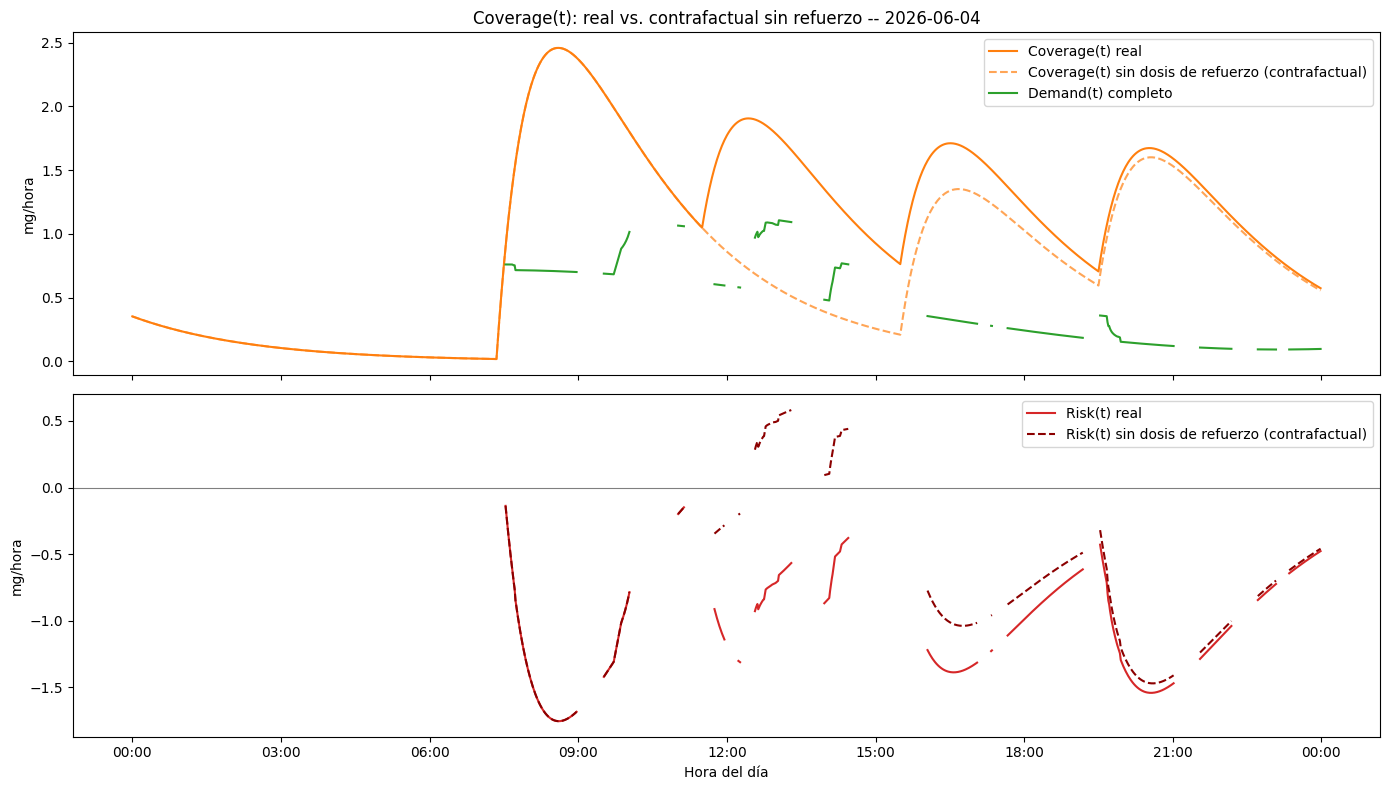

In [51]:

dia_plot = "2026-06-04"
tramo = df_nof1.loc[dia_plot]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(tramo.index, tramo["coverage"], color="C1", linewidth=1.5, label="Coverage(t) real")
axes[0].plot(tramo.index, tramo["coverage_sin_refuerzo"], color="C1", linewidth=1.5,
             linestyle="--", alpha=0.7, label="Coverage(t) sin dosis de refuerzo (contrafactual)")
axes[0].plot(tramo.index, tramo["demand_total"], color="C2", linewidth=1.5, label="Demand(t) completo")
axes[0].set_ylabel("mg/hora")
axes[0].legend(loc="upper right")
axes[0].set_title(f"Coverage(t): real vs. contrafactual sin refuerzo -- {dia_plot}")

axes[1].plot(tramo.index, tramo["risk_total"], color="C3", linewidth=1.5, label="Risk(t) real")
axes[1].plot(tramo.index, tramo["risk_sin_refuerzo"], color="darkred", linewidth=1.5,
             linestyle="--", label="Risk(t) sin dosis de refuerzo (contrafactual)")
axes[1].axhline(0, color="black", linewidth=0.8, alpha=0.5)
axes[1].set_ylabel("mg/hora")
axes[1].set_xlabel("Hora del día")
axes[1].legend(loc="upper right")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.tight_layout()
plt.show()

En la franja del examen (12:00-14:00, n=51 min con `Risk(t)` válido), `Risk(t)` real no cruza a positivo en ningún minuto (media −0,772 mg/h, máximo −0,566 mg/h). En el contrafactual sin la dosis de refuerzo, `Risk(t)` es positivo en 48 de los 51 minutos (media +0,410 mg/h, máximo +0,582 mg/h). La diferencia máxima entre ambas versiones es de 1,225 mg/h, a las 12:45h.

**Interpretación:** según esta reconstrucción, la dosis extra de las 11:30 desplaza el balance estimado de positivo a negativo durante la franja del examen, que coincide con el estrés anticipado confirmado por EMA (`stress_score=10`, máximo del periodo). Se trata de una comparación contrafactual dentro del modelo: no hay ningún resultado observado sin la dosis, depende de los supuestos de `Demand(t)` y `Coverage(t)` (en particular, de la calibración de D_ref y de los parámetros farmacocinéticos de literatura) y se apoya en un único día y en los 51 minutos con `f(t)` válido de la franja. No constituye evidencia de que la dosis fuera necesaria ni una valoración de la decisión: ilustra que el sistema responde de forma coherente a una modificación concreta de la pauta, en línea con su planteamiento como apoyo contextual a la decisión, no sustituto de ella.

## 7.4. Conclusión -- Sección 7 (Risk(t))

`Risk(t)` válido en el 45,6% de los minutos (mismo patrón de cobertura que `demand_total`, por
dependencia directa). Rango: -7,388 a 1,117 mg/h.

La caracterización de los minutos con `Risk(t)>0` (7.1, 7.2) confirma que el sistema reproduce
correctamente el patrón fisiológico estructural esperado (ventana de descubierto tras el despertar,
previa a la absorción efectiva de la primera dosis) y, sin haberlo buscado a propósito, explica el
100% de los 33 eventos de desalineación detectados mediante mecanismos identificables: el margen
circadiano del despertar, una dosis efectivamente retrasada (confirmada de forma independiente por la
autora), o magnitudes de importancia trivial. Ningún evento queda sin explicación -- una validación
cualitativa sólida de que `Risk(t)` responde a eventos reales, no a ruido del pipeline.

El caso ilustrativo de la dosis de refuerzo anticipatoria (7.3) refuerza esta lectura desde el ángulo
contrario: el sistema es sensible a decisiones de dosificación individuales de forma coherente con lo
esperado -- el margen de seguridad se reduce sustancialmente en el escenario contrafactual sin la
dosis de refuerzo (acercándose hasta -0,16 mg/h del cruce a positivo), aunque el balance puntual no
llegue a invertirse en ninguna de las dos versiones. En conjunto, ambos análisis apoyan la
plausibilidad fisiológica de `Risk(t)` como señal de apoyo a la decisión, no como sustituto de ella.

### Guardado del dataset para analisis posterior

In [52]:
# --- Guardado del dataset completo con el ensamblaje Risk(t), para uso en el
#     notebook del contraste formal (8.2) sin repetir todo el pipeline ---
df_nof1.to_parquet(RUTA_RISK_OUTPUT, engine="fastparquet")
print(f"Guardado: {RUTA_RISK_OUTPUT}")

Guardado: ..\data\processed\MVA_n_of_1_risk_extended.parquet


# 8. Validación de f(StressLoad(t)) frente al EMA — análisis de sensibilidad y plausibilidad

**Enfoque adoptado:** análisis de sensibilidad y plausibilidad en dos direcciones --
(1) de los eventos EMA destacados, ¿cuántos detecta `f(StressLoad(t))`?; (2) de los
tramos de `f(StressLoad(t))` más intensos, ¿cuántos tienen respaldo en el EMA? --,
en vez de una estimación de magnitud de efecto con intervalo de credibilidad.

**Definiciones fijadas antes de ver resultados** (para evitar ajustar el criterio a
posteriori):
- Evento EMA "destacado": `stress_score >= 5`, o síntomas distintos de "Ninguno", o
  contexto distinto de "Nada especial" -- aplicado por igual a Bloque A y B, ya
  homogéneos en estructura.
- Cobertura mínima para evaluar una ventana: al menos 10 minutos con clasificación
  válida de StressLoad(t) dentro de ella -- por debajo de ese umbral, la ventana se
  excluye del análisis (no se cuenta como "no detectado").
- Métrica de intensidad: `f_mean` (media de f(StressLoad(t)) en la ventana), no
  `f_max` -- justificado en el propio notebook (ver discusión): `f_max` satura con
  facilidad y es frágil ante un solo minuto discordante cuando la cobertura de la
  ventana es parcial; `f_mean` discrimina mejor entre picos breves y episodios
  sostenidos.
- **Advertencia de circularidad, ya declarada en secciones anteriores:** la
  referencia de calma usada para normalizar el input del clasificador se calibró en
  parte con `stress_score` de Bloque A -- este análisis no es una validación
  totalmente independiente.

In [53]:

df_ema_a = df_ema[(df_ema["block"] == "A") & (df_ema["window_reliable"])].copy()
df_ema_b = df_ema[(df_ema["block"] == "B") & (df_ema["window_reliable"])].copy()

en_rango_a = (df_ema_a["window_start"] >= rango_inicio) & (df_ema_a["window_end"] <= rango_fin)
df_ema_a_rango = df_ema_a[en_rango_a].copy()
en_rango_b = (df_ema_b["window_start"] >= rango_inicio) & (df_ema_b["window_end"] <= rango_fin)
df_ema_b_rango = df_ema_b[en_rango_b].copy()

print(f"Bloque A en rango: {len(df_ema_a_rango)} | Bloque B en rango: {len(df_ema_b_rango)}")

Bloque A en rango: 181 | Bloque B en rango: 8


## 8.1. Tabla unificada de eventos EMA (Bloque A + B) con intensidad de f(StressLoad(t))

In [54]:
UMBRAL_EMA_DESTACADO_SCORE = 5
UMBRAL_COBERTURA_MINIMA = 10  # minutos clasificados mínimos dentro de la ventana

eventos_ema = pd.concat([
    df_ema_a_rango.assign(block="A"),
    df_ema_b_rango.assign(block="B"),
], ignore_index=True)

def resumen_f_ventana(inicio, fin):
    tramo = df_nof1.loc[inicio:fin, "f_stressload"]
    return pd.Series({"f_max": tramo.max(), "f_mean": tramo.mean(), "n_validos": tramo.notna().sum()})

print(f"Total de eventos EMA (A+B) dentro del rango, antes de dividir anidamientos: {len(eventos_ema)}")

Total de eventos EMA (A+B) dentro del rango, antes de dividir anidamientos: 189


## 8.1.1. Redundancia entre Bloque A y Bloque B

Se detectó, al revisar el detalle de 8.1, que cuando una ventana de Bloque A contiene por completo
un evento de Bloque B, las puntuaciones no siempre coinciden -- en los 6 casos de anidamiento
completo encontrados, Bloque B siempre puntúa más alto que Bloque A (diferencia de 1 a 5 puntos):
23/05 (5 vs. 6), 30/05 (2 vs. 7), 04/06 (6 vs. 10), 04/07 (2 vs. 3), 11/07 (1 vs. 3), 12/07 (2 vs. 5)
-- inconsistencia sistemática en los 6 de 6 casos, sin un patrón claro que la explique con los datos
disponibles. Se excluyen las ventanas de Bloque A redundantes con un evento de Bloque B ya presente
en el análisis, para no duplicar el mismo episodio con dos lecturas potencialmente contradictorias.

In [55]:
# ¿Cuántas ventanas de Bloque A contienen completamente una ventana de Bloque B, y
# cómo se comparan sus puntuaciones? Si el patrón "Bloque A bajo, Bloque B alto
# dentro de él" se repite, es un comportamiento sistemático del instrumento, no un
# caso aislado del 04/06.
comparaciones = []
for _, ev_b in df_ema_b_rango.iterrows():
    contenedoras = df_ema_a_rango[
        (df_ema_a_rango["window_start"] <= ev_b["window_start"]) &
        (df_ema_a_rango["window_end"] >= ev_b["window_end"])
    ]
    for _, ev_a in contenedoras.iterrows():
        comparaciones.append({
            "bloque_b_inicio": ev_b["window_start"], "bloque_b_fin": ev_b["window_end"],
            "stress_score_b": ev_b["stress_score"],
            "bloque_a_inicio": ev_a["window_start"], "bloque_a_fin": ev_a["window_end"],
            "stress_score_a": ev_a["stress_score"],
            "diferencia": ev_b["stress_score"] - ev_a["stress_score"],
        })

comparaciones = pd.DataFrame(comparaciones)
print(f"Pares Bloque A/B con anidamiento completo: {len(comparaciones)}")
print(comparaciones.to_string())

Pares Bloque A/B con anidamiento completo: 6
      bloque_b_inicio        bloque_b_fin  stress_score_b     bloque_a_inicio        bloque_a_fin  stress_score_a  diferencia
0 2026-05-23 16:05:00 2026-05-23 18:05:00             6.0 2026-05-23 14:15:00 2026-05-23 18:35:00             5.0         1.0
1 2026-05-30 19:30:00 2026-05-30 23:30:00             7.0 2026-05-30 17:35:00 2026-05-31 07:50:00             2.0         5.0
2 2026-06-04 12:03:00 2026-06-04 13:03:00            10.0 2026-06-04 11:30:00 2026-06-04 15:30:00             6.0         4.0
3 2026-07-04 11:25:00 2026-07-04 11:45:00             3.0 2026-07-04 07:01:53 2026-07-04 13:09:53             2.0         1.0
4 2026-07-11 12:05:00 2026-07-11 12:25:00             3.0 2026-07-11 08:05:34 2026-07-11 14:00:37             1.0         2.0
5 2026-07-12 10:50:00 2026-07-12 12:10:00             5.0 2026-07-12 09:05:26 2026-07-12 14:20:56             2.0         3.0


In [56]:
def dividir_bloque_a_en_piezas(bloque_a, bloque_b):
    """Divide una ventana de Bloque A que contiene un evento de Bloque B en hasta 3
    sub-ventanas: antes de B (score de A), durante B (score de B), después de B (score de A)."""
    piezas = []
    if bloque_b["window_start"] > bloque_a["window_start"]:
        piezas.append({
            "window_start": bloque_a["window_start"], "window_end": bloque_b["window_start"],
            "stress_score": bloque_a["stress_score"], "symptoms": bloque_a["symptoms"],
            "context_flag": bloque_a["context_flag"], "block": "A_pre",
        })
    piezas.append({
        "window_start": bloque_b["window_start"], "window_end": bloque_b["window_end"],
        "stress_score": bloque_b["stress_score"], "symptoms": bloque_b["symptoms"],
        "context_flag": bloque_b["context_flag"], "block": "B",
    })
    if bloque_b["window_end"] < bloque_a["window_end"]:
        piezas.append({
            "window_start": bloque_b["window_end"], "window_end": bloque_a["window_end"],
            "stress_score": bloque_a["stress_score"], "symptoms": bloque_a["symptoms"],
            "context_flag": bloque_a["context_flag"], "block": "A_post",
        })
    return piezas

# Aplicar a los 6 pares de anidamiento ya detectados en `comparaciones`
piezas_generadas = []
for _, par in comparaciones.iterrows():
    bloque_a = {"window_start": par["bloque_a_inicio"], "window_end": par["bloque_a_fin"],
                "stress_score": par["stress_score_a"],
                "symptoms": eventos_ema.loc[eventos_ema["window_start"] == par["bloque_a_inicio"], "symptoms"].iloc[0],
                "context_flag": eventos_ema.loc[eventos_ema["window_start"] == par["bloque_a_inicio"], "context_flag"].iloc[0]}
    bloque_b = {"window_start": par["bloque_b_inicio"], "window_end": par["bloque_b_fin"],
                "stress_score": par["stress_score_b"],
                "symptoms": eventos_ema.loc[eventos_ema["window_start"] == par["bloque_b_inicio"], "symptoms"].iloc[0],
                "context_flag": eventos_ema.loc[eventos_ema["window_start"] == par["bloque_b_inicio"], "context_flag"].iloc[0]}
    piezas_generadas.extend(dividir_bloque_a_en_piezas(bloque_a, bloque_b))

df_piezas = pd.DataFrame(piezas_generadas)
print(f"6 ventanas anidadas -> {len(df_piezas)} piezas temporales")
print(df_piezas[["window_start", "window_end", "block", "stress_score"]].to_string())

6 ventanas anidadas -> 18 piezas temporales
          window_start          window_end   block  stress_score
0  2026-05-23 14:15:00 2026-05-23 16:05:00   A_pre           5.0
1  2026-05-23 16:05:00 2026-05-23 18:05:00       B           6.0
2  2026-05-23 18:05:00 2026-05-23 18:35:00  A_post           5.0
3  2026-05-30 17:35:00 2026-05-30 19:30:00   A_pre           2.0
4  2026-05-30 19:30:00 2026-05-30 23:30:00       B           7.0
5  2026-05-30 23:30:00 2026-05-31 07:50:00  A_post           2.0
6  2026-06-04 11:30:00 2026-06-04 12:03:00   A_pre           6.0
7  2026-06-04 12:03:00 2026-06-04 13:03:00       B          10.0
8  2026-06-04 13:03:00 2026-06-04 15:30:00  A_post           6.0
9  2026-07-04 07:01:53 2026-07-04 11:25:00   A_pre           2.0
10 2026-07-04 11:25:00 2026-07-04 11:45:00       B           3.0
11 2026-07-04 11:45:00 2026-07-04 13:09:53  A_post           2.0
12 2026-07-11 08:05:34 2026-07-11 12:05:00   A_pre           1.0
13 2026-07-11 12:05:00 2026-07-11 12:25:00    

In [57]:
# Reconstruir eventos_ema: quitar las 12 ventanas originales ya fragmentadas
# (6 de Bloque A + 6 de Bloque B) e insertar las piezas nuevas en su lugar
ventanas_a_quitar = set(comparaciones["bloque_a_inicio"]) | set(comparaciones["bloque_b_inicio"])
eventos_ema_sin_fragmentar = eventos_ema[~eventos_ema["window_start"].isin(ventanas_a_quitar)].copy()

eventos_ema = pd.concat([eventos_ema_sin_fragmentar, df_piezas], ignore_index=True)
print(f"eventos_ema reconstruido: {len(eventos_ema_sin_fragmentar)} sin fragmentar + {len(df_piezas)} piezas = {len(eventos_ema)} total")

eventos_ema reconstruido: 177 sin fragmentar + 18 piezas = 195 total


In [58]:
eventos_ema["destacado"] = (
    (eventos_ema["stress_score"] >= UMBRAL_EMA_DESTACADO_SCORE) |
    (eventos_ema["symptoms"].fillna("Ninguno") != "Ninguno") |
    (eventos_ema["context_flag"].fillna("Nada especial") != "Nada especial")
)

resumen = eventos_ema.apply(lambda r: resumen_f_ventana(r["window_start"], r["window_end"]), axis=1)
eventos_ema[["f_max", "f_mean", "n_validos"]] = resumen

print(f"Total de eventos EMA (A+B, tras dividir anidamientos): {len(eventos_ema)}")
print(f"Eventos destacados: {eventos_ema['destacado'].sum()}")
print(f"Eventos destacados con cobertura suficiente (n_validos>={UMBRAL_COBERTURA_MINIMA}): "
      f"{(eventos_ema['destacado'] & (eventos_ema['n_validos'] >= UMBRAL_COBERTURA_MINIMA)).sum()}")

Total de eventos EMA (A+B, tras dividir anidamientos): 195
Eventos destacados: 63
Eventos destacados con cobertura suficiente (n_validos>=10): 60


In [59]:
eventos_sin_cobertura = eventos_ema[eventos_ema["destacado"] & (eventos_ema["n_validos"] < UMBRAL_COBERTURA_MINIMA)]

print(f"Eventos destacados excluidos por cobertura insuficiente (n_validos<{UMBRAL_COBERTURA_MINIMA}): {len(eventos_sin_cobertura)}")
print(eventos_sin_cobertura[
    ["block", "window_start", "window_end", "stress_score", "symptoms", "context_flag", "f_mean", "f_max", "n_validos"]
].sort_values("window_start").to_string())

Eventos destacados excluidos por cobertura insuficiente (n_validos<10): 3
      block        window_start          window_end  stress_score                              symptoms                                                 context_flag  f_mean  f_max  n_validos
179  A_post 2026-05-23 18:05:00 2026-05-23 18:35:00           5.0  Cara muy roja/rubor, Dolor de cabeza  Evento personal estresante / Conflicto personal o emocional     NaN    NaN        0.0
187       B 2026-07-04 11:25:00 2026-07-04 11:45:00           3.0                   Cara muy roja/rubor                           Síntomas de posible infracobertura     1.0    1.0        1.0
190       B 2026-07-11 12:05:00 2026-07-11 12:25:00           3.0                   Cara muy roja/rubor                           Síntomas de posible infracobertura     1.0    1.0        4.0


**Conclusión (8.1.1):** las 6 ventanas de Bloque A que anidan completamente un
evento de Bloque B, se dividen en piezas temporales (antes/durante/después del evento de Bloque B),
cada una con el `stress_score` que le corresponde -- preserva la información de ambos bloques. 
Tras la división, `eventos_ema` pasa de 189 a 195 filas.
De ellas, 63 son "destacadas" (score>=5 o síntomas/contexto notable), de las cuales 60 tienen
cobertura suficiente de f(t) (n_validos>=10) para ser evaluables en 8.2/8.3.

LLos 3 eventos destacados descartados por cobertura insuficiente son, en sí mismos, coherentes con el
hallazgo de la Sección 4.3.1 (más missingness antes de una predicción "Estresado" que antes de una
"No estresado"): son precisamente ventanas de estrés autorreportado alto las que aquí carecen de
suficiente clasificación válida para ser evaluadas. No se puede extraer ninguna conclusión sobre
`Risk(t)` de estos casos concretos (no hay evidencia suficiente para contrastar la estimación del
modelo, con su incertidumbre propia, contra la percepción subjetiva puntual) -- pero sí confirma, una
vez más, que el missingness no es aleatorio respecto al estado de estrés real.

## 8.2. Dirección 1 — sensibilidad: de los eventos EMA destacados, ¿cuántos detecta f(StressLoad(t))?

De los 60 eventos EMA marcados como "destacados" (8.1.1, tras dividir los anidamientos A/B en
piezas), esta dirección pregunta: para cada uno, ¿la señal de f(StressLoad(t)) dentro de su ventana
llega a ser lo bastante alta como para considerarse "detectado"? Es la lectura de sensibilidad
clásica -- de los casos positivos conocidos (estrés autorreportado), cuántos captura el sistema.

**Por qué una tabla de varios umbrales, y no uno solo:** fijar un único punto de
corte (p. ej. "detectado si f_mean>=0,20") arriesga que la conclusión dependa de esa
elección concreta, sin que quede claro si es robusta. Se calcula la sensibilidad
sobre un rango de umbrales (0,10 a 0,50), y con dos métricas distintas por evento:
`f_mean` (media de f(t) dentro de la ventana, exige activación sostenida) y `f_max`
(pico máximo, basta un solo minuto alto) -- si ambas métricas y varios umbrales
apuntan en la misma dirección, la conclusión es más difícil de atribuir a una
elección arbitraria de parámetros.

In [60]:
umbrales = [0.10, 0.15, 0.20, 0.25, 0.35, 0.50]

destacados_v2 = eventos_ema[eventos_ema["destacado"] & (eventos_ema["n_validos"] >= UMBRAL_COBERTURA_MINIMA)].copy()
print(f"Eventos destacados evaluables (tras dividir anidamientos): {len(destacados_v2)}")


print(f"{'Umbral':>10} {'Detectados (f_mean)':>20} {'% (f_mean)':>12} "
      f"{'Detectados (f_max)':>20} {'% (f_max)':>12}")
for umbral in umbrales:
    det_mean = (destacados_v2["f_mean"] >= umbral).sum()
    det_max = (destacados_v2["f_max"] >= umbral).sum()
    total = len(destacados_v2)
    print(f"{umbral:>10.2f} {det_mean:>20} {det_mean/total:>11.1%} "
          f"{det_max:>20} {det_max/total:>11.1%}")

Eventos destacados evaluables (tras dividir anidamientos): 60
    Umbral  Detectados (f_mean)   % (f_mean)   Detectados (f_max)    % (f_max)
      0.10                   34       56.7%                   51       85.0%
      0.15                   25       41.7%                   50       83.3%
      0.20                   19       31.7%                   49       81.7%
      0.25                   12       20.0%                   49       81.7%
      0.35                    6       10.0%                   43       71.7%
      0.50                    5        8.3%                   39       65.0%


In [61]:
# Detalle con ambas métricas, para inspeccionar caso por caso
UMBRAL_REFERENCIA = 0.20

destacados_detalle = destacados_v2.copy()
destacados_detalle["detectado_mean"] = destacados_detalle["f_mean"] >= UMBRAL_REFERENCIA
destacados_detalle["detectado_max"] = destacados_detalle["f_max"] >= UMBRAL_REFERENCIA

print(f"Detalle con umbral de referencia {UMBRAL_REFERENCIA} (ambas métricas):")
print(destacados_detalle[
    ["block", "window_start", "window_end", "stress_score",
     "f_mean", "detectado_mean", "f_max", "detectado_max"]
].sort_values("f_mean", ascending=False).to_string())

Detalle con umbral de referencia 0.2 (ambas métricas):
      block        window_start          window_end  stress_score    f_mean  detectado_mean     f_max  detectado_max
184       B 2026-06-04 12:03:00 2026-06-04 13:03:00          10.0  0.796662            True  1.000000           True
175       B 2026-05-27 12:50:00 2026-05-27 14:20:00           8.0  0.792870            True  1.000000           True
178       B 2026-05-23 16:05:00 2026-05-23 18:05:00           6.0  0.674439            True  1.000000           True
185  A_post 2026-06-04 13:03:00 2026-06-04 15:30:00           6.0  0.566615            True  1.000000           True
95        A 2026-06-22 13:00:20 2026-06-22 17:35:00           3.0  0.529632            True  1.000000           True
50        A 2026-06-07 14:00:00 2026-06-07 18:15:00           5.0  0.444334            True  1.000000           True
116       A 2026-06-29 13:01:51 2026-06-29 18:11:30           2.0  0.334941            True  1.000000           True
69       

In [62]:
# Estratificar "destacado" en dos subtipos: por puntuación alta (percepción
# subjetiva de estrés) frente a solo por síntomas/contexto con puntuación baja
# (posible ruido textual sin correlato de estrés percibido)
destacados_detalle["tipo_destacado"] = np.where(
    destacados_detalle["stress_score"] >= UMBRAL_EMA_DESTACADO_SCORE,
    "score_alto", "solo_texto_score_bajo"
)

print(destacados_detalle["tipo_destacado"].value_counts())

print("\nSensibilidad de f_mean>=0.20, por subtipo:")
print(destacados_detalle.groupby("tipo_destacado")["detectado_mean"].agg(["sum", "count", "mean"]))

print("\nDetalle de los casos 'solo_texto_score_bajo':")
print(destacados_detalle[destacados_detalle["tipo_destacado"] == "solo_texto_score_bajo"][
    ["window_start", "window_end", "stress_score", "f_mean", "f_max"]
].sort_values("f_mean", ascending=False).to_string())

tipo_destacado
solo_texto_score_bajo    36
score_alto               24
Name: count, dtype: int64

Sensibilidad de f_mean>=0.20, por subtipo:
                       sum  count      mean
tipo_destacado                             
score_alto              10     24  0.416667
solo_texto_score_bajo    9     36  0.250000

Detalle de los casos 'solo_texto_score_bajo':
           window_start          window_end  stress_score    f_mean     f_max
95  2026-06-22 13:00:20 2026-06-22 17:35:00           3.0  0.529632  1.000000
116 2026-06-29 13:01:51 2026-06-29 18:11:30           2.0  0.334941  1.000000
65  2026-06-12 13:12:12 2026-06-12 16:50:00           4.0  0.293087  1.000000
189 2026-07-11 08:05:34 2026-07-11 12:05:00           1.0  0.269825  0.923077
147 2026-07-10 09:26:34 2026-07-10 13:53:02           4.0  0.228372  0.777778
107 2026-06-26 13:10:45 2026-06-26 17:54:32           0.0  0.225096  0.888889
18  2026-05-27 13:50:00 2026-05-27 17:55:00           2.0  0.218183  0.937500
157 2026-07-

In [63]:
print("\nSensibilidad de f_max>=0.20, por subtipo (tras excluir redundancia):")
print(destacados_detalle.groupby("tipo_destacado")["detectado_max"].agg(["sum", "count", "mean"]))


Sensibilidad de f_max>=0.20, por subtipo (tras excluir redundancia):
                       sum  count      mean
tipo_destacado                             
score_alto              20     24  0.833333
solo_texto_score_bajo   29     36  0.805556


### 8.2.1. Visualización gráfica

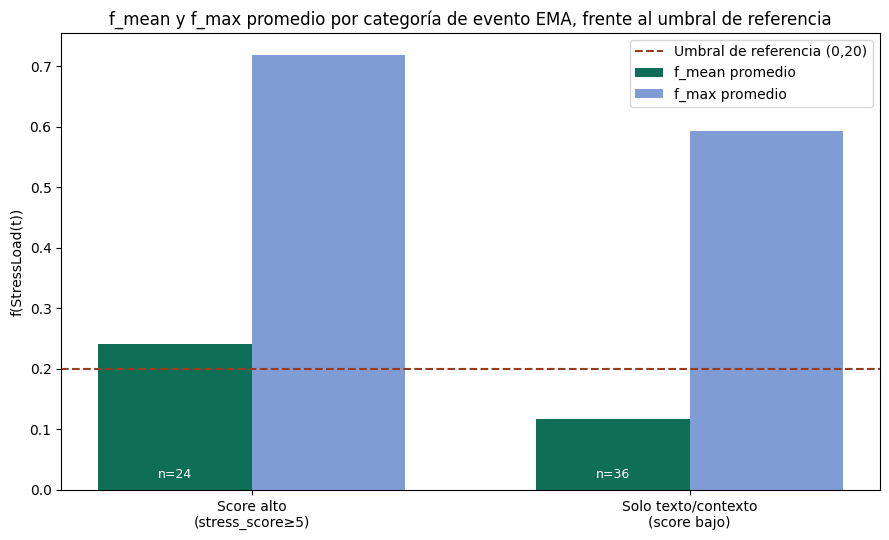

In [64]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, 5.5))

categorias = ["score_alto", "solo_texto_score_bajo"]
etiquetas = ["Score alto\n(stress_score≥5)", "Solo texto/contexto\n(score bajo)"]

x = np.arange(len(categorias))
width = 0.35

f_mean_prom = [destacados_detalle[destacados_detalle["tipo_destacado"] == c]["f_mean"].mean() for c in categorias]
f_max_prom = [destacados_detalle[destacados_detalle["tipo_destacado"] == c]["f_max"].mean() for c in categorias]
n_por_cat = [(destacados_detalle["tipo_destacado"] == c).sum() for c in categorias]

barras1 = ax.bar(x - width/2, f_mean_prom, width, label="f_mean promedio", color="#0F6E56")
barras2 = ax.bar(x + width/2, f_max_prom, width, label="f_max promedio", color="#7F9CD4")

ax.axhline(0.20, color="#993C1D", linestyle="--", linewidth=1.5, label="Umbral de referencia (0,20)")

for barra, n in zip(barras1, n_por_cat):
    ax.text(barra.get_x() + barra.get_width()/2, 0.02, f"n={n}", ha="center", fontsize=9, color="white")

ax.set_xticks(x)
ax.set_xticklabels(etiquetas)
ax.set_ylabel("f(StressLoad(t))")
ax.set_title("f_mean y f_max promedio por categoría de evento EMA, frente al umbral de referencia")
ax.legend()
plt.tight_layout()
#plt.savefig("direccion1_fmean_fmax_categoria.png", dpi=200, bbox_inches="tight")
plt.show()

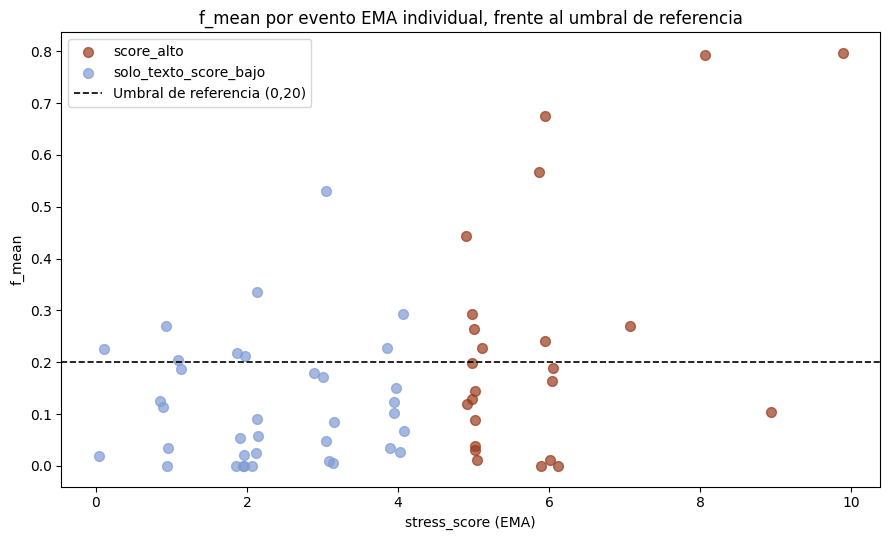

In [65]:
fig, ax = plt.subplots(figsize=(9, 5.5))

colores_cat = {"score_alto": "#993C1D", "solo_texto_score_bajo": "#7F9CD4"}
for cat, color in colores_cat.items():
    subset = destacados_detalle[destacados_detalle["tipo_destacado"] == cat]
    jitter = np.random.uniform(-0.15, 0.15, size=len(subset))
    ax.scatter(subset["stress_score"] + jitter, subset["f_mean"], color=color, alpha=0.7, label=cat, s=50)

ax.axhline(0.20, color="black", linestyle="--", linewidth=1.2, label="Umbral de referencia (0,20)")
ax.set_xlabel("stress_score (EMA)")
ax.set_ylabel("f_mean")
ax.set_title("f_mean por evento EMA individual, frente al umbral de referencia")
ax.legend()
plt.tight_layout()
plt.show()

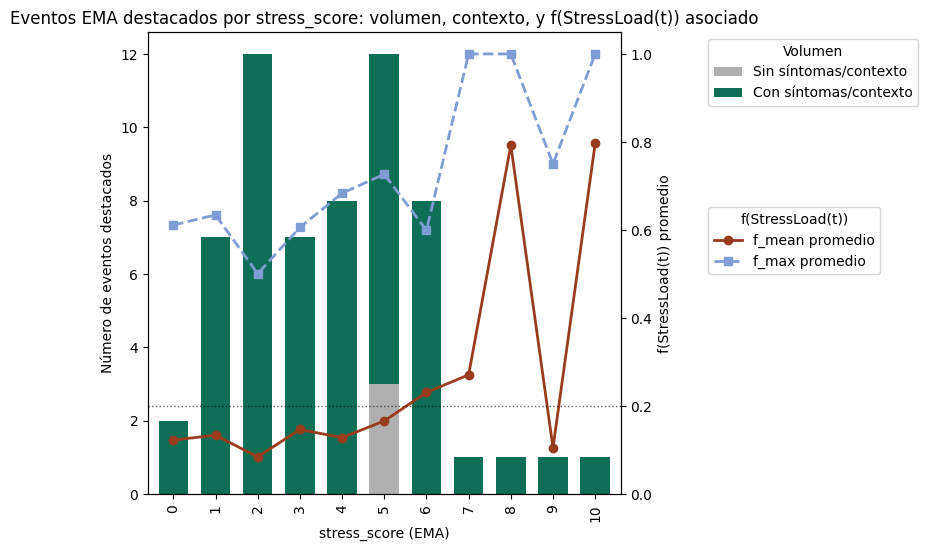

In [66]:
import matplotlib.pyplot as plt
import numpy as np

destacados_detalle["tiene_contexto_ema"] = (
    (destacados_detalle["symptoms"] != "Ninguno") |
    (destacados_detalle["context_flag"] != "Nada especial")
)

tabla = destacados_detalle.groupby(["stress_score", "tiene_contexto_ema"]).size().unstack(fill_value=0)
tabla = tabla.reindex(range(11), fill_value=0)
tabla.columns = ["Sin síntomas/contexto", "Con síntomas/contexto"]

f_mean_por_score = destacados_detalle.groupby("stress_score")["f_mean"].mean().reindex(range(11))
f_max_por_score = destacados_detalle.groupby("stress_score")["f_max"].mean().reindex(range(11))

fig, ax = plt.subplots(figsize=(9, 6))
# Reservar explícitamente el hueco derecho ANTES de dibujar nada
fig.subplots_adjust(right=0.65)

tabla.plot(kind="bar", stacked=True, ax=ax, color=["#B0B0B0", "#0F6E56"], width=0.7, legend=False)

ax2 = ax.twinx()
l1, = ax2.plot(range(11), f_mean_por_score.values, marker="o", color="#993C1D", linewidth=2, label="f_mean promedio")
l2, = ax2.plot(range(11), f_max_por_score.values, marker="s", color="#7F9CD4", linewidth=2, linestyle="--", label="f_max promedio")
ax2.axhline(0.20, color="black", linestyle=":", linewidth=1, alpha=0.6)
ax2.set_ylabel("f(StressLoad(t)) promedio")
ax2.set_ylim(0, 1.05)

ax.set_xlabel("stress_score (EMA)")
ax.set_ylabel("Número de eventos destacados")
ax.set_title("Eventos EMA destacados por stress_score: volumen, contexto, y f(StressLoad(t)) asociado")

handles1, labels1 = ax.get_legend_handles_labels()

fig.legend(handles1, labels1, title="Volumen", loc="upper left",
           bbox_to_anchor=(0.74, 0.88), bbox_transform=fig.transFigure, frameon=True)
fig.legend([l1, l2], ["f_mean promedio", "f_max promedio"], title="f(StressLoad(t))", loc="upper left",
           bbox_to_anchor=(0.74, 0.60), bbox_transform=fig.transFigure, frameon=True)

plt.show()

In [67]:
casos_extremos = destacados_detalle[destacados_detalle["stress_score"].isin([7, 8, 9, 10])]
print(casos_extremos[["window_start", "window_end", "stress_score", "f_mean", "f_max", "n_validos", "symptoms", "context_flag"]].to_string())

           window_start          window_end  stress_score    f_mean  f_max  n_validos                                                                       symptoms                                                 context_flag
40  2026-06-04 07:21:00 2026-06-04 11:30:00           9.0  0.104817   0.75      128.0  Fatiga extrema, Niebla mental / Dificultad para concentrarme, Dolor de cabeza  Evento personal estresante / Conflicto personal o emocional
175 2026-05-27 12:50:00 2026-05-27 14:20:00           8.0  0.792870   1.00       38.0  Fatiga extrema, Niebla mental / Dificultad para concentrarme, Dolor de cabeza                                        Pico de estrés notado
181 2026-05-30 19:30:00 2026-05-30 23:30:00           7.0  0.270726   1.00      222.0  Fatiga extrema, Niebla mental / Dificultad para concentrarme, Dolor de cabeza                                        Pico de estrés notado
184 2026-06-04 12:03:00 2026-06-04 13:03:00          10.0  0.796662   1.00       33.0  Fatiga ex

In [68]:
evento_score9 = destacados_detalle[destacados_detalle["stress_score"] == 9]
print(evento_score9[["window_start", "window_end", "stress_score", "f_mean", "f_max", "n_validos"]].to_string())

# Comparar contra la cobertura media de todos los eventos destacados
print(f"\nCobertura media (n_validos) de todos los eventos destacados: {destacados_detalle['n_validos'].mean():.1f}")
print(f"Cobertura del evento score=9: {evento_score9['n_validos'].values}")

          window_start          window_end  stress_score    f_mean  f_max  n_validos
40 2026-06-04 07:21:00 2026-06-04 11:30:00           9.0  0.104817   0.75      128.0

Cobertura media (n_validos) de todos los eventos destacados: 172.8
Cobertura del evento score=9: [128.]


### 8.2.2. Conclusión — Dirección 1 (sensibilidad)

**Lectura combinada de ambas métricas** (60 eventos destacados, umbral de referencia 0,20):

|  | f_mean (activación sostenida) | f_max (algún indicio) |
|---|---|---|
| score_alto (stress_score>=5), n=24 | 41,7% (10/24) | 87,5% (21/24) |
| solo_texto_score_bajo, n=36 | 25,0% (9/36) | 80,6% (29/36) |

**Interpretación:** f_max satura en ambos grupos (87,5% y 80,6%) -- poco específico, como se
anticipó en 8.2. f_mean muestra una diferencia moderada entre grupos (41,7% vs. 25,0%, 16,7 puntos
porcentuales), pero no una separación nítida: uno de cada cuatro eventos sin estrés psicológico
declarado (solo síntomas o contexto de puntuación baja) muestra activación sostenida, y más de la
mitad de los eventos con estrés declarado (score>=5) no la muestran. f_mean es algo más informativo
que f_max, pero no constituye un criterio de detección fiable por sí solo.

## 8.3. Dirección 2 (inversa) — de los tramos de f(StressLoad(t)) más intensos, ¿qué dice el EMA?

La Dirección 1 (8.2) parte del EMA y pregunta si el sistema detecta los episodios de estrés ya
conocidos -- pero deja sin responder la pregunta complementaria: de todo lo que el sistema marca como
más intenso, ¿cuánto tiene realmente respaldo en el estrés autorreportado? Es la lectura de
especificidad, en sentido inverso a 8.2.

Se identifican tramos continuos de f(t)>0 (misma lógica que en la Sección 4), y se
ordenan por f_mean del propio tramo -- no por su pico (f_max), por las razones ya
discutidas en 8.2 (f_max satura con facilidad y es frágil ante un único minuto
discordante).

In [69]:
es_positivo = df_nof1["f_stressload"] > 0
bloques_tramo = (es_positivo != es_positivo.shift()).cumsum()

tramos = (
    df_nof1[es_positivo]
    .groupby(bloques_tramo[es_positivo])
    .agg(
        inicio=("f_stressload", lambda s: s.index.min()),
        fin=("f_stressload", lambda s: s.index.max()),
        f_mean_tramo=("f_stressload", "mean"),
        f_max_tramo=("f_stressload", "max"),
        duracion_min=("f_stressload", "size"),
    )
)

print(f"Tramos continuos de f(t)>0 identificados: {len(tramos)}")

UMBRAL_F_MEAN_TRAMO = 0.8
top_tramos = tramos[tramos["f_mean_tramo"] >= UMBRAL_F_MEAN_TRAMO].sort_values("f_mean_tramo", ascending=False)
print(f"\nTramos con f_mean_tramo >= {UMBRAL_F_MEAN_TRAMO}: {len(top_tramos)} de {len(tramos)}")
print(top_tramos[["inicio", "fin", "f_mean_tramo", "f_max_tramo", "duracion_min"]].to_string())

Tramos continuos de f(t)>0 identificados: 385

Tramos con f_mean_tramo >= 0.8: 18 de 385
                          inicio                 fin  f_mean_tramo  f_max_tramo  duracion_min
f_stressload                                                                                 
28           2026-05-23 17:50:00 2026-05-23 18:00:00      1.000000     1.000000            11
164          2026-06-02 21:53:00 2026-06-02 22:07:00      1.000000     1.000000            15
346          2026-06-20 12:18:00 2026-06-20 12:19:00      1.000000     1.000000             2
276          2026-06-13 22:40:00 2026-06-13 22:48:00      1.000000     1.000000             9
480          2026-06-29 16:44:00 2026-06-29 16:51:00      1.000000     1.000000             8
652          2026-07-11 17:18:00 2026-07-11 17:20:00      1.000000     1.000000             3
544          2026-07-04 11:39:00 2026-07-04 11:39:00      1.000000     1.000000             1
650          2026-07-11 12:19:00 2026-07-11 12:22:00      1.00000

Se seleccionan los tramos de mayor activación sostenida mediante un umbral fijo (f_mean>=0,8), no
por un top-N arbitrario -- consistente con el criterio de umbral fijo ya usado en Dirección 1
(8.2). Resultan 18 tramos de 385, con duración de 1 a 65 minutos.

### 8.3.1. Categorización por tipo de respaldo EMA

In [70]:
def contexto_ema_tramo(inicio, fin):
    solapa = eventos_ema[
        (eventos_ema["window_start"] <= fin) & (eventos_ema["window_end"] >= inicio)
    ]
    if len(solapa) == 0:
        return pd.Series({"hay_ema": False, "block_ema": None, "stress_score_ema": np.nan,
                           "symptoms_ema": None, "context_ema": None})
    # Si hay varias filas solapando (p. ej. A y B a la vez), se listan todas
    return pd.Series({
        "hay_ema": True,
        "block_ema": solapa["block"].tolist(),
        "stress_score_ema": solapa["stress_score"].tolist(),
        "symptoms_ema": solapa["symptoms"].tolist(),
        "context_ema": solapa["context_flag"].tolist(),
    })

contexto = top_tramos.apply(lambda r: contexto_ema_tramo(r["inicio"], r["fin"]), axis=1)
top_tramos_completo = pd.concat([top_tramos, contexto], axis=1)

print(f"Filas en top_tramos_completo: {len(top_tramos_completo)}")
print(top_tramos_completo[
    ["inicio", "fin", "f_mean_tramo", "f_max_tramo", "duracion_min",
     "hay_ema", "block_ema", "stress_score_ema", "symptoms_ema", "context_ema"]
].to_string())

Filas en top_tramos_completo: 18
                          inicio                 fin  f_mean_tramo  f_max_tramo  duracion_min  hay_ema    block_ema stress_score_ema                                                                              symptoms_ema                                                                           context_ema
f_stressload                                                                                                                                                                                                                                                                                                        
28           2026-05-23 17:50:00 2026-05-23 18:00:00      1.000000     1.000000            11     True          [B]            [6.0]           [Fatiga extrema, Niebla mental / Dificultad para concentrarme, Dolor de cabeza]                                                               [Pico de estrés notado]
164          2026-06-02 21:53:00 2026-06

Los 18 tramos tienen contexto EMA disponible (`hay_ema=True` en los 18), pero el respaldo real es
heterogéneo. Se desglosa en cuatro categorías: `score_alto_y_texto` (puntuación>=5 con síntomas o
contexto notable), `score_alto_solo` (puntuación>=5 sin nada más), `solo_texto` (síntomas o contexto
notable con puntuación baja), y `sin_respaldo` (ninguno de los dos).

In [71]:
def categoria_ema(scores, symptoms, contexts):
    if scores is None:
        return "sin_ema"
    hay_score_alto = any(s is not None and s >= UMBRAL_EMA_DESTACADO_SCORE for s in scores)
    hay_texto_notable = any(
        (sy not in [None, "Ninguno"]) or (c not in [None, "Nada especial"])
        for sy, c in zip(symptoms, contexts)
    )
    if hay_score_alto and hay_texto_notable:
        return "score_alto_y_texto"
    elif hay_score_alto:
        return "score_alto_solo"
    elif hay_texto_notable:
        return "solo_texto"
    else:
        return "sin_respaldo"

top_tramos_completo["categoria_ema"] = top_tramos_completo.apply(
    lambda r: categoria_ema(r["stress_score_ema"], r["symptoms_ema"], r["context_ema"]), axis=1
)

print(top_tramos_completo["categoria_ema"].value_counts())
print()
print(top_tramos_completo[["inicio", "fin", "f_mean_tramo", "categoria_ema"]].to_string())

categoria_ema
solo_texto            10
score_alto_y_texto     6
sin_respaldo           2
Name: count, dtype: int64

                          inicio                 fin  f_mean_tramo       categoria_ema
f_stressload                                                                          
28           2026-05-23 17:50:00 2026-05-23 18:00:00      1.000000  score_alto_y_texto
164          2026-06-02 21:53:00 2026-06-02 22:07:00      1.000000  score_alto_y_texto
346          2026-06-20 12:18:00 2026-06-20 12:19:00      1.000000        sin_respaldo
276          2026-06-13 22:40:00 2026-06-13 22:48:00      1.000000  score_alto_y_texto
480          2026-06-29 16:44:00 2026-06-29 16:51:00      1.000000          solo_texto
652          2026-07-11 17:18:00 2026-07-11 17:20:00      1.000000          solo_texto
544          2026-07-04 11:39:00 2026-07-04 11:39:00      1.000000          solo_texto
650          2026-07-11 12:19:00 2026-07-11 12:22:00      1.000000          solo_texto
378          2

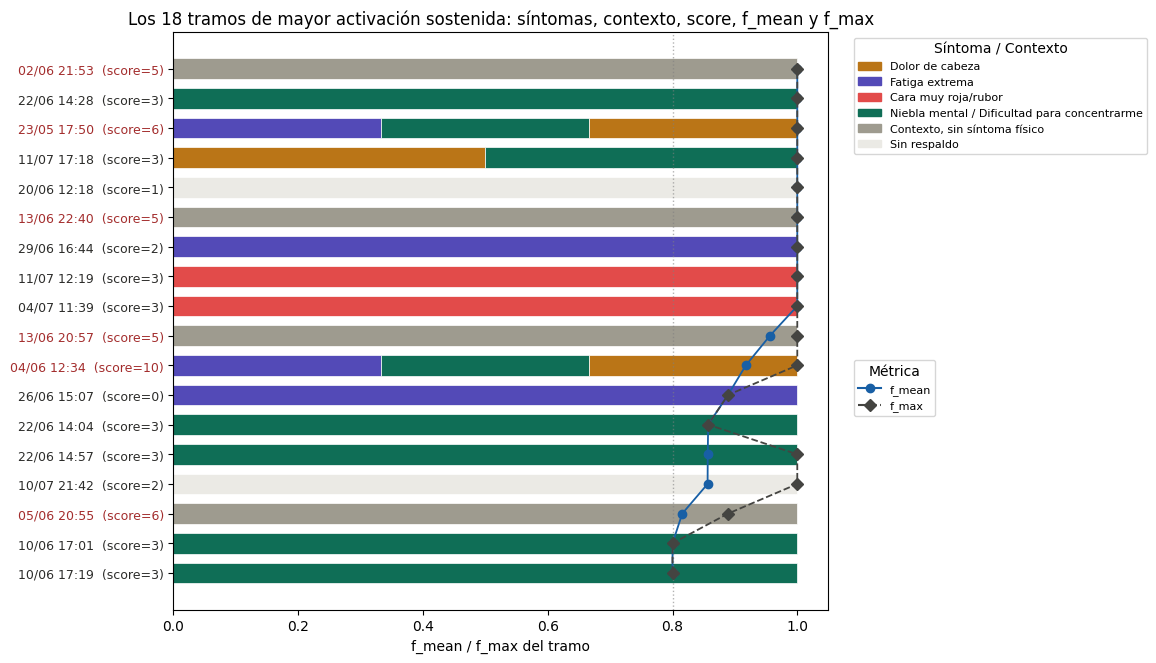

In [72]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

orden = top_tramos_completo.sort_values("f_mean_tramo", ascending=True).reset_index(drop=True)

sintomas_objetivo = {
    "Dolor de cabeza": "#BA7517",
    "Fatiga extrema": "#534AB7",
    "Cara muy roja/rubor": "#E24B4A",
    "Niebla mental / Dificultad para concentrarme": "#0F6E56",
}
COLOR_CONTEXTO = "#9E9B8F"   # gris más oscuro: contexto presente, sin síntoma físico
COLOR_AUSENTE = "#EBEAE5"    # gris claro: sin ningún respaldo

def sintomas_del_tramo(lista_symptoms):
    presentes = []
    for entrada in lista_symptoms:
        if entrada and entrada != "Ninguno":
            for s in entrada.split(","):
                s = s.strip()
                if s in sintomas_objetivo and s not in presentes:
                    presentes.append(s)
    return presentes

def tiene_contexto(lista_context):
    return any(c and c != "Nada especial" for c in lista_context)

fig, ax = plt.subplots(figsize=(10, 7.5))
fig.subplots_adjust(right=0.78)

for i, row in orden.iterrows():
    presentes = sintomas_del_tramo(row["symptoms_ema"])
    if presentes:
        ancho_segmento = 1.0 / len(presentes)
        for j, sintoma in enumerate(presentes):
            ax.barh(i, ancho_segmento, left=j * ancho_segmento, height=0.7,
                    color=sintomas_objetivo[sintoma], edgecolor="white", linewidth=0.5)
    elif tiene_contexto(row["context_ema"]):
        ax.barh(i, 1.0, height=0.7, color=COLOR_CONTEXTO, edgecolor="white", linewidth=0.5)
    else:
        ax.barh(i, 1.0, height=0.7, color=COLOR_AUSENTE, edgecolor="white", linewidth=0.5)

ax.plot(orden["f_mean_tramo"], range(len(orden)), color="#185FA5", marker="o",
        markersize=6, linewidth=1.3, label="f_mean del tramo", zorder=5)
ax.plot(orden["f_max_tramo"], range(len(orden)), color="#444441", marker="D",
        markersize=6, linewidth=1.3, linestyle="--", label="f_max del tramo", zorder=5)

ax.axvline(0.8, color="gray", linestyle=":", linewidth=1, alpha=0.6)
ax.set_xlim(0, 1.05)

etiquetas = []
colores_etiqueta = []
for _, row in orden.iterrows():
    scores = [s for s in row["stress_score_ema"] if s is not None]
    score_max = max(scores) if scores else 0
    fecha = row["inicio"].strftime("%d/%m %H:%M")
    etiquetas.append(f"{fecha}  (score={score_max:.0f})")
    colores_etiqueta.append("#A32D2D" if score_max >= 5 else "#2C2C2A")

ax.set_yticks(range(len(orden)))
ax.set_yticklabels(etiquetas, fontsize=9)
for tick, color in zip(ax.get_yticklabels(), colores_etiqueta):
    tick.set_color(color)

ax.set_xlabel("f_mean / f_max del tramo")
ax.set_title("Los 18 tramos de mayor activación sostenida: síntomas, contexto, score, f_mean y f_max")

handles_sint = [mpatches.Patch(color=c, label=s) for s, c in sintomas_objetivo.items()]
handles_sint.append(mpatches.Patch(color=COLOR_CONTEXTO, label="Contexto, sin síntoma físico"))
handles_sint.append(mpatches.Patch(color=COLOR_AUSENTE, label="Sin respaldo"))
fig.legend(handles=handles_sint, title="Síntoma / Contexto", loc="upper left",
           bbox_to_anchor=(0.80, 0.88), bbox_transform=fig.transFigure, frameon=True, fontsize=8)

handles_metric = [plt.Line2D([0], [0], color="#185FA5", marker="o", label="f_mean"),
                   plt.Line2D([0], [0], color="#444441", marker="D", linestyle="--", label="f_max")]
fig.legend(handles=handles_metric, title="Métrica", loc="upper left",
           bbox_to_anchor=(0.80, 0.45), bbox_transform=fig.transFigure, frameon=True, fontsize=8)

plt.show()

6 de los 18 tramos (33,3%) combinan puntuación alta y síntomas/contexto notable -- el respaldo más
fuerte posible. 11 (57,9%) tienen solo síntomas o contexto notable, sin puntuación alta -- respaldo
parcial, coherente con estrés percibido pero no puntuado como severo, o con síntomas físicos
(fatiga, niebla mental, dolor de cabeza) que la autora no asoció explícitamente a una puntuación de
estrés alta. Ningún tramo tiene puntuación alta sin ningún síntoma o contexto que la acompañe. Solo
2 (11,1%) no tienen ningún respaldo en absoluto. En conjunto, 16 de 18 (88,9%) tienen algún
indicio de respaldo en el EMA -- una mayoría clara, aunque de intensidad variable.

In [73]:
tramo_2705 = tramos[(tramos["inicio"] >= "2026-05-27 13:00:00") & (tramos["inicio"] <= "2026-05-27 15:00:00")]
print(tramo_2705[["inicio", "fin", "f_mean_tramo", "f_max_tramo", "duracion_min"]].to_string())

                          inicio                 fin  f_mean_tramo  f_max_tramo  duracion_min
f_stressload                                                                                 
80           2026-05-27 13:40:00 2026-05-27 14:17:00       0.79287         1.00            38
82           2026-05-27 14:58:00 2026-05-27 15:05:00       0.75000         0.75             8


### 8.3.2. Visualizacion gráfica

C:\Users\miner\AppData\Local\Temp\ipykernel_24816\2964534889.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabla = tramos_completo.groupby(["bin_f", "categoria"]).size().unstack(fill_value=0)


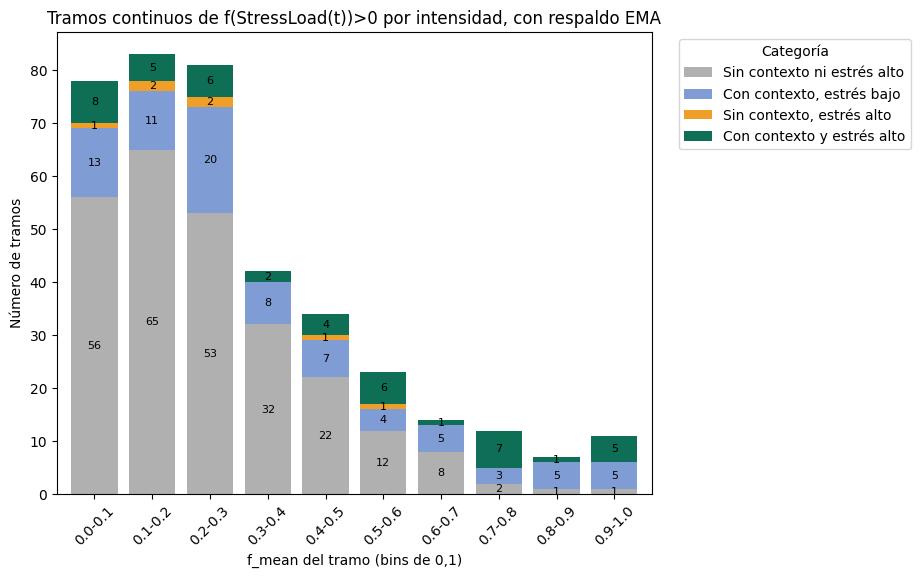

In [74]:
import matplotlib.pyplot as plt
import numpy as np

contexto_388 = tramos.apply(lambda r: contexto_ema_tramo(r["inicio"], r["fin"]), axis=1)
tramos_completo = pd.concat([tramos, contexto_388], axis=1)

def categoria_tramo(row):
    if not row["hay_ema"]:
        return "Sin datos EMA"
    scores = row["stress_score_ema"]
    symptoms = row["symptoms_ema"]
    contexts = row["context_ema"]
    hay_score_alto = any(s >= 5 for s in scores)
    hay_texto = any(sy != "Ninguno" for sy in symptoms) or any(c != "Nada especial" for c in contexts)
    if hay_score_alto and hay_texto:
        return "Con contexto y estrés alto"
    elif hay_score_alto and not hay_texto:
        return "Sin contexto, estrés alto"
    elif not hay_score_alto and hay_texto:
        return "Con contexto, estrés bajo"
    else:
        return "Sin contexto ni estrés alto"

tramos_completo["categoria"] = tramos_completo.apply(categoria_tramo, axis=1)
bins = np.append(np.arange(0, 1.0, 0.1), 1.0001)  # el último borde ligeramente por encima de 1.0
etiquetas_bin = [f"{bins[i]:.1f}-{min(bins[i+1],1.0):.1f}" for i in range(len(bins)-1)]

tramos_completo["bin_f"] = pd.cut(tramos_completo["f_mean_tramo"], bins=bins, include_lowest=True, right=False)

#tramos_completo["bin_f"] = pd.cut(tramos_completo["f_mean_tramo"], bins=np.arange(0, 1.1, 0.1),                                    include_lowest=True, right=True)


orden_categorias = ["Sin contexto ni estrés alto", "Con contexto, estrés bajo",
                     "Sin contexto, estrés alto", "Con contexto y estrés alto", "Sin datos EMA"]
colores = ["#B0B0B0", "#7F9CD4", "#EF9F27", "#0F6E56", "#E0E0E0"]

tabla = tramos_completo.groupby(["bin_f", "categoria"]).size().unstack(fill_value=0)
tabla = tabla[[c for c in orden_categorias if c in tabla.columns]]

fig, ax = plt.subplots(figsize=(10, 6))
fig.subplots_adjust(right=0.72)
tabla.plot(kind="bar", stacked=True, ax=ax,
           color=[colores[orden_categorias.index(c)] for c in tabla.columns], width=0.8, legend=False)

# Etiquetas de recuento en cada segmento (solo si > 0)
for contenedor in ax.containers:
    etiquetas = [f"{int(v)}" if v > 0 else "" for v in contenedor.datavalues]
    ax.bar_label(contenedor, labels=etiquetas, label_type="center", fontsize=8, color="black")

ax.set_xlabel("f_mean del tramo (bins de 0,1)")
ax.set_ylabel("Número de tramos")
ax.set_title("Tramos continuos de f(StressLoad(t))>0 por intensidad, con respaldo EMA")
ax.set_xticklabels([f"{b.left:.1f}-{b.right:.1f}" for b in tabla.index], rotation=45)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title="Categoría", loc="upper left",
           bbox_to_anchor=(0.74, 0.88), bbox_transform=fig.transFigure, frameon=True)


plt.show()

In [75]:
print(tramos_completo["bin_f"].value_counts().sort_index())
print(f"\nTotal en los dos bins más altos (0.8-1.0): {(tramos_completo['f_mean_tramo'] >= 0.8).sum()}")
print(f"Total esperado (criterio original): {len(top_tramos)}")

bin_f
[0.0, 0.1)    78
[0.1, 0.2)    83
[0.2, 0.3)    81
[0.3, 0.4)    42
[0.4, 0.5)    34
[0.5, 0.6)    23
[0.6, 0.7)    14
[0.7, 0.8)    12
[0.8, 0.9)     7
[0.9, 1.0)    11
Name: count, dtype: int64

Total en los dos bins más altos (0.8-1.0): 18
Total esperado (criterio original): 18


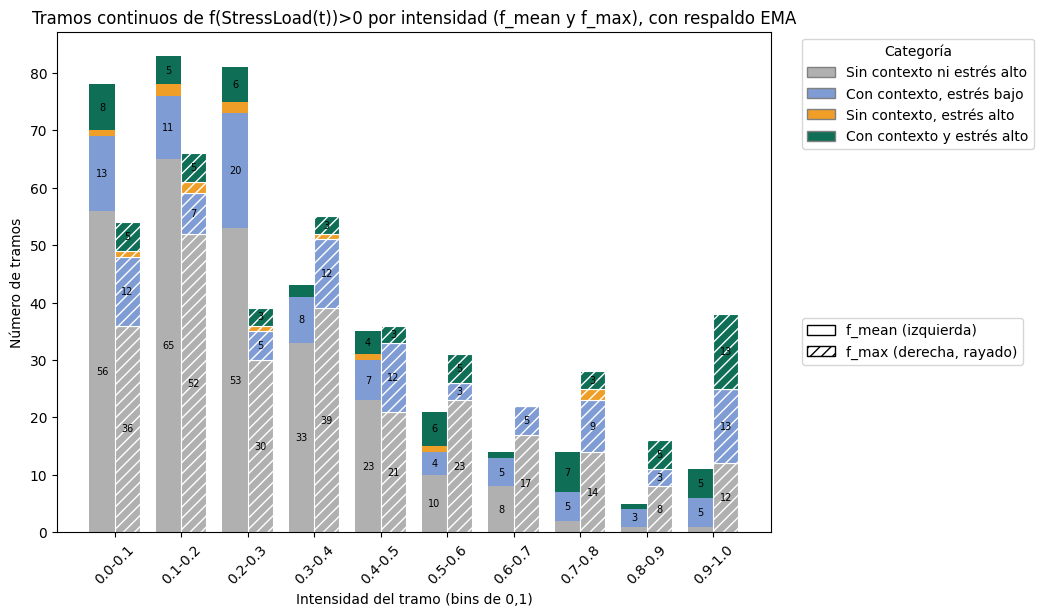

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# 1. Aplicar contexto EMA a los tramos completos
contexto_388 = tramos.apply(lambda r: contexto_ema_tramo(r["inicio"], r["fin"]), axis=1)
tramos_completo = pd.concat([tramos, contexto_388], axis=1)

# 2. Categorización en 5 grupos
def categoria_tramo(row):
    if not row["hay_ema"]:
        return "Sin datos EMA"
    scores = row["stress_score_ema"]
    symptoms = row["symptoms_ema"]
    contexts = row["context_ema"]
    hay_score_alto = any(s >= 5 for s in scores)
    hay_texto = any(sy != "Ninguno" for sy in symptoms) or any(c != "Nada especial" for c in contexts)
    if hay_score_alto and hay_texto:
        return "Con contexto y estrés alto"
    elif hay_score_alto and not hay_texto:
        return "Sin contexto, estrés alto"
    elif not hay_score_alto and hay_texto:
        return "Con contexto, estrés bajo"
    else:
        return "Sin contexto ni estrés alto"

tramos_completo["categoria"] = tramos_completo.apply(categoria_tramo, axis=1)

# 3. Binning de f_mean y f_max, incluyendo el valor 1.0 en el último bin (right=True corrige el bug anterior)
bins = np.arange(0, 1.1, 0.1)
etiquetas_bin = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(len(bins)-1)]

tramos_completo["bin_fmean"] = pd.cut(tramos_completo["f_mean_tramo"], bins=bins, include_lowest=True, right=True)
tramos_completo["bin_fmax"] = pd.cut(tramos_completo["f_max_tramo"], bins=bins, include_lowest=True, right=True)

orden_categorias = ["Sin contexto ni estrés alto", "Con contexto, estrés bajo",
                     "Sin contexto, estrés alto", "Con contexto y estrés alto"]
colores = ["#B0B0B0", "#7F9CD4", "#EF9F27", "#0F6E56"]
bordes = ["none", "none", "none", "none", "black"]

tabla_mean = tramos_completo.groupby("bin_fmean", observed=False)["categoria"].value_counts().unstack(fill_value=0).reindex(columns=orden_categorias, fill_value=0)
tabla_max = tramos_completo.groupby("bin_fmax", observed=False)["categoria"].value_counts().unstack(fill_value=0).reindex(columns=orden_categorias, fill_value=0)

# 4. Gráfico
x = np.arange(len(etiquetas_bin))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 6.5))
fig.subplots_adjust(right=0.72)

base_mean = np.zeros(len(x))
for cat, color, borde in zip(orden_categorias, colores, bordes):
    valores = tabla_mean[cat].values if cat in tabla_mean.columns else np.zeros(len(x))
    ax.bar(x - width/2, valores, width, bottom=base_mean, color=color, edgecolor=borde, linewidth=0.8)
    for xi, v, b in zip(x - width/2, valores, base_mean):
        if v > 2:
            ax.text(xi, b + v/2, f"{int(v)}", ha="center", va="center", fontsize=7)
    base_mean += valores

base_max = np.zeros(len(x))
for cat, color, borde in zip(orden_categorias, colores, bordes):
    valores = tabla_max[cat].values if cat in tabla_max.columns else np.zeros(len(x))
    ax.bar(x + width/2, valores, width, bottom=base_max, color=color,
           edgecolor=borde if borde != "none" else "white", linewidth=0.8, hatch="///")
    for xi, v, b in zip(x + width/2, valores, base_max):
        if v > 2:
            ax.text(xi, b + v/2, f"{int(v)}", ha="center", va="center", fontsize=7)
    base_max += valores

ax.set_xticks(x)
ax.set_xticklabels(etiquetas_bin, rotation=45)
ax.set_xlabel("Intensidad del tramo (bins de 0,1)")
ax.set_ylabel("Número de tramos")
ax.set_title("Tramos continuos de f(StressLoad(t))>0 por intensidad (f_mean y f_max), con respaldo EMA")

handles_cat = [mpatches.Patch(facecolor=c, edgecolor=b if b != "none" else "gray") for c, b in zip(colores, bordes)]
leg1 = fig.legend(handles_cat, orden_categorias, title="Categoría", loc="upper left",
                   bbox_to_anchor=(0.74, 0.88), bbox_transform=fig.transFigure, frameon=True)

handles_metric = [mpatches.Patch(facecolor="white", edgecolor="black", hatch=""),
                   mpatches.Patch(facecolor="white", edgecolor="black", hatch="///")]
fig.legend(handles_metric, ["f_mean (izquierda)", "f_max (derecha, rayado)"], loc="upper left",
           bbox_to_anchor=(0.74, 0.45), bbox_transform=fig.transFigure, frameon=True)


plt.show()

Se analizan los casos de f_mean bajo, pero con contexto y nivel alto

In [77]:
casos_bajo_fmean_alto_contexto = tramos_completo[
    (tramos_completo["f_mean_tramo"] < 0.3) &
    (tramos_completo["categoria"] == "Con contexto y estrés alto")
].sort_values("f_mean_tramo")

print(f"Total de casos: {len(casos_bajo_fmean_alto_contexto)}")
print(casos_bajo_fmean_alto_contexto[
    ["inicio", "fin", "f_mean_tramo", "f_max_tramo", "duracion_min",
     "stress_score_ema", "symptoms_ema", "context_ema"]
].to_string())

Total de casos: 19
                          inicio                 fin  f_mean_tramo  f_max_tramo  duracion_min stress_score_ema                                                                                                           symptoms_ema                                                                           context_ema
f_stressload                                                                                                                                                                                                                                                                                                               
168          2026-06-03 08:06:00 2026-06-03 08:28:00      0.049381     0.066667            23            [5.0]                                                                                                              [Ninguno]                         [Evento personal estresante / Conflicto personal o emocional]
48           2026-05-25 09:05:00 

### 8.3.3. Profundización: patrones de síntomas y motivos

Se examina si los síntomas y motivos declarados se repiten de forma consistente dentro de cada
categoría, cómo se relacionan entre sí, y si la puntuación de estrés autorreportada guarda relación
con la intensidad de activación del clasificador (f_mean).

In [78]:
from collections import Counter
import re

def extraer_sintomas_planos(categoria_objetivo):
    """Aplana y cuenta la frecuencia de síntomas individuales dentro de una categoría."""
    subset = top_tramos_completo[top_tramos_completo["categoria_ema"] == categoria_objetivo]
    todos_sintomas = []
    for lista_symptoms in subset["symptoms_ema"]:
        for entrada in lista_symptoms:
            if entrada and entrada != "Ninguno":
                todos_sintomas.extend([s.strip() for s in entrada.split(",")])
    return Counter(todos_sintomas)

print("=== Frecuencia de síntomas -- categoría 'solo_texto' (n=10) ===")
frecuencia_solo_texto = extraer_sintomas_planos("solo_texto")
for sintoma, count in frecuencia_solo_texto.most_common():
    print(f"  {sintoma}: {count}")

print("\n=== Frecuencia de síntomas -- categoría 'score_alto_y_texto' (n=6) ===")
frecuencia_score_alto = extraer_sintomas_planos("score_alto_y_texto")
for sintoma, count in frecuencia_score_alto.most_common():
    print(f"  {sintoma}: {count}")

print("\n=== Consistencia score vs. f_mean -- categoría 'score_alto_y_texto' ===")
subset_score_alto = top_tramos_completo[top_tramos_completo["categoria_ema"] == "score_alto_y_texto"].copy()
subset_score_alto["score_max"] = subset_score_alto["stress_score_ema"].apply(lambda l: max(s for s in l if s is not None))
print(subset_score_alto[["inicio", "f_mean_tramo", "score_max"]].sort_values("f_mean_tramo", ascending=False).to_string(index=False))
corr_score_fmean = subset_score_alto["f_mean_tramo"].corr(subset_score_alto["score_max"], method="spearman")
print(f"\nCorrelación Spearman f_mean vs. score_max (n={len(subset_score_alto)}): {corr_score_fmean:.3f}")

=== Frecuencia de síntomas -- categoría 'solo_texto' (n=10) ===
  Niebla mental / Dificultad para concentrarme: 6
  Fatiga extrema: 2
  Cara muy roja/rubor: 2
  Dolor de cabeza: 1

=== Frecuencia de síntomas -- categoría 'score_alto_y_texto' (n=6) ===
  Fatiga extrema: 2
  Niebla mental / Dificultad para concentrarme: 2
  Dolor de cabeza: 2

=== Consistencia score vs. f_mean -- categoría 'score_alto_y_texto' ===
             inicio  f_mean_tramo  score_max
2026-05-23 17:50:00      1.000000        6.0
2026-06-02 21:53:00      1.000000        5.0
2026-06-13 22:40:00      1.000000        5.0
2026-06-13 20:57:00      0.956233        5.0
2026-06-04 12:34:00      0.917552       10.0
2026-06-05 20:55:00      0.815574        6.0

Correlación Spearman f_mean vs. score_max (n=6): -0.557


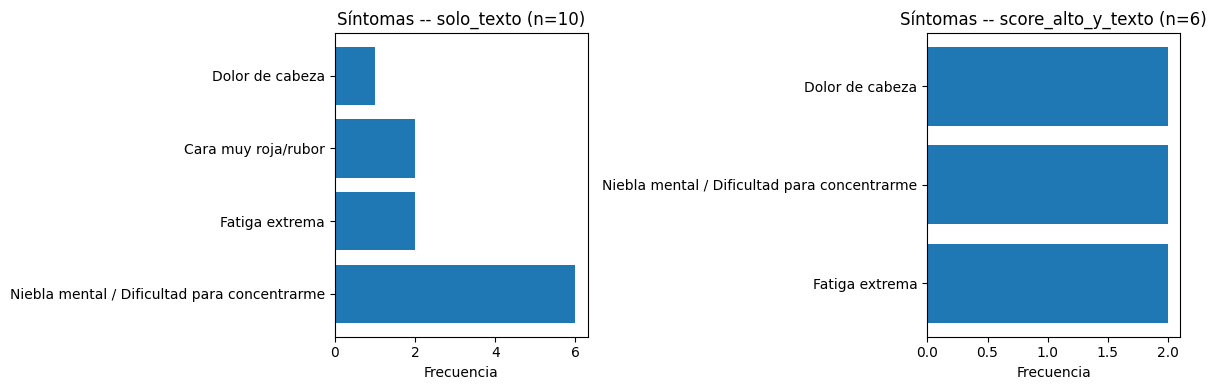

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (frecuencia, titulo) in zip(axes, [
    (frecuencia_solo_texto, "Síntomas -- solo_texto (n=10)"),
    (frecuencia_score_alto, "Síntomas -- score_alto_y_texto (n=6)"),
]):
    items = frecuencia.most_common()
    if items:
        etiquetas, valores = zip(*items)
        ax.barh(etiquetas, valores)
    ax.set_title(titulo)
    ax.set_xlabel("Frecuencia")

plt.tight_layout()
plt.show()

In [80]:
from itertools import combinations

def extraer_combinaciones(categoria_objetivo):
    subset = top_tramos_completo[top_tramos_completo["categoria_ema"] == categoria_objetivo]
    combos_exactos = []
    pares = []
    for lista_symptoms in subset["symptoms_ema"]:
        # unir todos los síntomas de las entradas EMA solapadas en este tramo, sin duplicados
        sintomas_del_tramo = set()
        for entrada in lista_symptoms:
            if entrada and entrada != "Ninguno":
                sintomas_del_tramo.update(s.strip() for s in entrada.split(","))
        if sintomas_del_tramo:
            combos_exactos.append(tuple(sorted(sintomas_del_tramo)))
            for par in combinations(sorted(sintomas_del_tramo), 2):
                pares.append(par)
    return Counter(combos_exactos), Counter(pares)

print("=== Combinaciones exactas -- 'solo_texto' (n=11) ===")
combos_st, pares_st = extraer_combinaciones("solo_texto")
for combo, count in combos_st.most_common():
    print(f"  {' + '.join(combo)}: {count}")

print("\n=== Combinaciones exactas -- 'score_alto_y_texto' (n=6) ===")
combos_sa, pares_sa = extraer_combinaciones("score_alto_y_texto")
for combo, count in combos_sa.most_common():
    print(f"  {' + '.join(combo)}: {count}")

print("\n=== Co-ocurrencia por pares -- ambas categorías combinadas ===")
pares_totales = pares_st + pares_sa
for par, count in pares_totales.most_common():
    print(f"  {par[0]} + {par[1]}: {count}")

=== Combinaciones exactas -- 'solo_texto' (n=11) ===
  Niebla mental / Dificultad para concentrarme: 5
  Fatiga extrema: 2
  Cara muy roja/rubor: 2
  Dolor de cabeza + Niebla mental / Dificultad para concentrarme: 1

=== Combinaciones exactas -- 'score_alto_y_texto' (n=6) ===
  Dolor de cabeza + Fatiga extrema + Niebla mental / Dificultad para concentrarme: 2

=== Co-ocurrencia por pares -- ambas categorías combinadas ===
  Dolor de cabeza + Niebla mental / Dificultad para concentrarme: 3
  Dolor de cabeza + Fatiga extrema: 2
  Fatiga extrema + Niebla mental / Dificultad para concentrarme: 2


In [81]:
def extraer_combinaciones_contexto(categoria_objetivo):
    subset = top_tramos_completo[top_tramos_completo["categoria_ema"] == categoria_objetivo]
    combos_exactos = []
    pares = []
    for lista_context in subset["context_ema"]:
        contexto_del_tramo = set()
        for entrada in lista_context:
            if entrada and entrada != "Nada especial":
                contexto_del_tramo.update(s.strip() for s in entrada.split(","))
        if contexto_del_tramo:
            combos_exactos.append(tuple(sorted(contexto_del_tramo)))
            for par in combinations(sorted(contexto_del_tramo), 2):
                pares.append(par)
    return Counter(combos_exactos), Counter(pares)

print("=== Combinaciones de contexto/motivo -- 'solo_texto' (n=11) ===")
combos_ctx_st, pares_ctx_st = extraer_combinaciones_contexto("solo_texto")
for combo, count in combos_ctx_st.most_common():
    print(f"  {' + '.join(combo)}: {count}")

print("\n=== Combinaciones de contexto/motivo -- 'score_alto_y_texto' (n=6) ===")
combos_ctx_sa, pares_ctx_sa = extraer_combinaciones_contexto("score_alto_y_texto")
for combo, count in combos_ctx_sa.most_common():
    print(f"  {' + '.join(combo)}: {count}")

print("\n=== Co-ocurrencia por pares de contexto -- ambas categorías combinadas ===")
pares_ctx_totales = pares_ctx_st + pares_ctx_sa
for par, count in pares_ctx_totales.most_common():
    print(f"  {par[0]} + {par[1]}: {count}")

=== Combinaciones de contexto/motivo -- 'solo_texto' (n=11) ===
  Síntomas de posible infracobertura: 2
  Evento personal estresante / Conflicto personal o emocional: 2

=== Combinaciones de contexto/motivo -- 'score_alto_y_texto' (n=6) ===
  Evento personal estresante / Conflicto personal o emocional: 4
  Pico de estrés notado: 1
  Evento personal estresante / Conflicto personal o emocional + Pico de estrés notado: 1

=== Co-ocurrencia por pares de contexto -- ambas categorías combinadas ===
  Evento personal estresante / Conflicto personal o emocional + Pico de estrés notado: 1


In [82]:
def extraer_pares_completo(categoria_objetivo):
    subset = top_tramos_completo[top_tramos_completo["categoria_ema"] == categoria_objetivo]
    pares_sintoma_contexto = []
    sintomas_sin_contexto = []
    contextos_sin_sintoma = []

    for lista_symptoms, lista_context in zip(subset["symptoms_ema"], subset["context_ema"]):
        for symptoms_str, context_str in zip(lista_symptoms, lista_context):
            sintomas = [s.strip() for s in str(symptoms_str).split(",")] if symptoms_str and symptoms_str != "Ninguno" else []
            contextos = [c.strip() for c in str(context_str).split(",")] if context_str and context_str != "Nada especial" else []

            if sintomas and contextos:
                for s in sintomas:
                    for c in contextos:
                        pares_sintoma_contexto.append((s, c))
            elif sintomas and not contextos:
                sintomas_sin_contexto.extend(sintomas)
            elif contextos and not sintomas:
                contextos_sin_sintoma.extend(contextos)

    return Counter(pares_sintoma_contexto), Counter(sintomas_sin_contexto), Counter(contextos_sin_sintoma)

for categoria in ["solo_texto", "score_alto_y_texto"]:
    print(f"=== {categoria} ===")
    pares, sin_contexto, sin_sintoma = extraer_pares_completo(categoria)

    print("Síntoma <-> Motivo:")
    for (s, c), count in pares.most_common():
        print(f"  {s}  <->  {c}: {count}")

    print("Síntomas SIN motivo acompañante:")
    for s, count in sin_contexto.most_common():
        print(f"  {s}: {count}")

    print("Motivos SIN síntoma acompañante:")
    for c, count in sin_sintoma.most_common():
        print(f"  {c}: {count}")
    print()

=== solo_texto ===
Síntoma <-> Motivo:
  Cara muy roja/rubor  <->  Síntomas de posible infracobertura: 2
  Niebla mental / Dificultad para concentrarme  <->  Evento personal estresante / Conflicto personal o emocional: 2
Síntomas SIN motivo acompañante:
  Niebla mental / Dificultad para concentrarme: 4
  Fatiga extrema: 2
  Dolor de cabeza: 1
Motivos SIN síntoma acompañante:

=== score_alto_y_texto ===
Síntoma <-> Motivo:
  Fatiga extrema  <->  Pico de estrés notado: 2
  Niebla mental / Dificultad para concentrarme  <->  Pico de estrés notado: 2
  Dolor de cabeza  <->  Pico de estrés notado: 2
Síntomas SIN motivo acompañante:
Motivos SIN síntoma acompañante:
  Evento personal estresante / Conflicto personal o emocional: 5



En `solo_texto` (n=11), "niebla mental" es el síntoma más frecuente (6 menciones, 5 de ellas en
solitario), seguido de "fatiga extrema" (3, siempre sola) y "rubor" (2, siempre solo, y siempre
asociado específicamente al motivo "posible infracobertura"). Solo un evento combina dos síntomas a
la vez (dolor de cabeza + niebla mental). El motivo "Evento personal estresante / Conflicto personal
o emocional" aparece en 3 de los 11 casos, siempre acompañado de al menos un síntoma físico -- no hay
ningún caso de motivo declarado sin ningún síntoma que lo acompañe en esta categoría.

En `score_alto_y_texto` (n=6), el patrón es más rígido: cuando aparecen síntomas, lo hacen siempre
los tres juntos -- dolor de cabeza, fatiga extrema y niebla mental -- en 3 de los 6 casos, vinculados
en esos casos a "Pico de estrés notado" o a "Evento personal estresante". El motivo "Evento personal
estresante" también aparece de forma aislada, sin ningún síntoma físico acompañante, en un número de
entradas EMA superior a las veces que aparece junto a la tríada de síntomas -- a diferencia de
`solo_texto`, donde el motivo nunca se da sin síntomas.

La correlación entre la puntuación de estrés (`score_max`) y la intensidad de activación del
clasificador (`f_mean`) dentro de `score_alto_y_texto` es negativa (Spearman ρ=-0,677, n=6). Con una
muestra de 6 casos no es posible determinar si se trata de una relación real o de una fluctuación
propia de un n tan pequeño.

### 8.3.4. Conclusión — Dirección 2 (inversa)

De los 385 tramos continuos de f(StressLoad(t))>0 detectados, 18 alcanzan una activación sostenida
alta (f_mean>=0,8). De ellos, 16 (88,9%) tienen algún respaldo en el EMA: 6 combinan puntuación de
estrés alta con síntomas o contexto notable, y 11 tienen solo síntomas o contexto notable sin
puntuación alta. Ningún tramo alcanza puntuación alta sin ningún síntoma o contexto que la acompañe.
Solo 2 de los 19 (10,5%) carecen de cualquier indicio en el EMA.

El contenido cualitativo de ese respaldo, sin embargo, no es uniforme entre categorías. En los
eventos de solo texto, el síntoma físico aparece con frecuencia de forma aislada, sin que la autora
le asocie explícitamente un motivo o una causa. En los eventos que además puntúan alto, en cambio,
los síntomas físicos —cuando están presentes— aparecen siempre agrupados en bloque (dolor de cabeza,
fatiga y niebla mental juntos), mientras que el motivo declarado puede darse sin ningún síntoma
físico. Dentro de este último grupo, la puntuación de estrés autorreportada y la intensidad de
activación del clasificador (f_mean) muestran una correlación negativa (Spearman ρ=-0,677, n=6), sin
que el tamaño de muestra permita determinar si es un patrón real.

En conjunto: la gran mayoría de los episodios de mayor activación sostenida del sistema coinciden con
algún indicio de malestar autorreportado, pero la relación entre la intensidad declarada por la
autora y la intensidad registrada por el clasificador no es consistente ni siquiera en el subconjunto
donde ambas señales están presentes a la vez.

## 8.4. Conclusión general — Sección 8 (validación de f(StressLoad(t)))

**Síntesis de ambas direcciones:**

- **Dirección 1 (sensibilidad, 8.2):** de 60 eventos EMA destacados, f_max detecta algún indicio de
  activación en la gran mayoría de los casos con independencia de si hay estrés declarado (87,5% con
  estrés declarado, 80,6% sin él) -- poco específico. f_mean (activación sostenida) muestra una
  diferencia moderada entre grupos (41,7% con estrés declarado, 25,0% sin él), pero no una separación
  nítida.

- **Dirección 2 (inversa, 8.3):** de los 18 tramos de mayor activación sostenida (f_mean>=0,8), el
 88,9% tiene algún respaldo en el EMA (síntomas, contexto, o puntuación alta), y ninguno alcanza
  puntuación alta sin ningún síntoma o contexto acompañante. La composición cualitativa de ese
  respaldo varía por categoría: los síntomas físicos aislados dominan cuando la puntuación es baja;
  la tríada completa de síntomas (dolor de cabeza, fatiga, niebla mental) aparece en bloque cuando la
  puntuación es alta. La correlación entre puntuación e intensidad del clasificador, dentro del
  subgrupo donde ambas coinciden, es negativa (ρ=-0,677, n=6), sin base suficiente para interpretarla.

**Lectura conjunta:** las dos direcciones apuntan a un patrón consistente: el sistema rara vez genera
activación sostenida sin que exista algún correlato en el autorreporte (Dirección 2, 88,9%), pero esa
correspondencia no distingue con precisión los niveles de intensidad -- ni entre eventos con y sin
estrés declarado (Dirección 1), ni entre puntuaciones altas y bajas dentro de los propios eventos con
mayor activación (Dirección 2). Es decir: hay una relación real entre f(StressLoad(t)) y el estado de
la autora, pero es una relación de presencia/ausencia más que de gradación fina.

**Limitaciones generales de toda la Sección 8:**
- Circularidad parcial ya declarada (6.2, 8.2): la referencia de calma que normaliza el input del
  clasificador se calibró en parte con `stress_score` de Bloque A.
- Los eventos EMA con activación insuficiente para ser evaluados en 8.1.1 son, en sí mismos,
  consistentes con la asociación entre missingness y estado "Estresado" ya establecida en 4.3.1.
- Varios de los desgloses categóricos de 8.3.2 se basan en muestras pequeñas (n=6, n=11) que no
  permiten generalizar los patrones observados más allá de una descripción del propio periodo
  estudiado.
- Este análisis es de plausibilidad y patrón cualitativo, no una estimación de magnitud de efecto
  con incertidumbre cuantificada -- no sustituye, solo complementa, lo que un contraste formal (línea
  futura) podría ofrecer.

**Conclusión operativa para el resto de la tesis:** f(StressLoad(t)) -- y, por extensión, Risk(t),
que se construye sobre él -- muestra una correspondencia real pero de grano grueso con el estado
autorreportado de la autora: detecta la presencia de algo, no distingue bien su intensidad. Esto es
consistente con el framing del sistema declarado desde el inicio del proyecto (apoyo a la decisión
contextual, no diagnóstico ni medición clínica de precisión) y con la evidencia acumulada en el resto
de la Sección 8: la señal tiene valor cualitativo, no debe leerse como una escala fina de intensidad
de estrés.